**Table of contents**<a id='toc0_'></a>    
  - [Import data](#toc1_1_)    
  - [Data Preparation of reduced df](#toc1_2_)    
    - [Create dependent variables](#toc1_2_1_)    
    - [Feature Engineering](#toc1_2_2_)    
      - [Calls in the last 7 days](#toc1_2_2_1_)    
      - [Days since last call (Client)](#toc1_2_2_2_)    
      - [Tipification level 2](#toc1_2_2_3_)    
      - [Days since last call (GC - Group Key)](#toc1_2_2_4_)    
      - [Weekday or Weekend](#toc1_2_2_5_)    
      - [Time of day](#toc1_2_2_6_)    
      - [Topic Classification Entry at FT - PREVIOUS CALL](#toc1_2_2_7_)    
    - [Create Baseline Prediction Columns (Rule-Based Average Targets per Cat)](#toc1_2_3_)    
    - [Select relevant columns](#toc1_2_4_)    
    - [Encode Categorical Variables](#toc1_2_5_)    
    - [Train / Test Split](#toc1_2_6_)    
    - [Resampling](#toc1_2_7_)    
    - [Normalize Numerical Variables](#toc1_2_8_)    
  - [Regression Models to predict TMC](#toc1_3_)    
    - [TMC: Rule-Based (Average)](#toc1_3_1_)    
      - [TMC: Linear Regression](#toc1_3_1_1_)    
    - [TMC: XGBoost Regressor](#toc1_3_2_)    
    - [TMC: Neural Network](#toc1_3_3_)    
    - [TMC Model Comparison](#toc1_3_4_)    
  - [Classification Models to predict FTR](#toc1_4_)    
    - [FTR: Rule-Based (Average)](#toc1_4_1_)    
    - [FTR: Logistic Regression](#toc1_4_2_)    
    - [FTR: XGBoost Classifier](#toc1_4_3_)    
    - [FTR: Neural Network](#toc1_4_4_)    
    - [FTR Model Comparison](#toc1_4_5_)    
  - [Classification Models to predict OT](#toc1_5_)    
    - [OT: Rule-Based (Average per Cat)](#toc1_5_1_)    
    - [OT: Logistic Regression](#toc1_5_2_)    
    - [OT: XGBoost Classifier](#toc1_5_3_)    
    - [OT: Neural Network](#toc1_5_4_)    
    - [OT Model Comparison](#toc1_5_5_)    
  - [Apply on sample calls and select suitable GC](#toc1_6_)    
    - [Create GCs Unique Table](#toc1_6_1_)    
    - [Define 10 Sample Calls](#toc1_6_2_)    
    - [SIMPLE (Linear and Logistic Regression)](#toc1_6_3_)    
    - [BOOSTED (XG Boost Regressor and Classifier)](#toc1_6_4_)    
    - [ADVANCED (Neural Networks)](#toc1_6_5_)    
    - [Output Comparison](#toc1_6_6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import getpass
import dask.dataframe as dd

In [2]:
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Avoid truncation of wide output
pd.set_option('display.max_colwidth', None)  # Avoid truncation of column content

In [ ]:
# This notebook serves as explanation of the modelling approach, hence the import and cleaning cells have been deleted. 
# For the full code, please refer to the notebook 01_cleaning_and_modelling.ipynb

## <a id='toc1_2_'></a>[Data Preparation of reduced df](#toc0_)

### <a id='toc1_2_1_'></a>[Create dependent variables](#toc0_)

In [6]:
# Filter out rows with call_LEG_DURATION_SEC_QTY above 10800
full_merged_df = full_merged_df[full_merged_df['call_LEG_DURATION_SEC_QTY'] <= 10800]

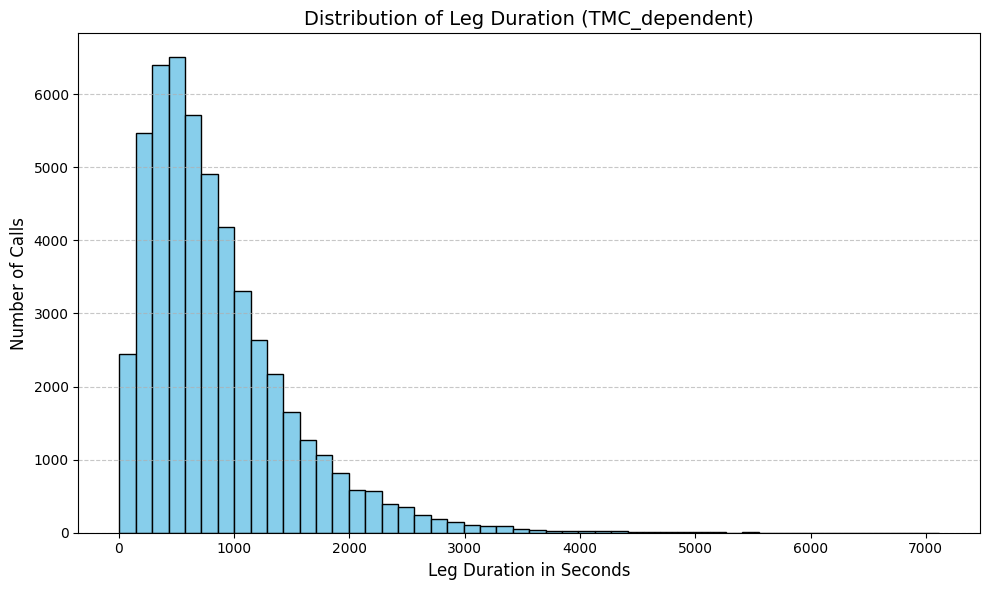

In [7]:
# Create TMC_dependent
full_merged_df['TMC_dependent'] = full_merged_df['call_LEG_DURATION_SEC_QTY']

# Plot the distribution
plt.figure(figsize=(10, 6))
plt.hist(full_merged_df['TMC_dependent'], bins=50, edgecolor='black', color='skyblue')
plt.title('Distribution of Leg Duration (TMC_dependent)', fontsize=14)
plt.xlabel('Leg Duration in Seconds', fontsize=12)
plt.ylabel('Number of Calls', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


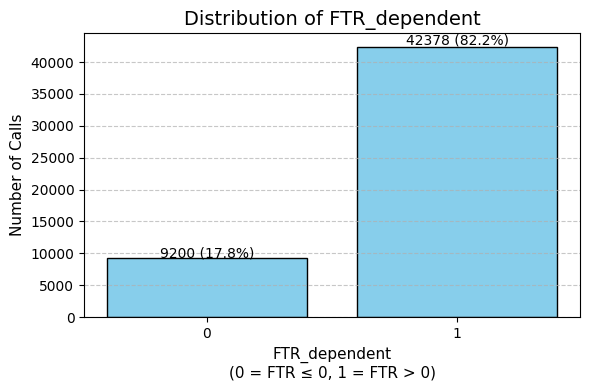

In [8]:
# Create FTR_dependent
full_merged_df['FTR_dependent'] = (full_merged_df['call_FTR_CALCULATED'] > 0).astype(int)

# Revert all other FTR colums as well
ftr_columns = [col for col in full_merged_df.columns if 'FTR' in col]
for col in ftr_columns:
    full_merged_df[col] = 1 - full_merged_df[col]

# Plot distribution
ftr_counts = full_merged_df['FTR_dependent'].value_counts().sort_index()
ftr_percent = ftr_counts / ftr_counts.sum() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(ftr_counts.index.astype(str), ftr_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of FTR_dependent', fontsize=14)
plt.xlabel('FTR_dependent\n(0 = FTR ≤ 0, 1 = FTR > 0)', fontsize=11)
plt.ylabel('Number of Calls', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add count and % labels
for i, (count, pct) in enumerate(zip(ftr_counts.values, ftr_percent)):
    plt.text(i, count + count*0.01, f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

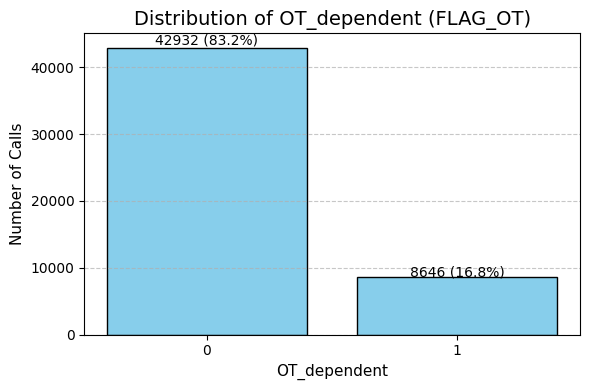

In [9]:
# Create OT_dependent
full_merged_df['OT_dependent'] = full_merged_df['call_FLAG_OT']

# Plot distribution
ot_counts = full_merged_df['OT_dependent'].value_counts().sort_index()
ot_percent = ot_counts / ot_counts.sum() * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(ot_counts.index.astype(str), ot_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribution of OT_dependent (FLAG_OT)', fontsize=14)
plt.xlabel('OT_dependent', fontsize=11)
plt.ylabel('Number of Calls', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Add count and % labels
for i, (count, pct) in enumerate(zip(ot_counts.values, ot_percent)):
    plt.text(i, count + count*0.01, f'{count} ({pct:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
print(full_merged_df[['call_FTR_CALCULATED', 'call_FLAG_OT']].describe())
print(full_merged_df['FTR_dependent'].value_counts(normalize=True))
print(full_merged_df['OT_dependent'].value_counts(normalize=True))


       call_FTR_CALCULATED  call_FLAG_OT
count         51578.000000  51578.000000
mean              0.840848      0.167630
std               0.353206      0.373541
min               0.000000      0.000000
25%               1.000000      0.000000
50%               1.000000      0.000000
75%               1.000000      0.000000
max               1.000000      1.000000
FTR_dependent
1    0.821629
0    0.178371
Name: proportion, dtype: float64
OT_dependent
0    0.83237
1    0.16763
Name: proportion, dtype: float64


### <a id='toc1_2_2_'></a>[Feature Engineering](#toc0_)

In [11]:
# Convert call_CALL_START_TIME_DAT	call_CALL_END_TIME_DAT	call_LEG_START_TIME_DAT	call_LEG_END_TIME_DAT to datetime
full_merged_df["call_CALL_START_TIME_DAT"] = pd.to_datetime(full_merged_df["call_CALL_START_TIME_DAT"])
full_merged_df["call_CALL_END_TIME_DAT"] = pd.to_datetime(full_merged_df["call_CALL_END_TIME_DAT"])
full_merged_df["call_LEG_START_TIME_DAT"] = pd.to_datetime(full_merged_df["call_LEG_START_TIME_DAT"])
full_merged_df["call_LEG_END_TIME_DAT"] = pd.to_datetime(full_merged_df["call_LEG_END_TIME_DAT"])


In [ ]:
# Feature Engineering
# 1. Calls in the last 7 days (0 for no, 1 for yes)
# 2. Days since last call (Client)
# 3. Tipicification level 2
# 4. Days since last call (GC)
# 5. Weekday or Weekend
# 6. Time of day (Morning, Afternoon, Evening, Night)


#### <a id='toc1_2_2_1_'></a>[Calls in the last 7 days](#toc0_)

In [ ]:
# 1. Calls in the last 7 days (Client)
# This requires knowing the previous call time for the same client.
# First, sort by client and then by call time to correctly identify previous calls.
full_merged_df = full_merged_df.sort_values(by=['call_PERSON_ID', 'call_CALL_START_TIME_DAT'])

# Get the previous call time for each client
full_merged_df['previous_call_time_client'] = full_merged_df.groupby('call_PERSON_ID')['call_CALL_START_TIME_DAT'].shift(1)

# Calculate days since the previous call for that client
full_merged_df['days_since_prev_call_for_client'] = (full_merged_df['call_CALL_START_TIME_DAT'] - full_merged_df['previous_call_time_client']).dt.days

# Feature: 1 if there was a call from this client in the last 7 days (relative to the current call), 0 otherwise
# For the first call of a client, 'days_since_prev_call_for_client' will be NaN.
full_merged_df['client_called_in_last_7_days'] = full_merged_df['days_since_prev_call_for_client'].apply(lambda x: 1 if pd.notna(x) and x <= 7 else 0)

#### <a id='toc1_2_2_2_'></a>[Days since last call (Client)](#toc0_)

In [ ]:
# 2. Days since last call (Client)
# This is essentially 'days_since_prev_call_for_client' calculated above.
# We might want to fill NaNs for clients with no prior calls (e.g., with -1 or a large number).
# For this example, let's keep it as is, or fill with a placeholder like -1.
full_merged_df['days_since_prev_call_for_client'] = full_merged_df['days_since_prev_call_for_client'].fillna(-1).astype(int)
full_merged_df['days_since_last_call_client'] = full_merged_df['days_since_prev_call_for_client'] # Or keep NaN if preferred


#### <a id='toc1_2_2_3_'></a>[Tipification level 2](#toc0_)

In [15]:
def enrich_with_lvl2_topic_features(df, person_col="PERSON_SK"):
    """
    Adds historical Level 2 topic features:
    - Lagged topic category
    - Cumulative topic counts
    - Proportions over client history
    - One-hot lag features
    - First-call flag
    """
    df = df.copy()

    # --- 1. 'TV' to 'TELEVISÃO' ---
    df["call_TOPIC_TIPIFICATION_LVL_2_DSC"] = df["call_TOPIC_TIPIFICATION_LVL_2_DSC"].replace("TV", "TELEVISÃO")

    # --- 2. Group Level 2 topics ---
    topics_to_keep_lvl2 = {
        "INTERNET FIXA", "TELEVISÃO", "BOX", "VOZ FIXA",
        "ADESÃO/ALTERAÇÃO", "SEM VOZ DE CLIENTE", "MAIS INFORMAÇÕES", "CARTÃO SIM/ESIM/TWIN"
    }
    df["TOPIC_LVL_2_GROUPED"] = df["call_TOPIC_TIPIFICATION_LVL_2_DSC"].apply(
        lambda x: x if x in topics_to_keep_lvl2 else "OUTROS"
    )

    # --- 3. Lagged topic (string-based), fill missing with 'NO_PREV_CALL' ---
    df["TOPIC_LVL_2_GROUPED_LAG1_STR"] = df.groupby(person_col)["TOPIC_LVL_2_GROUPED"].shift(1).fillna("NO_PREV_CALL")

    # --- 4. One-hot dummies for counting, drop dummy lag class ---
    lvl2_dummies = pd.get_dummies(df["TOPIC_LVL_2_GROUPED_LAG1_STR"], prefix="CNT_LVL2")
    lvl2_dummies = lvl2_dummies.drop(columns=[col for col in lvl2_dummies if "NO_PREV_CALL" in col], errors='ignore')

    # --- 5. Cumulative topic count ---
    lvl2_counts = lvl2_dummies.groupby(df[person_col]).cumsum()
    df = pd.concat([df, lvl2_counts], axis=1)

    # --- 6. Cumulative call number per client ---
    df["CUM_TOTAL_CALLS"] = df.groupby(person_col).cumcount()

    # --- 7. Proportional features ---
    for col in lvl2_counts.columns:
        df[col.replace("CNT_", "PROP_")] = lvl2_counts[col] / (df["CUM_TOTAL_CALLS"] + 1)

    # --- 8. One-hot encode lag string for model use (keep 'NO_PREV_CALL') ---
    lag1_l2_encoded = pd.get_dummies(df["TOPIC_LVL_2_GROUPED_LAG1_STR"], prefix="LAG1_LVL2", drop_first=False)
    df = pd.concat([df, lag1_l2_encoded.astype(int)], axis=1)

    # --- 9. First call flag ---
    df["IS_FIRST_CALL"] = (df["CUM_TOTAL_CALLS"] == 0).astype(int)

    return df

full_merged_df = enrich_with_lvl2_topic_features(full_merged_df)

In [ ]:
features_to_include = [
    "IS_FIRST_CALL"
]

# Add all CNT_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("CNT_LVL2_")]

# Add all PROP_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("PROP_LVL2_")]

# Add all LAG1_LVL2_* columns
features_to_include += [col for col in full_merged_df.columns if col.startswith("LAG1_LVL2_")]

print("Features to include:")
for feature in features_to_include:
    print(feature)

Features to include:
IS_FIRST_CALL
CNT_LVL2_ADESÃO/ALTERAÇÃO
CNT_LVL2_BOX
CNT_LVL2_CARTÃO SIM/ESIM/TWIN
CNT_LVL2_INTERNET FIXA
CNT_LVL2_MAIS INFORMAÇÕES
CNT_LVL2_OUTROS
CNT_LVL2_SEM VOZ DE CLIENTE
CNT_LVL2_TELEVISÃO
CNT_LVL2_VOZ FIXA
PROP_LVL2_ADESÃO/ALTERAÇÃO
PROP_LVL2_BOX
PROP_LVL2_CARTÃO SIM/ESIM/TWIN
PROP_LVL2_INTERNET FIXA
PROP_LVL2_MAIS INFORMAÇÕES
PROP_LVL2_OUTROS
PROP_LVL2_SEM VOZ DE CLIENTE
PROP_LVL2_TELEVISÃO
PROP_LVL2_VOZ FIXA
LAG1_LVL2_ADESÃO/ALTERAÇÃO
LAG1_LVL2_BOX
LAG1_LVL2_CARTÃO SIM/ESIM/TWIN
LAG1_LVL2_INTERNET FIXA
LAG1_LVL2_MAIS INFORMAÇÕES
LAG1_LVL2_NO_PREV_CALL
LAG1_LVL2_OUTROS
LAG1_LVL2_SEM VOZ DE CLIENTE
LAG1_LVL2_TELEVISÃO
LAG1_LVL2_VOZ FIXA


#### <a id='toc1_2_2_4_'></a>[Days since last call (GC - Group Key)](#toc0_)

In [ ]:
# 4. Days since last call (GC - Group Key)
# Similar to client, but grouping by 'RESOURCE_KEY'
full_merged_df = full_merged_df.sort_values(by=['RESOURCE_KEY', 'call_CALL_START_TIME_DAT']) # Ensure sort order for GC
full_merged_df['previous_call_time_gc'] = full_merged_df.groupby('RESOURCE_KEY')['call_CALL_START_TIME_DAT'].shift(1)
full_merged_df['days_since_last_call_gc'] = (full_merged_df['call_CALL_START_TIME_DAT'] - full_merged_df['previous_call_time_gc']).dt.days

# We might want to fill NaNs for clients with no prior calls (e.g., with -1 or a large number).
# For this example, let's keep it as is, or fill with a placeholder like -1.
full_merged_df['days_since_last_call_gc'] = full_merged_df['days_since_last_call_gc'].fillna(-1).astype(int) # Or keep NaN


#### <a id='toc1_2_2_5_'></a>[Weekday or Weekend](#toc0_)

In [ ]:
# 5. Weekday or Weekend
# 0 is Monday, 6 is Sunday. So, 5 (Saturday) and 6 (Sunday) are weekends.
full_merged_df['day_of_week'] = full_merged_df['call_CALL_START_TIME_DAT'].dt.dayofweek
full_merged_df['is_weekend'] = full_merged_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0) # 1 for weekend, 0 for weekday
# Or as string categories:
full_merged_df['weekday_or_weekend_str'] = full_merged_df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

#### <a id='toc1_2_2_6_'></a>[Time of day](#toc0_)

In [ ]:
# 6. Time of day (Morning, Afternoon, Evening, Night)
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'  # 5 AM to 11:59 AM
    elif 12 <= hour < 18:
        return 'Afternoon' # 12 PM to 5:59 PM
    elif 18 <= hour < 22:
        return 'Evening'   # 6 PM to 9:59 PM
    else:
        return 'Night'     # 10 PM to 4:59 AM

full_merged_df['hour_of_day'] = full_merged_df['call_CALL_START_TIME_DAT'].dt.hour
full_merged_df['time_of_day_str'] = full_merged_df['hour_of_day'].apply(get_time_of_day)

#### <a id='toc1_2_2_7_'></a>[Topic Classification Entry at FT - PREVIOUS CALL](#toc0_)

In [20]:
# Lagged feature: topic of the previous call per client
full_merged_df["PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"] = (
    full_merged_df.groupby("PERSON_SK")["call_TOPIC_CLASSIFIC_ENTRY_AT_FT"].shift(1)
)

In [ ]:
full_merged_df.head()

,call_Column1,call_LEG_IF_ID,call_PERSON_ID,PERSON_SK,call_CALL_IF_ID,call_GROUP_KEY,RESOURCE_KEY,call_NR_RPC_0,call_NR_RPC_1,call_NR_INCIDENTS_PER_LEG,call_CALL_START_TIME_DAT,call_CALL_END_TIME_DAT,call_LEG_START_TIME_DAT,call_LEG_END_TIME_DAT,call_LEG_DURATION_SEC_QTY,call_CALL_DURATION_SEQ_QTY,call_TOPIC_TIPIFICATION_LVL_1_DSC,call_TOPIC_TIPIFICATION_LVL_2_DSC,call_TOPIC_TIPIFICATION_LVL_3_DSC,call_TOPIC_CLASSIFIC_ENTRY_AT_FT,call_WORK_ORDER_ID,call_TIBCO_DIFFUSION_DAT,call_TOPIC_INCIDENT_COD_COUNT,call_FTR_1_SUM,call_FTR_CALCULATED,call_WORK_ORDER_SCHEDULE_END_DAT,call_FLAG_OT,call_FTR_Actual_1,call_CALL_START_TIME_DAT_normalized,client_Column1,client_FISCAL_NUM,client_START_DATE,client_PERSON_ID,client_CA_COD,client_SA_COD,client_LEG_START_TIME_DAY,client_DAT_CRI_SA,client_DT_NASC,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_SERVICES_QTY,client_TV_PROD_FLG,client_IF_PROD_FLG,client_VF_PROD_FLG,client_VM_PROD_FLG,client_IM_PROD_FLG,client_TECH_COPPER_FLG,client_TECH_CABLE_FLG,client_TECH_FTTH_FLG,client_TECH_DTH_FLG,client_TECH_GSM_FLG,client_TV_SPTV_FLG,client_TV_BTV_FLG,client_TV_11SPORTS_FLG,client_TV_TVCINE_FLG,client_IF_DOWNLOAD_SPEED_MBPS_QTY,client_IF_UPLOAD_SPEED_KBPS_QTY,client_FLG_BOX_1_HD_SAT,client_FLG_BOX_1_HD_PLUS_DVR_SAT_TDT,client_FLG_BOX_2_HD_CABO,client_FLG_BOX_2_HD_PLUS_DVR_CABO,client_FLG_BOX_3_ULTRA_HD,client_FLG_NO_BOX,client_FLG_UNKNOWN,client_FLG_CONSUMER,client_FLG_EMPRESARIAL,client_FLG_ILHAS,client_FLG_INDEFINIDO,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_180_ASSUNTO_IF,client_LEG_DURATION_MEAN_180_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_180_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_180_ASSUNTO_TV,client_LEG_DURATION_MEAN_180_ASSUNTO_VF,client_LEG_DURATION_MEAN_180_TOTAL,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_180_ASSUNTO_IF,client_RPC_MEAN_180_ASSUNTO_MOVEL,client_RPC_MEAN_180_ASSUNTO_OTHER,client_RPC_MEAN_180_ASSUNTO_TV,client_RPC_MEAN_180_ASSUNTO_VF,client_RPC_MEAN_180_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_180_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_180_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_180_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_180_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_LEG_IF_ID_COUNT_180_ASSUNTO_IF,client_LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL,client_LEG_IF_ID_COUNT_180_ASSUNTO_OTHER,client_LEG_IF_ID_COUNT_180_ASSUNTO_TV,client_LEG_IF_ID_COUNT_180_ASSUNTO_VF,client_LEG_IF_ID_COUNT_180_TOTAL,client_LEG_IF_ID_COUNT_365_ASSUNTO_IF,client_LEG_IF_ID_COUNT_365_ASSUNTO_MOVEL,client_LEG_IF_ID_COUNT_365_ASSUNTO_OTHER,client_LEG_IF_ID_COUNT_365_ASSUNTO_TV,client_LEG_IF_ID_COUNT_365_ASSUNTO_VF,client_LEG_IF_ID_COUNT_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_180_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_180_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_180_ASSUNTO_IF,client_C

### <a id='toc1_2_3_'></a>[Create Baseline Prediction Columns (Rule-Based Average Targets per Cat)](#toc0_)

In [22]:
# Calculate average duration and resolution rate per call_TOPIC_CLASSIFIC_ENTRY_AT_FT
avg_duration = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['call_CALL_DURATION_SEQ_QTY'].mean()
avg_resolution_rate = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['FTR_dependent'].mean()#
avg_ot_rate = full_merged_df.groupby('call_TOPIC_CLASSIFIC_ENTRY_AT_FT')['OT_dependent'].mean()

# Create a DataFrame to hold the average duration and resolution rate
avg_resolution_df = pd.DataFrame({
    'avg_duration': avg_duration,
    'avg_resolution_rate': avg_resolution_rate,
    'avg_ot_rate': avg_ot_rate
}).reset_index()

# Rename the columns for clarity
avg_resolution_df.columns = ['call_TOPIC_CLASSIFIC_ENTRY_AT_FT', 'avg_duration', 'avg_resolution_rate', 'avg_ot_rate']

# Merge the average duration and resolution rate back into the main DataFrame
full_merged_df = full_merged_df.merge(avg_resolution_df, on='call_TOPIC_CLASSIFIC_ENTRY_AT_FT', how='left')

# Set random seed for reproducibility
np.random.seed(42)

# Create baseline predictions using a "manipulated coin flip"
full_merged_df["Predicted_FTR_BASELINE"] = full_merged_df["avg_resolution_rate"].apply(
    lambda x: 1 if np.random.rand() < x else 0
)

In [ ]:
full_merged_df.columns.tolist()[-10:]

['day_of_week',
 'is_weekend',
 'weekday_or_weekend_str',
 'hour_of_day',
 'time_of_day_str',
 'PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT',
 'avg_duration',
 'avg_resolution_rate',
 'avg_ot_rate',
 'Predicted_FTR_BASELINE']

### <a id='toc1_2_4_'></a>[Select relevant columns](#toc0_)

In [24]:
# Save non-feature identifiers separately
id_columns = full_merged_df[['call_LEG_IF_ID', 'RESOURCE_KEY']]

In [ ]:
# Create reduced_df by selecting specific columns (preserving original order)
# HERE YOU CAN SELECT THE COLUMNS BY # WHICH WILL THEN BE USED FOR MODELING (DEPENDENT VARIABLES CANNOT BE DESELECTED)

reduced_df = full_merged_df[[
    "call_LEG_IF_ID",
    # "PERSON_SK",
    # "call_CALL_IF_ID",
    # "RESOURCE_KEY",
    # "call_NR_RPC_0",
    # "call_NR_RPC_1",
    # "call_NR_INCIDENTS_PER_LEG",
    # "call_CALL_START_TIME_DAT",
    # "call_CALL_END_TIME_DAT",
    # "call_LEG_START_TIME_DAT",
    # "call_LEG_END_TIME_DAT",
    # "call_LEG_DURATION_SEC_QTY",
    # "call_CALL_DURATION_SEQ_QTY",
    # "call_TOPIC_TIPIFICATION_LVL_1_DSC",
    # "call_TOPIC_TIPIFICATION_LVL_2_DSC",
    # "call_TOPIC_TIPIFICATION_LVL_3_DSC",
    "call_TOPIC_CLASSIFIC_ENTRY_AT_FT",
    # "call_WORK_ORDER_ID",
    # "call_TIBCO_DIFFUSION_DAT",
    # "call_TOPIC_INCIDENT_COD_COUNT",
    # "call_FTR_CALCULATED",
    # "call_WORK_ORDER_SCHEDULE_END_DAT",
    # "call_FLAG_OT",
    # "call_CALL_START_TIME_DAT_normalized",
    "gc_COUNT_CALLS",
    "gc_DAYS_ACTIVE",
    # "gc_MEAN_RPC",
    "gc_MEAN_FTR",
    "gc_MEAN_TMC",
    "gc_OTS_BY_CALL",
    "gc_COUNT_CALLS_IF",
    # "gc_MEAN_RPC_IF",
    "gc_MEAN_FTR_IF",
    "gc_MEAN_TMC_IF",
    "gc_TOTAL_OTS_IF",
    "gc_OTS_BY_CALL_IF",
    "gc_COUNT_CALLS_OTHER",
    # "gc_MEAN_RPC_OTHER",
    "gc_MEAN_FTR_OTHER",
    "gc_MEAN_TMC_OTHER",
    "gc_TOTAL_OTS_OTHER",
    "gc_OTS_BY_CALL_OTHER",
    "gc_COUNT_CALLS_VF",
    # "gc_MEAN_RPC_VF",
    "gc_MEAN_FTR_VF",
    "gc_MEAN_TMC_VF",
    "gc_TOTAL_OTS_VF",
    "gc_OTS_BY_CALL_VF",
    "gc_COUNT_CALLS_TV",
    # "gc_MEAN_RPC_TV",
    "gc_MEAN_FTR_TV",
    "gc_MEAN_TMC_TV",
    "gc_TOTAL_OTS_TV",
    "gc_OTS_BY_CALL_TV",
    "gc_COUNT_CALLS_MOVEL",
    # "gc_MEAN_RPC_MOVEL",
    "gc_MEAN_FTR_MOVEL",
    "gc_MEAN_TMC_MOVEL",
    "gc_TOTAL_OTS_MOVEL",
    # "gc_OTS_BY_CALL_MOVEL",
    "gc_CALLS_IF_BINARY",
    "gc_CALLS_OTHER_BINARY",
    "gc_CALLS_VF_BINARY",
    "gc_CALLS_TV_BINARY",
    "gc_CALLS_MOVEL_BINARY",
    # "client_Column1",
    # "client_FISCAL_NUM",
    # "client_START_DATE",
    # "client_PERSON_ID",
    # "client_CA_COD",
    # "client_SA_COD",
    # "client_LEG_START_TIME_DAY",
    # "client_DAT_CRI_SA",
    # "client_DT_NASC",
    "client_CLIENT_AGE_YEARS",
    "client_CLIENT_ANTIQUITY_YEARS",
    "client_NR_SAS",
    "client_ARPU_CALCULATED",
    "client_ARPU_CLIENT",
    "client_PF_CLIENT_MONTHS",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_IF",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_MOVEL",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_OTHER",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_TV",
    # "client_LEG_DURATION_MEAN_180_ASSUNTO_VF",
    # "client_LEG_DURATION_MEAN_180_TOTAL",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_IF",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_TV",
    "client_LEG_DURATION_MEAN_365_ASSUNTO_VF",
    "client_LEG_DURATION_MEAN_365_TOTAL",
    # "client_RPC_MEAN_180_ASSUNTO_IF",
    # "client_RPC_MEAN_180_ASSUNTO_MOVEL",
    # "client_RPC_MEAN_180_ASSUNTO_OTHER",
    # "client_RPC_MEAN_180_ASSUNTO_TV",
    # "client_RPC_MEAN_180_ASSUNTO_VF",
    # "client_RPC_MEAN_180_TOTAL",
    "client_RPC_MEAN_365_ASSUNTO_IF",
    "client_RPC_MEAN_365_ASSUNTO_MOVEL",
    "client_RPC_MEAN_365_ASSUNTO_OTHER",
    "client_RPC_MEAN_365_ASSUNTO_TV",
    "client_RPC_MEAN_365_ASSUNTO_VF",
    "client_RPC_MEAN_365_TOTAL",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_IF",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_MOVEL",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_OTHER",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_TV",
    # "client_FTR_CALCULATED_MEAN_180_ASSUNTO_VF",
    # "client_FTR_CALCULATED_MEAN_180_TOTAL",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV",
    "client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF",
    "client_FTR_CALCULATED_MEAN_365_TOTAL",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_IF",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_MOVEL",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_OTHER",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_TV",
    # "client_LEG_IF_ID_COUNT_180_ASSUNTO_VF",
    # "client_LEG_IF_ID_COUNT_180_TOTAL",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF",
    "client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV",
    "client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF",
    "client_CALL_IF_ID_NUNIQUE_365_TOTAL",
    "client_Age_missing",
    "TMC_dependent",
    "FTR_dependent",
    "OT_dependent",
    # 'previous_call_time_client',
    # 'days_since_last_call_client',
    #"calls_in_last_7_days_client", # number of calls in the last 7 days
    'days_since_prev_call_for_client', # days since last call for the client
    'client_called_in_last_7_days', # 1 if there was a call from this client in the last 7 days, 0 otherwise
    # 'previous_call_time_gc',
    'days_since_last_call_gc',	# days since last call for the Resource Key
    # 'day_of_week'	,
    'is_weekend' ,	# 1 for weekend, 0 for weekday
    # 'weekday_or_weekend_str',	# Weekday or Weekend
    'hour_of_day',	# hour of the day (0-23)
    # 'time_of_day_str',     # Time of day (Morning, Afternoon, Evening, Night)
    'IS_FIRST_CALL',
    'CNT_LVL2_ADESÃO/ALTERAÇÃO',
    'CNT_LVL2_BOX',
    'CNT_LVL2_CARTÃO SIM/ESIM/TWIN',
    'CNT_LVL2_INTERNET FIXA',
    'CNT_LVL2_MAIS INFORMAÇÕES',
    'CNT_LVL2_OUTROS',
    'CNT_LVL2_SEM VOZ DE CLIENTE',
    'CNT_LVL2_TELEVISÃO',
    'CNT_LVL2_VOZ FIXA',
    'PROP_LVL2_ADESÃO/ALTERAÇÃO',
    'PROP_LVL2_BOX',
    'PROP_LVL2_CARTÃO SIM/ESIM/TWIN',
    'PROP_LVL2_INTERNET FIXA',
    'PROP_LVL2_MAIS INFORMAÇÕES',
    'PROP_LVL2_OUTROS',
    'PROP_LVL2_SEM VOZ DE CLIENTE',
    'PROP_LVL2_TELEVISÃO',
    'PROP_LVL2_VOZ FIXA',
    'LAG1_LVL2_ADESÃO/ALTERAÇÃO',
    'LAG1_LVL2_BOX',
    'LAG1_LVL2_CARTÃO SIM/ESIM/TWIN',
    'LAG1_LVL2_INTERNET FIXA',
    'LAG1_LVL2_MAIS INFORMAÇÕES',
    #'LAG1_LVL2_NO_PREV_CALL',
    'LAG1_LVL2_OUTROS',
    'LAG1_LVL2_SEM VOZ DE CLIENTE',
    'LAG1_LVL2_TELEVISÃO',
    'LAG1_LVL2_VOZ FIXA',
    'avg_duration',
    "avg_resolution_rate",
    'Predicted_FTR_BASELINE',
    'avg_ot_rate',
    "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"
]].copy()
reduced_df=reduced_df.dropna()
reduced_df.head()

,call_LEG_IF_ID,call_TOPIC_CLASSIFIC_ENTRY_AT_FT,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,gc_OTS_BY_CALL_IF,gc_COUNT_CALLS_OTHER,gc_MEAN_FTR_OTHER,gc_MEAN_TMC_OTHER,gc_TOTAL_OTS_OTHER,gc_OTS_BY_CALL_OTHER,gc_COUNT_CALLS_VF,gc_MEAN_FTR_VF,gc_MEAN_TMC_VF,gc_TOTAL_OTS_VF,gc_OTS_BY_CALL_VF,gc_COUNT_CALLS_TV,gc_MEAN_FTR_TV,gc_MEAN_TMC_TV,gc_TOTAL_OTS_TV,gc_OTS_BY_CALL_TV,gc_COUNT_CALLS_MOVEL,gc_MEAN_FTR_MOVEL,gc_MEAN_TMC_MOVEL,gc_TOTAL_OTS_MOVEL,gc_CALLS_IF_BINARY,gc_CALLS_OTHER_BINARY,gc_CALLS_VF_BINARY,gc_CALLS_TV_BINARY,gc_CALLS_MOVEL_BINARY,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,client_CALL_IF_ID_NUNIQUE_365_TOTAL,client_Age_missing,TMC_dependent,FTR_dependent,OT_dependent,days_since_prev_call_for_client,client_called_in_last_7_days,days_since_last_call_gc,is_weekend,hour_of_day,IS_FIRST_CALL,CNT_LVL2_ADESÃO/ALTERAÇÃO,CNT_LVL2_BOX,CNT_LVL2_CARTÃO SIM/ESIM/TWIN,CNT_LVL2_INTERNET FIXA,CNT_LVL2_MAIS INFORMAÇÕES,CNT_LVL2_OUTROS,CNT_LVL2_SEM VOZ DE CLIENTE,CNT_LVL2_TELEVISÃO,CNT_LVL2_VOZ FIXA,PROP_LVL2_ADESÃO/ALTERAÇÃO,PROP_LVL2_BOX,PROP_LVL2_CARTÃO SIM/ESIM/TWIN,PROP_LVL2_INTERNET FIXA,PROP_LVL2_MAIS INFORMAÇÕES,PROP_LVL2_OUTROS,PROP_LVL2_SEM VOZ DE CLIENTE,PROP_LVL2_TELEVISÃO,PROP_LVL2_VOZ FIXA,LAG1_LVL2_ADESÃO/ALTERAÇÃO,LAG1_LVL2_BOX,LAG1_LVL2_CARTÃO SIM/ESIM/TWIN,LAG1_LVL2_INTERNET FIXA,LAG1_LVL2_MAIS INFORMAÇÕES,LAG1_LVL2_OUTROS,LAG1_LVL2_SEM VOZ DE CLIENTE,LAG1_LVL2_TELEVISÃO,LAG1_LVL2_VOZ FIXA,avg_duration,avg_resolution_rate,Predicted_FTR_BASELINE,avg_ot_rate,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT
172,8491307909,OTHER,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1.0,1.0,1.0,1.0,53.0,0.0,3.0,32.99,110.82000,24.0,0.0000,0.0,536.25,0.0,0.0,536.2500,0.000000,0.0,1.0,0.0,0.0,1.000000,1.0,1.0,0.625,1.0,1.0,0.625,0.0,0.0,6.0,0.0,0.0,6.0,0.0,0.0,3.0,0.0,0.0,3.0,1.0,261,1,0,0,1,0,0,10,0,1,0,0,0,0,2,0,0,0,0.25,0.0,0.0,0.000000,0.0,0.5,0.0,0.0,0.0,1,0,0,0,0,0,0,0,0,984.292667,0.845625,1,0.03079,OTHER
183,8494076517,OTHER,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1.0,1.0,1.0,1.0,49.0,3.0,1.0,13.99,23.15008,23.0,0.0000,0.0,447.25,0.0,0.0,447.2500,0.000000,0.0,1.0,0.0,0.0,1.000000,1.0,1.0,0.250,1.0,1.0,0.250,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,238,1,0,1,1,0,1,10,0,0,0,0,0,0,1,0,0,0,0.00,0.0,0.0,0.000000,0.0,0.5,0.0,0.0,0.0

### <a id='toc1_2_5_'></a>[Encode Categorical Variables](#toc0_)

In [ ]:
# Identify categorical columns to encode
categorical_cols = ["call_TOPIC_CLASSIFIC_ENTRY_AT_FT", "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT"]

# One-hot encode all specified categorical columns
encoded_df = pd.get_dummies(reduced_df[categorical_cols], drop_first=True)

# Drop original categorical columns and concatenate one-hot encoded columns
final_df = pd.concat([reduced_df.drop(columns=categorical_cols), encoded_df], axis=1)

# Drop object-type columns that might still exist (e.g., accidentally retained IDs or strings)
final_df = final_df.select_dtypes(exclude=['object'])

# Check result
print("final_df created with shape:", final_df.shape)
final_df.head()


final_df created with shape: (10402, 120)


,call_LEG_IF_ID,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,gc_OTS_BY_CALL_IF,gc_COUNT_CALLS_OTHER,gc_MEAN_FTR_OTHER,gc_MEAN_TMC_OTHER,gc_TOTAL_OTS_OTHER,gc_OTS_BY_CALL_OTHER,gc_COUNT_CALLS_VF,gc_MEAN_FTR_VF,gc_MEAN_TMC_VF,gc_TOTAL_OTS_VF,gc_OTS_BY_CALL_VF,gc_COUNT_CALLS_TV,gc_MEAN_FTR_TV,gc_MEAN_TMC_TV,gc_TOTAL_OTS_TV,gc_OTS_BY_CALL_TV,gc_COUNT_CALLS_MOVEL,gc_MEAN_FTR_MOVEL,gc_MEAN_TMC_MOVEL,gc_TOTAL_OTS_MOVEL,gc_CALLS_IF_BINARY,gc_CALLS_OTHER_BINARY,gc_CALLS_VF_BINARY,gc_CALLS_TV_BINARY,gc_CALLS_MOVEL_BINARY,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,client_CALL_IF_ID_NUNIQUE_365_TOTAL,client_Age_missing,TMC_dependent,FTR_dependent,OT_dependent,days_since_prev_call_for_client,client_called_in_last_7_days,days_since_last_call_gc,is_weekend,hour_of_day,IS_FIRST_CALL,CNT_LVL2_ADESÃO/ALTERAÇÃO,CNT_LVL2_BOX,CNT_LVL2_CARTÃO SIM/ESIM/TWIN,CNT_LVL2_INTERNET FIXA,CNT_LVL2_MAIS INFORMAÇÕES,CNT_LVL2_OUTROS,CNT_LVL2_SEM VOZ DE CLIENTE,CNT_LVL2_TELEVISÃO,CNT_LVL2_VOZ FIXA,PROP_LVL2_ADESÃO/ALTERAÇÃO,PROP_LVL2_BOX,PROP_LVL2_CARTÃO SIM/ESIM/TWIN,PROP_LVL2_INTERNET FIXA,PROP_LVL2_MAIS INFORMAÇÕES,PROP_LVL2_OUTROS,PROP_LVL2_SEM VOZ DE CLIENTE,PROP_LVL2_TELEVISÃO,PROP_LVL2_VOZ FIXA,LAG1_LVL2_ADESÃO/ALTERAÇÃO,LAG1_LVL2_BOX,LAG1_LVL2_CARTÃO SIM/ESIM/TWIN,LAG1_LVL2_INTERNET FIXA,LAG1_LVL2_MAIS INFORMAÇÕES,LAG1_LVL2_OUTROS,LAG1_LVL2_SEM VOZ DE CLIENTE,LAG1_LVL2_TELEVISÃO,LAG1_LVL2_VOZ FIXA,avg_duration,avg_resolution_rate,Predicted_FTR_BASELINE,avg_ot_rate,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF
172,8491307909,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1.0,1.0,1.0,1.0,53.0,0.0,3.0,32.99,110.82000,24.0,0.0000,0.0,536.25,0.0,0.0,536.2500,0.000000,0.0,1.0,0.0,0.0,1.000000,1.0,1.0,0.625,1.0,1.0,0.625,0.0,0.0,6.0,0.0,0.0,6.0,0.0,0.0,3.0,0.0,0.0,3.0,1.0,261,1,0,0,1,0,0,10,0,1,0,0,0,0,2,0,0,0,0.25,0.0,0.0,0.000000,0.0,0.5,0.0,0.0,0.0,1,0,0,0,0,0,0,0,0,984.292667,0.845625,1,0.03079,False,True,False,False,False,True,False,False
183,8494076517,2662.0,177.0,0.174460,777.22955,0.139745,908.0,0.190932,816.9196,161.0,0.177313,641.0,0.163793,632.10767,21.0,0.032761,118.0,0.172316,778.20337,15.0,0.127119,837.0,0.168757,852.90680,175.0,0.209080,158.0,0.142932,736.2658,0.0,1.0,1

### <a id='toc1_2_6_'></a>[Train / Test Split](#toc0_)

In [ ]:
from sklearn.model_selection import train_test_split

# Save LEG_IF_ID as index
#final_df = final_df.set_index("call_LEG_IF_ID")

# Separate features and targets
X = final_df.drop(columns=["TMC_dependent", "FTR_dependent", "OT_dependent", "avg_resolution_rate", "Predicted_FTR_BASELINE", "avg_ot_rate"])
y_tmc = final_df["TMC_dependent"]
y_ftr = final_df["FTR_dependent"]
y_ot = final_df["OT_dependent"]

# Split for regression (TMC)
X_train_tmc, X_test_tmc, y_train_tmc, y_test_tmc = train_test_split(
    X, y_tmc, test_size=0.2, random_state=42
)

# Split for classification (FTR)
X_train_ftr, X_test_ftr, y_train_ftr, y_test_ftr = train_test_split(
    X, y_ftr, test_size=0.2, random_state=42, stratify=y_ftr
)

# Split for classification (OT)
X_train_ot, X_test_ot, y_train_ot, y_test_ot = train_test_split(
    X, y_ot, test_size=0.2, random_state=42, stratify=y_ot
)


### <a id='toc1_2_7_'></a>[Resampling](#toc0_)

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

# Apply to FTR classification
X_train_ftr_res, y_train_ftr_res = smote.fit_resample(X_train_ftr, y_train_ftr)

# Apply to OT classification
X_train_ot_res, y_train_ot_res = smote.fit_resample(X_train_ot, y_train_ot)

In [29]:
import pandas as pd

# Before SMOTE
print("FTR class distribution BEFORE SMOTE:")
print(y_train_ftr.value_counts(normalize=True).rename("proportion").to_frame())

print("\nOT class distribution BEFORE SMOTE:")
print(y_train_ot.value_counts(normalize=True).rename("proportion").to_frame())

# After SMOTE
print("\nFTR class distribution AFTER SMOTE:")
print(pd.Series(y_train_ftr_res).value_counts(normalize=True).rename("proportion").to_frame())

print("\nOT class distribution AFTER SMOTE:")
print(pd.Series(y_train_ot_res).value_counts(normalize=True).rename("proportion").to_frame())


FTR class distribution BEFORE SMOTE:
               proportion
FTR_dependent            
1                0.635501
0                0.364499

OT class distribution BEFORE SMOTE:
              proportion
OT_dependent            
0                0.81745
1                0.18255

FTR class distribution AFTER SMOTE:
               proportion
FTR_dependent            
1                     0.5
0                     0.5

OT class distribution AFTER SMOTE:
              proportion
OT_dependent            
0                    0.5
1                    0.5


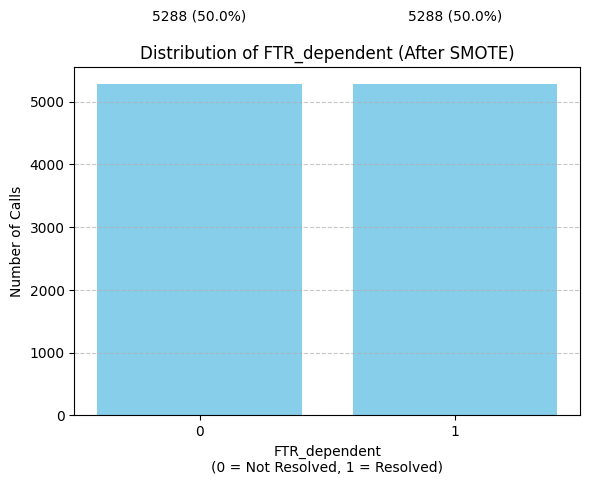

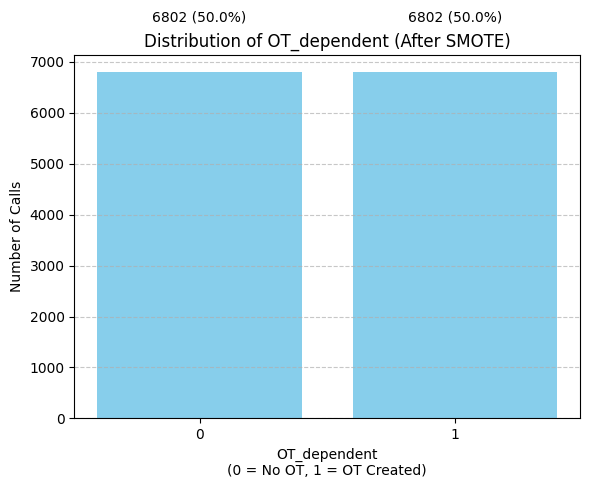

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# FTR distribution after SMOTE
ftr_after = pd.Series(y_train_ftr_res).value_counts().sort_index()
ftr_after_pct = ftr_after / ftr_after.sum()

plt.figure(figsize=(6, 5))
bars = plt.bar(ftr_after.index, ftr_after.values, color='skyblue')
for bar, val, pct in zip(bars, ftr_after.values, ftr_after_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
             f"{val} ({pct:.1%})", ha='center', fontsize=10)

plt.title("Distribution of FTR_dependent (After SMOTE)")
plt.xlabel("FTR_dependent\n(0 = Not Resolved, 1 = Resolved)")
plt.ylabel("Number of Calls")
plt.xticks([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# OT distribution after SMOTE
ot_after = pd.Series(y_train_ot_res).value_counts().sort_index()
ot_after_pct = ot_after / ot_after.sum()

plt.figure(figsize=(6, 5))
bars = plt.bar(ot_after.index, ot_after.values, color='skyblue')
for bar, val, pct in zip(bars, ot_after.values, ot_after_pct.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1000,
             f"{val} ({pct:.1%})", ha='center', fontsize=10)

plt.title("Distribution of OT_dependent (After SMOTE)")
plt.xlabel("OT_dependent\n(0 = No OT, 1 = OT Created)")
plt.ylabel("Number of Calls")
plt.xticks([0, 1])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### <a id='toc1_2_8_'></a>[Normalize Numerical Variables](#toc0_)

In [31]:
from sklearn.preprocessing import StandardScaler

def scale_and_return_scaler(X_train, X_test, binary_prefixes):
    numeric_cols = X_train.select_dtypes(include=["number"]).columns

    cols_to_scale = [
        col for col in numeric_cols
        if not any(col.startswith(prefix) for prefix in binary_prefixes)
    ]

    scaler = StandardScaler()
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    if cols_to_scale:
        X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

    return X_train_scaled, X_test_scaled, scaler, cols_to_scale

In [32]:
# Define binary prefixes
binary_prefixes = [
    "call_TOPIC_CLASSIFIC_ENTRY_AT_FT_",
    "PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_",
    "LAG1_LVL2_",
    "IS_FIRST_CALL"
]

# --- Scale TMC ---
X_train_scaled_tmc, X_test_scaled_tmc, scaler_tmc, cols_to_scale_tmc = scale_and_return_scaler(
    X_train_tmc, X_test_tmc, binary_prefixes
)

# --- Scale FTR ---
X_train_scaled_ftr, X_test_scaled_ftr, scaler_ftr, cols_to_scale_ftr = scale_and_return_scaler(
    X_train_ftr, X_test_ftr, binary_prefixes
)

# --- Scale OT ---
X_train_scaled_ot, X_test_scaled_ot, scaler_ot, cols_to_scale_ot = scale_and_return_scaler(
    X_train_ot, X_test_ot, binary_prefixes
)

# Optional: Combine if needed
X_scaled = pd.concat([X_train_scaled_tmc, X_test_scaled_tmc])

In [ ]:
X_train_scaled_tmc.head()

,call_LEG_IF_ID,gc_COUNT_CALLS,gc_DAYS_ACTIVE,gc_MEAN_FTR,gc_MEAN_TMC,gc_OTS_BY_CALL,gc_COUNT_CALLS_IF,gc_MEAN_FTR_IF,gc_MEAN_TMC_IF,gc_TOTAL_OTS_IF,gc_OTS_BY_CALL_IF,gc_COUNT_CALLS_OTHER,gc_MEAN_FTR_OTHER,gc_MEAN_TMC_OTHER,gc_TOTAL_OTS_OTHER,gc_OTS_BY_CALL_OTHER,gc_COUNT_CALLS_VF,gc_MEAN_FTR_VF,gc_MEAN_TMC_VF,gc_TOTAL_OTS_VF,gc_OTS_BY_CALL_VF,gc_COUNT_CALLS_TV,gc_MEAN_FTR_TV,gc_MEAN_TMC_TV,gc_TOTAL_OTS_TV,gc_OTS_BY_CALL_TV,gc_COUNT_CALLS_MOVEL,gc_MEAN_FTR_MOVEL,gc_MEAN_TMC_MOVEL,gc_TOTAL_OTS_MOVEL,gc_CALLS_IF_BINARY,gc_CALLS_OTHER_BINARY,gc_CALLS_VF_BINARY,gc_CALLS_TV_BINARY,gc_CALLS_MOVEL_BINARY,client_CLIENT_AGE_YEARS,client_CLIENT_ANTIQUITY_YEARS,client_NR_SAS,client_ARPU_CALCULATED,client_ARPU_CLIENT,client_PF_CLIENT_MONTHS,client_LEG_DURATION_MEAN_365_ASSUNTO_IF,client_LEG_DURATION_MEAN_365_ASSUNTO_MOVEL,client_LEG_DURATION_MEAN_365_ASSUNTO_OTHER,client_LEG_DURATION_MEAN_365_ASSUNTO_TV,client_LEG_DURATION_MEAN_365_ASSUNTO_VF,client_LEG_DURATION_MEAN_365_TOTAL,client_RPC_MEAN_365_ASSUNTO_IF,client_RPC_MEAN_365_ASSUNTO_MOVEL,client_RPC_MEAN_365_ASSUNTO_OTHER,client_RPC_MEAN_365_ASSUNTO_TV,client_RPC_MEAN_365_ASSUNTO_VF,client_RPC_MEAN_365_TOTAL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_IF,client_FTR_CALCULATED_MEAN_365_ASSUNTO_MOVEL,client_FTR_CALCULATED_MEAN_365_ASSUNTO_OTHER,client_FTR_CALCULATED_MEAN_365_ASSUNTO_TV,client_FTR_CALCULATED_MEAN_365_ASSUNTO_VF,client_FTR_CALCULATED_MEAN_365_TOTAL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_IF,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_MOVEL,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_OTHER,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_TV,client_NR_INCIDENTS_PER_LEG_SUM_365_ASSUNTO_VF,client_NR_INCIDENTS_PER_LEG_SUM_365_TOTAL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_IF,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_MOVEL,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_OTHER,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_TV,client_CALL_IF_ID_NUNIQUE_365_ASSUNTO_VF,client_CALL_IF_ID_NUNIQUE_365_TOTAL,client_Age_missing,days_since_prev_call_for_client,client_called_in_last_7_days,days_since_last_call_gc,is_weekend,hour_of_day,IS_FIRST_CALL,CNT_LVL2_ADESÃO/ALTERAÇÃO,CNT_LVL2_BOX,CNT_LVL2_CARTÃO SIM/ESIM/TWIN,CNT_LVL2_INTERNET FIXA,CNT_LVL2_MAIS INFORMAÇÕES,CNT_LVL2_OUTROS,CNT_LVL2_SEM VOZ DE CLIENTE,CNT_LVL2_TELEVISÃO,CNT_LVL2_VOZ FIXA,PROP_LVL2_ADESÃO/ALTERAÇÃO,PROP_LVL2_BOX,PROP_LVL2_CARTÃO SIM/ESIM/TWIN,PROP_LVL2_INTERNET FIXA,PROP_LVL2_MAIS INFORMAÇÕES,PROP_LVL2_OUTROS,PROP_LVL2_SEM VOZ DE CLIENTE,PROP_LVL2_TELEVISÃO,PROP_LVL2_VOZ FIXA,LAG1_LVL2_ADESÃO/ALTERAÇÃO,LAG1_LVL2_BOX,LAG1_LVL2_CARTÃO SIM/ESIM/TWIN,LAG1_LVL2_INTERNET FIXA,LAG1_LVL2_MAIS INFORMAÇÕES,LAG1_LVL2_OUTROS,LAG1_LVL2_SEM VOZ DE CLIENTE,LAG1_LVL2_TELEVISÃO,LAG1_LVL2_VOZ FIXA,avg_duration,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,call_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_Móvel,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_OTHER,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_TV,PREV_CALL_TOPIC_CLASSIFIC_ENTRY_AT_FT_VF
34114,0.167708,-0.554444,-0.213383,-0.605655,0.068702,-0.123717,-0.490995,0.050840,-0.039799,-0.337787,0.651153,-0.546919,-0.526411,0.141761,-0.795451,-0.531019,-0.581437,-0.766607,-0.401627,-0.933694,-1.074436,-0.317079,-0.714494,-0.272017,-0.602218,-1.149304,-0.663002,0.017984,0.506654,-0.536452,0.0,0.0,0.047839,0.0,0.0,0.544690,-0.216786,-0.051821,-0.028055,-0.038618,0.950629,-0.416148,-0.119286,-0.4209,-0.342080,-0.13477,-0.703978,-0.414527,-0.122825,-0.526513,-0.356373,-0.152832,-0.78685,0.395304,0.112199,0.245254,0.333605,0.118189,0.623073,-0.383047,-0.111403,-0.215002,-0.335729,-0.135284,-0.365380,-0.414191,-0.115171,-0.205258,-0.351706,-0.149437,-0.343797,-0.445697,-0.229253,0.838053,-0.072021,-0.642817,1.313066,0,-0.145353,2.711953,-0.091855,-0.516415,-0.115825,-0.196879,-0.102638,-0.350064,-0.179574,-0.137564,3.933188,-0.099717,-0.619111,-0.124347,-0.338494,-0.174632,-0.384718,-0.192627,0,1,0,0,0,0,0,0,0,0.605256,False,False,True,False,F

## <a id='toc1_3_'></a>[Regression Models to predict TMC](#toc0_)

### <a id='toc1_3_1_'></a>[TMC: Rule-Based (Average)](#toc0_)

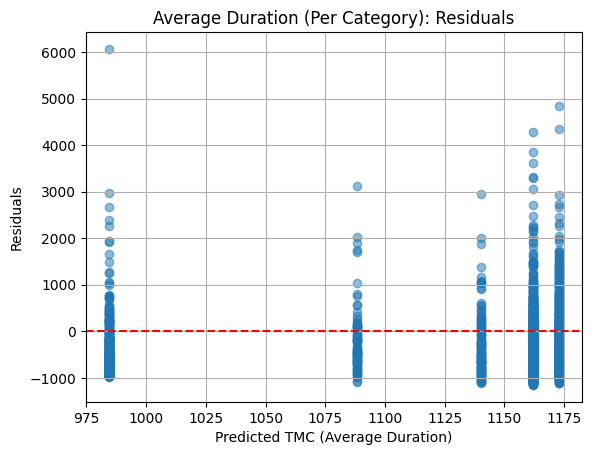

Average Duration (Per Category) Prediction:
R²: -0.0885
MSE: 583224.51
RMSE: 763.69

Pairwise Comparison Evaluation:
Pairwise Accuracy: 41.04%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Reset indices to ensure alignment
y_test_tmc = y_test_tmc.reset_index(drop=True)  # Reset index for y_test_tmc

# Reference avg_duration from full_merged_df and match the indices of X_test_scaled_tmc
y_pred_avg = full_merged_df.loc[X_test_scaled_tmc.index, 'avg_duration'].reset_index(drop=True).values

# Residuals
residuals_avg = y_test_tmc - y_pred_avg

# Residual plot
plt.figure()
plt.scatter(y_pred_avg, residuals_avg, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Average Duration (Per Category): Residuals")
plt.xlabel("Predicted TMC (Average Duration)")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

# Performance metrics
print("Average Duration (Per Category) Prediction:")
r2_avg = r2_score(y_test_tmc, y_pred_avg)
print(f"R²: {r2_avg:.4f}")

# Manually calculate MSE and RMSE
mse_avg = np.mean((y_test_tmc - y_pred_avg) ** 2)
rmse_avg = np.sqrt(mse_avg)
print(f"MSE: {mse_avg:.2f}")
print(f"RMSE: {rmse_avg:.2f}")

# Pairwise comparison evaluation
print("\nPairwise Comparison Evaluation:")

# Number of pairs to sample
num_samples = 100000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_tmc), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_tmc[i]
    actual_j = y_test_tmc[j]

    # Predicted values (from 'avg_duration')
    pred_i = y_pred_avg[i]
    pred_j = y_pred_avg[j]

    # Compare actual and predicted rankings
    if (actual_i > actual_j and pred_i > pred_j) or (actual_i < actual_j and pred_i < pred_j):
        correct_predictions += 1

# Calculate pairwise accuracy
pairwise_accuracy_avg = correct_predictions / num_samples
print(f"Pairwise Accuracy: {pairwise_accuracy_avg:.2%}")

#### <a id='toc1_3_1_1_'></a>[TMC: Linear Regression](#toc0_)

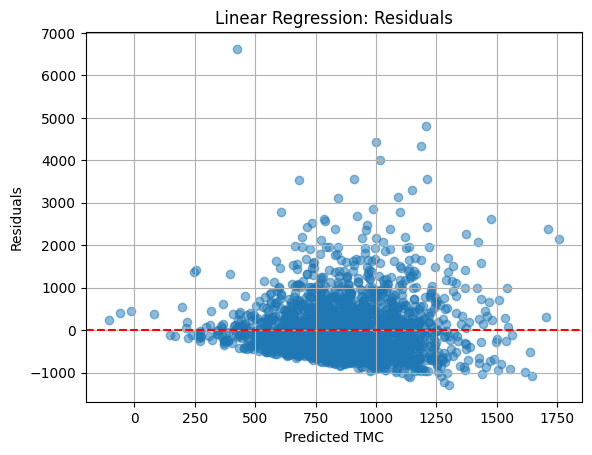

Linear Regression:
R²: 0.1051
MSE: 479480.38
RMSE: 692.45


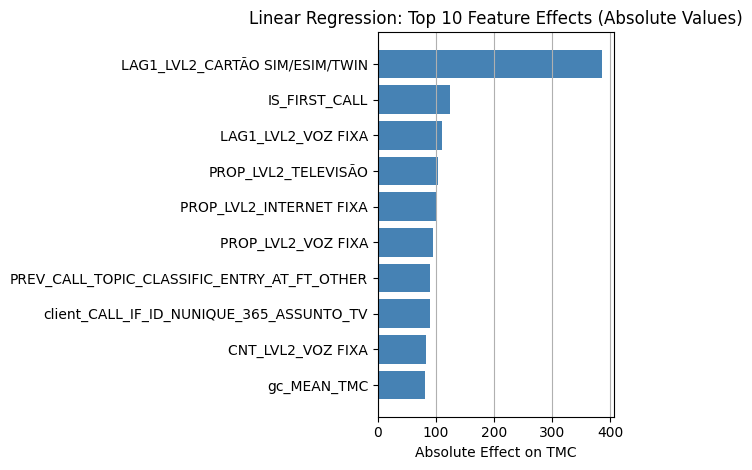


Pairwise Comparison Evaluation:
Pairwise Accuracy: 61.86%


In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train_scaled_tmc, y_train_tmc)
y_pred_lr = lr.predict(X_test_scaled_tmc)
residuals_lr = y_test_tmc - y_pred_lr

# Ensure data types are consistent
y_test_tmc = np.array(y_test_tmc)
y_pred_lr = np.array(y_pred_lr)

# Residual plot
plt.figure()
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Linear Regression: Residuals")
plt.xlabel("Predicted TMC")
plt.ylabel("Residuals")
plt.grid(True)
plt.show()

# Performance metrics
print("Linear Regression:")
print(f"R²: {r2_score(y_test_tmc, y_pred_lr):.4f}")

# Manually calculate MSE and RMSE
mse = np.mean((y_test_tmc - y_pred_lr) ** 2)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# Coefficient importance (absolute values)
coef_df = pd.DataFrame({'Feature': X_train_scaled_tmc.columns, 'Coefficient': lr.coef_})
coef_df['abs_coef'] = coef_df['Coefficient'].abs()
top10 = coef_df.sort_values(by='abs_coef', ascending=False).head(10)

# Plot top 10 feature effects (absolute values)
plt.figure()
plt.barh(top10['Feature'], top10['abs_coef'], color='steelblue')  # Use absolute coefficients
plt.xlabel("Absolute Effect on TMC")
plt.title("Linear Regression: Top 10 Feature Effects (Absolute Values)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

# Pairwise comparison evaluation
print("\nPairwise Comparison Evaluation:")

# Number of pairs to sample
num_samples = 100000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_tmc), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_tmc[i]
    actual_j = y_test_tmc[j]

    # Predicted values
    pred_i = y_pred_lr[i]
    pred_j = y_pred_lr[j]

    # Compare actual and predicted rankings
    if (actual_i > actual_j and pred_i > pred_j) or (actual_i < actual_j and pred_i < pred_j):
        correct_predictions += 1

# Calculate pairwise accuracy
pairwise_accuracy_lr_tmc = correct_predictions / num_samples
print(f"Pairwise Accuracy: {pairwise_accuracy_lr_tmc:.2%}")

Mean absolute SHAP values

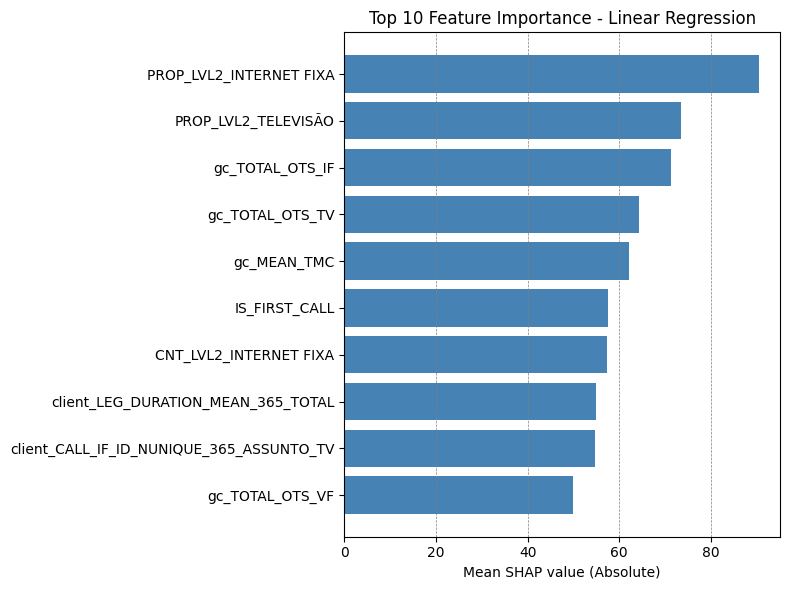

In [ ]:
# --- CREATE a SHAP Explainer for the linear model ---
explainer = shap.LinearExplainer(lr, X_train_scaled_tmc, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_test_scaled_tmc)

# --- COMPUTE mean absolute SHAP per feature ---
abs_shap = np.abs(shap_values)
mean_abs_shap = abs_shap.mean(axis=0)

# Build a DataFrame of feature → mean |SHAP|
feature_names = X_train_scaled_tmc.columns
shap_df = pd.DataFrame({
    "Feature":       feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
})

# Sort descending and take top 10
top10_shap = shap_df.sort_values(by="Mean_Abs_SHAP", ascending=False).head(10)

# --- PLOT a horizontal bar chart ---
plt.figure(figsize=(8, 6))
plt.barh(top10_shap["Feature"], top10_shap["Mean_Abs_SHAP"], color="steelblue")
plt.gca().invert_yaxis()  # Highest importance on top

# Add vertical gray dashed gridlines on the x-axis
plt.grid(axis="x", color="gray", linestyle="--", linewidth=0.5)

plt.xlabel("Mean SHAP value (Absolute)")
plt.title("Top 10 Feature Importance - Linear Regression")
plt.tight_layout()
plt.show()

### <a id='toc1_3_2_'></a>[TMC: XGBoost Regressor](#toc0_)

In [36]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import shap


# 1. Re-encode categorical variables (if not already done)
# final_df = pd.get_dummies(reduced_df, drop_first=True)

# 2. Save LEG_IF_ID as index if not already
if "LEG_IF_ID" in final_df.columns:
    final_df = final_df.set_index("LEG_IF_ID")

# 3. Define features and target
X = final_df.drop(columns=["TMC_dependent", "FTR_dependent", "OT_dependent"])
y_tmc = final_df["TMC_dependent"]

# 4. Train/Test Split
X_train_tmc, X_test_tmc, y_train_tmc, y_test_tmc = train_test_split(X, y_tmc, test_size=0.2, random_state=42)



In [37]:
# 5. Hyperparameter tuning

# Optional: Baseline for comparison
xgb_base = XGBRegressor(random_state=42)
xgb_base.fit(X_train_tmc, y_train_tmc)

from sklearn.model_selection import GridSearchCV

# Define base estimator and coarse grid
base_xgb = XGBRegressor(random_state=42)
param_grid_coarse = {
    "n_estimators":   [50, 100, 200],
    "max_depth":      [4, 6, 8],
    "learning_rate":  [0.01, 0.1, 0.2],
}

# Run GridSearchCV
grid_coarse = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_coarse,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_coarse.fit(X_train_tmc, y_train_tmc)

# Grab the best estimator
print("Coarse best params:", grid_coarse.best_params_)
xgb_tmc = grid_coarse.best_estimator_


Fitting 3 folds for each of 27 candidates, totalling 81 fits
Coarse best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 50}


XGBoost Regressor for TMC
R²:   0.1193
MSE:  471875.26
RMSE: 686.93


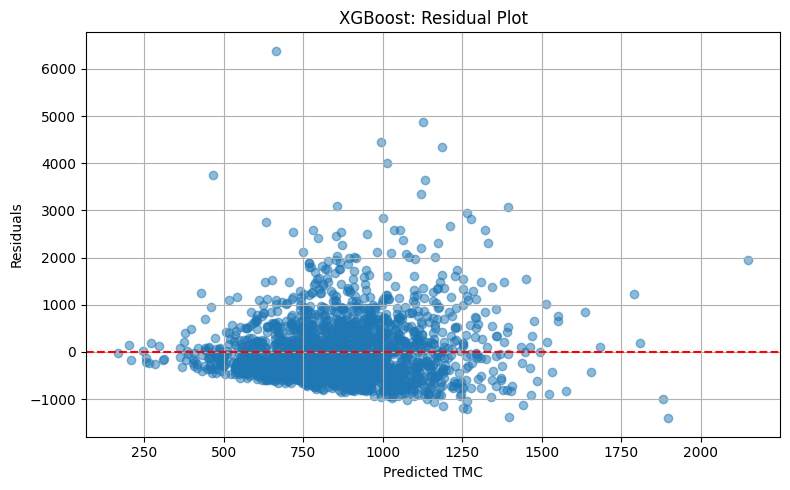

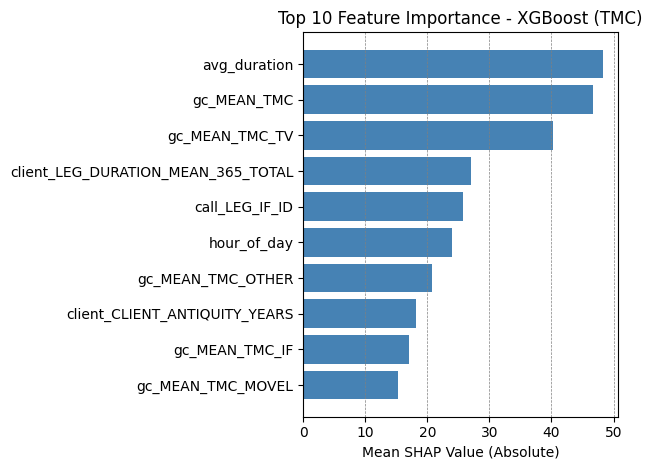


Pairwise Comparison Evaluation:
Pairwise Accuracy: 62.36%


In [90]:
# 6. Predict and evaluate
y_pred_xgb = xgb_tmc.predict(X_test_tmc)
residuals_xgb = y_test_tmc - y_pred_xgb

# Ensure data types are consistent
y_test_tmc = np.array(y_test_tmc)
y_pred_xgb = np.array(y_pred_xgb)

print("XGBoost Regressor for TMC")
print(f"R²:   {r2_score(y_test_tmc, y_pred_xgb):.4f}")

# Manually calculate MSE and RMSE
mse = np.mean((y_test_tmc - y_pred_xgb) ** 2)
rmse = np.sqrt(mse)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")

# 7. Residual plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("XGBoost: Residual Plot")
plt.xlabel("Predicted TMC")
plt.ylabel("Residuals")
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Feature importances with absolute SHAP values
# Get SHAP values for feature effects
explainer = shap.Explainer(xgb_tmc)
shap_values = explainer(X_train_tmc)

# Mean absolute SHAP values per feature
shap_df = pd.DataFrame({
    'Feature': X_train_tmc.columns,
    'Mean_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})
top10_shap = shap_df.sort_values(by='Mean_SHAP', ascending=False).head(10)

# 9. Plot top 10 feature effects (absolute SHAP values)
plt.figure()
plt.barh(top10_shap['Feature'], top10_shap['Mean_SHAP'], color='steelblue')
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - XGBoost (TMC)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

# 10. Pairwise comparison evaluation
print("\nPairwise Comparison Evaluation:")

# Number of pairs to sample
num_samples = 1000000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_tmc), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_tmc[i]
    actual_j = y_test_tmc[j]

    # Predicted values
    pred_i = y_pred_xgb[i]
    pred_j = y_pred_xgb[j]

    # Compare actual and predicted rankings
    if (actual_i > actual_j and pred_i > pred_j) or (actual_i < actual_j and pred_i < pred_j):
        correct_predictions += 1

# Calculate pairwise accuracy
pairwise_accuracy_xgb_tmc = correct_predictions / num_samples
print(f"Pairwise Accuracy: {pairwise_accuracy_xgb_tmc:.2%}")

Importance Gain for additional Information

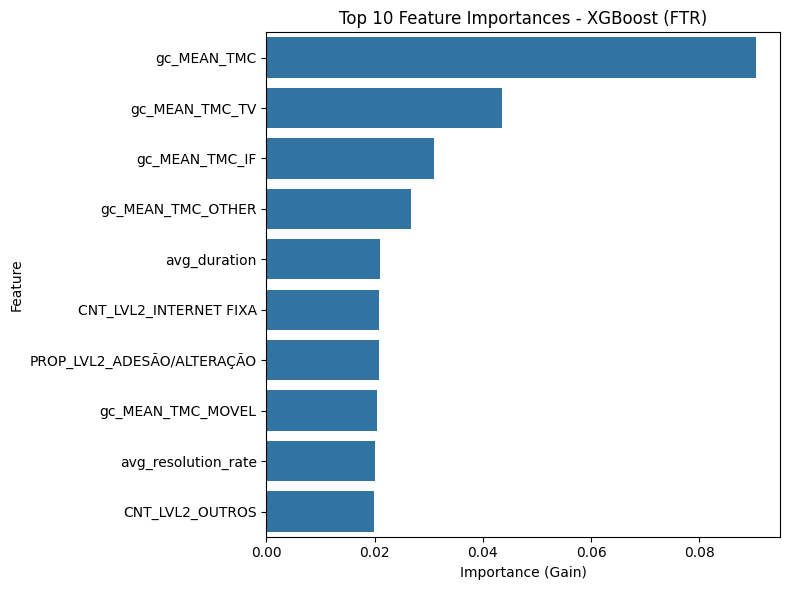

In [ ]:
# Feature importance from XGBoost (gain-based by default)
importances = xgb_tmc.feature_importances_
feature_names = X_train_tmc.columns if hasattr(X_train_tmc, "columns") else [f"Feature {i}" for i in range(X_train_tmc.shape[1])]

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.title("Top 10 Feature Importances - XGBoost (FTR)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### <a id='toc1_3_3_'></a>[TMC: Neural Network](#toc0_)

1.3.3.1. Set up Neural Network trunk

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import getpass
import dask.dataframe as dd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import (
    r2_score,
    precision_recall_curve,
    accuracy_score, precision_score, recall_score,
    classification_report, confusion_matrix, mean_squared_error,
    roc_curve, roc_auc_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Dense, Embedding, Flatten,
    Concatenate, Dropout, BatchNormalization, LeakyReLU
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import re

from keras_tuner import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters


In [ ]:
input_exclude=["TMC_dependent", "FTR_dependent", "OT_dependent", 'call_LEG_IF_ID']
input_columns = [col for col in reduced_df.columns if col not in input_exclude]

# 1) LOAD & PREPARE DATA
df = reduced_df.copy()
targets = ["TMC_dependent", "FTR_dependent", "OT_dependent"]

# Keep only the needed cols and drop rows with missing targets
df = full_merged_df[input_columns + targets].dropna()

# 2) IDENTIFY CATEGORICAL VS NUMERIC
cat_feats = [c for c in input_columns if df[c].nunique() < 50]
num_feats = [c for c in input_columns if c not in cat_feats]

# 3) ENCODE CATEGORICALS
label_encoders = {}
for c in cat_feats:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    label_encoders[c] = le

# 4) EXTRACT TARGET ARRAYS
y_reg = df["TMC_dependent"].values
y_ftr = df["FTR_dependent"].astype(int).values
y_ot  = df["OT_dependent"].astype(int).values

# 5) SPLIT DATA
X_train, X_test, y_reg_train, y_reg_test, y_ftr_train, y_ftr_test, y_ot_train, y_ot_test = \
    train_test_split(
        df[input_columns], y_reg, y_ftr, y_ot,
        test_size=0.2, random_state=42
    )

# 6) SCALE NUMERIC
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_feats])
X_test_num  = scaler.transform(X_test[num_feats])

# 7) MODEL BUILDING
def build_tabular_nn(hp, cat_feats, num_dim, task='regression'):
    inputs, embs = [], []
    # categorical embeddings
    for c in cat_feats:
        n_unique = df[c].nunique()
        clean_c = clean_name(c)
        inp = Input(shape=(1,), name=f"{clean_c}_in")
        # Tune embedding size
        emb_size = hp.Int(f'{clean_c}_emb_size', min_value=8, max_value=64, step=8)
        emb = Embedding(input_dim=n_unique + 1, output_dim=emb_size, name=f"{clean_c}_emb")(inp)
        emb = Flatten()(emb)
        inputs.append(inp)
        embs.append(emb)
    # numeric input
    num_in = Input(shape=(num_dim,), name="num_in")
    inputs.append(num_in)
    embs.append(num_in)

    # shared trunk
    x = Concatenate()(embs)
    # Tune the number of layers and units
    for i in range(hp.Int('num_dense_layers', min_value=1, max_value=3)):
        x = Dense(hp.Int(f'dense_units_{i}', min_value=64, max_value=256, step=32))(x)
        x = BatchNormalization()(x)
        x = LeakyReLU()(x)
        # Tune dropout rate
        x = Dropout(hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1))(x)

    # task-specific head
    if task == 'regression':
        out = Dense(1, name='out')(x)
        loss, metrics = 'mse', ['mae']
    else:
        out = Dense(1, activation='sigmoid', name='out')(x)
        loss, metrics = 'binary_crossentropy', ['accuracy'] 

    model = Model(inputs, out)
    # Tune the learning rate
    optimizer = Adam(hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG'))
    model.compile(optimizer=optimizer, loss=loss, metrics=metrics)
    return model

# 8) HYPERPARAMETER TUNING
from keras_tuner import HyperModel

class MyHyperModel(HyperModel):
    def __init__(self, cat_feats, num_dim, task):
        self.cat_feats = cat_feats
        self.num_dim = num_dim
        self.task = task

    def build(self, hp):
        # Define the hyperparameter search space here
        hp.Int('num_dense_layers', min_value=1, max_value=3, step=1)
        for i in range(3):
            hp.Int(f'dense_units_{i}', min_value=64, max_value=256, step=32)
            hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.5, step=0.1)
        hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='LOG')
        for c in self.cat_feats:
             clean_c = clean_name(c)
             hp.Int(f'{clean_c}_emb_size', min_value=8, max_value=64, step=8)

        # Build the model using the existing function and the hyperparameter object
        return build_tabular_nn(hp, self.cat_feats, self.num_dim, self.task)

# 9) INPUT DICTIONARY BUILDER
def clean_name(name):
    return re.sub(r'[^0-9a-zA-Z]+', '_', str(name))
def make_input_dict(df_feats, num_arr):
    d = {"num_in": num_arr}
    for c in cat_feats:
        clean_c = clean_name(c)
        d[f"{clean_c}_in"] = df_feats[c].values
    return d

inp_tr = make_input_dict(X_train, X_train_num)
inp_te = make_input_dict(X_test,  X_test_num)

# 10) TRAIN & EVALUATE
early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_cb = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

1.3.3.2. Regression Head and Tuning

Trial 10 Complete [00h 01m 06s]
val_loss: 487185.375

Best val_loss So Far: 486506.25
Total elapsed time: 00h 13m 05s

--- Building final Regression Model with best hyperparameters ---

--- Training final Regression Model ---
Epoch 1/30
208/208 - 23s - 110ms/step - loss: 1110517.0000 - mae: 808.4319 - val_loss: 781882.3750 - val_mae: 640.0859 - learning_rate: 0.0037
Epoch 2/30
208/208 - 2s - 8ms/step - loss: 623765.9375 - mae: 541.9957 - val_loss: 467415.5312 - val_mae: 473.0788 - learning_rate: 0.0037
Epoch 3/30
208/208 - 2s - 8ms/step - loss: 438158.5000 - mae: 473.0671 - val_loss: 449515.3125 - val_mae: 480.2169 - learning_rate: 0.0037
Epoch 4/30
208/208 - 2s - 8ms/step - loss: 424262.4375 - mae: 475.1707 - val_loss: 445370.8438 - val_mae: 485.8798 - learning_rate: 0.0037
Epoch 5/30
208/208 - 2s - 8ms/step - loss: 416886.3750 - mae: 471.7383 - val_loss: 449322.7500 - val_mae: 483.4789 - learning_rate: 0.0037
Epoch 6/30
208/208 - 2s - 8ms/step - loss: 417233.2188 - mae: 473.1961 - va

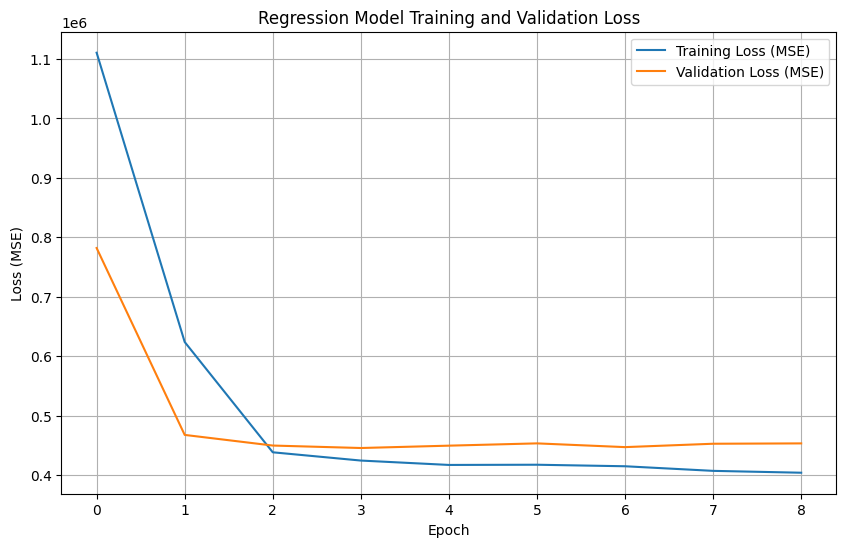

In [ ]:
## --- Regression Model Tuning --------------------------------------------------------
print("\n--- Tuning Regression Model ---")
tuner_reg = RandomSearch(
    hypermodel=MyHyperModel(cat_feats, len(num_feats), task='regression'),
    objective='val_loss',
    max_trials=10,         # Number of hyperparameter combinations to try
    executions_per_trial=1,# Number of models to train for each combination
    directory='my_tuning_dir',
    project_name='regression_tuning'
)

# Run the hyperparameter search. The tuner will train models internally.
tuner_reg.search(
    inp_tr, y_reg_train,
    epochs=30, 
    validation_data=(inp_te, y_reg_test), # Use test data for validation during tuning
    callbacks=[early, lr_cb]
)

# Get the best hyperparameters found by the tuner
best_hps_reg = tuner_reg.get_best_hyperparameters(num_trials=1)[0]

# Build the final reg_model using the best hyperparameters
print("\n--- Building final Regression Model with best hyperparameters ---")
reg_model = build_tabular_nn(best_hps_reg, cat_feats, len(num_feats), task='regression')

# Train the final model on the full training data
print("\n--- Training final Regression Model ---")
history_reg = reg_model.fit(
    inp_tr, y_reg_train,
    validation_split=0.2,
    epochs=30,
    callbacks=[early, lr_cb],
    verbose=2
)

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_reg.history['loss'], label='Training Loss (MSE)')
plt.plot(history_reg.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Regression Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

1.3.3.3. Evaluation

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step
R² (duration): 0.09191703796386719
RMSE (duration): 697.5427854260985


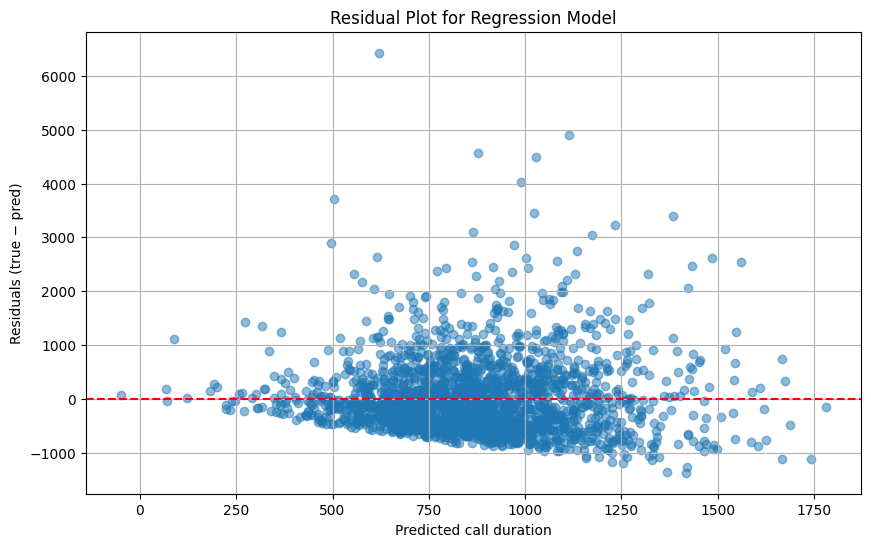

Pairwise Accuracy (NN Regression): 61.00%


In [44]:
# Evaluation ------------------------------------------------------------------
y_pred_reg = reg_model.predict(inp_te).flatten()
print("R² (duration):", r2_score(y_reg_test, y_pred_reg))
mse = mean_squared_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mse)
print("RMSE (duration):", rmse)

# recompute residuals
residuals = y_reg_test - y_pred_reg

# Residual plot
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted call duration')
plt.ylabel('Residuals (true − pred)')
plt.title('Residual Plot for Regression Model')
plt.grid(True)
plt.show()

# Pairwise Accuracy ------------------------------------------------------------
# Number of pairs to sample (adjust if needed)
num_samples_reg = 100000

# Randomly sample pairs of indices from the test set
indices_reg = np.random.choice(len(y_reg_test), size=(num_samples_reg, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions_reg = 0

# Perform pairwise comparisons
for i, j in indices_reg:
    # Actual values
    actual_i = y_reg_test[i]
    actual_j = y_reg_test[j]

    # Predicted values
    pred_i = y_pred_reg[i]
    pred_j = y_pred_reg[j]

    # Compare actual and predicted rankings, ignoring ties
    if (actual_i > actual_j and pred_i > pred_j) or \
       (actual_i < actual_j and pred_i < pred_j):
        correct_predictions_reg += 1

# Calculate pairwise accuracy
pairwise_accuracy_reg = correct_predictions_reg / num_samples_reg
print(f"Pairwise Accuracy (NN Regression): {pairwise_accuracy_reg:.2%}")

1.3.3.4. SHAP

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
700/700 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
699/699 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
7

<ipython-input-49-819a4e95fae9>:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


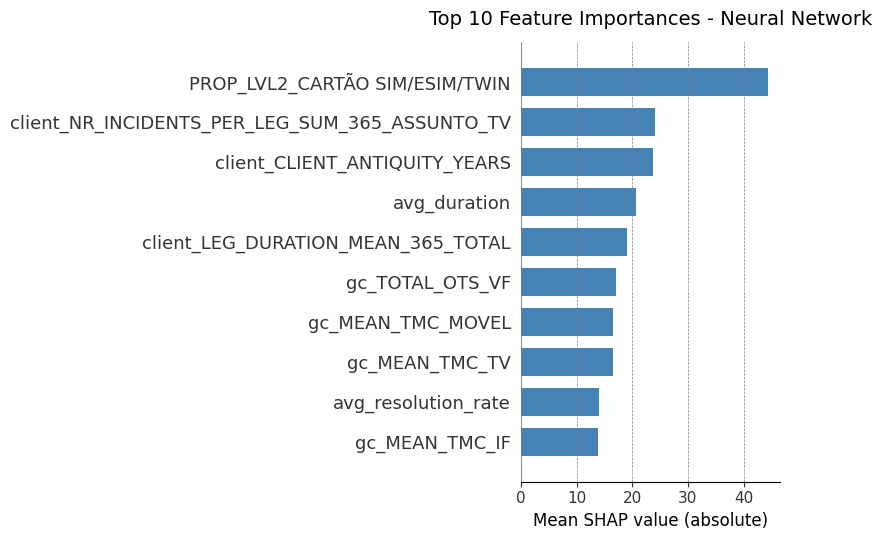

In [ ]:
# --- Configuration for SHAP sampling ---
background_sample_size_ke = 10
test_sample_size_ke = 20

# --- Helper function for Keras model prediction within SHAP ---
def create_predict_fn(model, cat_features_list, num_features_list, scaler, input_columns, clean_name_func):
    def predict_fn(X_arr_from_kernel):
        df_temp = pd.DataFrame(X_arr_from_kernel, columns=input_columns)
        d = {}
        for c in cat_features_list:
            clean_c = clean_name_func(c)
            d[f"{clean_c}_in"] = df_temp[c].values
        d["num_in"] = scaler.transform(df_temp[num_features_list])
        return model.predict(d).flatten()
    return predict_fn

# --- Core SHAP Calculation ---
def get_shap_values(model, X_train_df, X_test_sample_df, cat_features_list, num_features_list, scaler, input_columns, clean_name_func):
    """Calculates SHAP values using KernelExplainer."""

    # Prepare background and test data samples for KernelExplainer
    bg_idx = np.random.choice(len(X_train_df), size=background_sample_size_ke, replace=False)
    tst_idx = np.random.choice(len(X_test_sample_df), size=test_sample_size_ke, replace=False)

    ke_X_background_arr = X_train_df.iloc[bg_idx].values
    ke_X_test_sample_arr = X_test_sample_df.iloc[tst_idx].values

    predict_func = create_predict_fn(model, cat_features_list, num_features_list, scaler, input_columns, clean_name_func)

    expl = shap.KernelExplainer(predict_func, ke_X_background_arr)
    shap_vals = expl.shap_values(ke_X_test_sample_arr)

    # Reduce shap_vals to 2D array if it's a list (for multi-output or classification models)
    if isinstance(shap_vals, list):
        if hasattr(model.output, 'op') and model.output.op.name == 'sigmoid' and len(shap_vals) == 2:
             shap_vals = shap_vals[1] # For binary classification, take the positive class
        elif len(shap_vals) == 1:
             shap_vals = shap_vals[0] # For regression or single-output models

    return shap_vals, X_test_sample_df.iloc[tst_idx] # Return sampled X_test_sample_df for plotting


# --- Plotting Function (retains flexibility for individual/combined plots) ---

def plot_shap_summary(shap_vals, X_used_for_plot, model_type_name, target_label, ax=None):
    # If no Axes was passed in, create a fresh figure
    if ax is None:
        plt.figure(figsize=(10, 6))
        # After calling shap.summary_plot, we will grab the current axes via plt.gca()
        plot_title = f"Top 10 Feature Importances - {model_type_name}"
    else:
        # If an existing Axes was given (for subplot use), switch to it before drawing
        plt.sca(ax)
        plot_title = f"Top 10 Feature Importances - {model_type_name}"

    # Draw the SHAP bar plot (bars only; do NOT call plt.show())
    shap.summary_plot(
        shap_vals,
        X_used_for_plot,
        feature_names = X_used_for_plot.columns,
        plot_type     = "bar",
        max_display   = 10,
        title         = plot_title,  # This argument DOES set a title, but SHAP may override it
        show          = False,
        color         = "steelblue"
    )

    # Immediately grab the axes that SHAP just created
    ax = plt.gca()

    # Now we can apply our customizations:
    ax.set_title(plot_title, fontsize=14, pad=12)
    ax.set_xlabel("Mean SHAP value (absolute)", fontsize=12)
    ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)

    # Adjust layout so nothing is cut off
    plt.tight_layout()


# Calculate SHAP values for all models
shap_tmc, X_tmc_plot_sample = get_shap_values(
    reg_model, X_train, X_test,
    cat_feats, num_feats,
    scaler, input_columns, clean_name
)

plot_shap_summary(shap_tmc, X_tmc_plot_sample, "Neural Network", "TMC")
plt.show()



### <a id='toc1_3_4_'></a>[TMC Model Comparison](#toc0_)

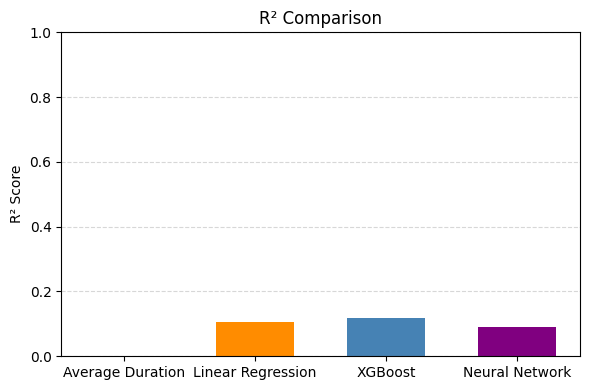

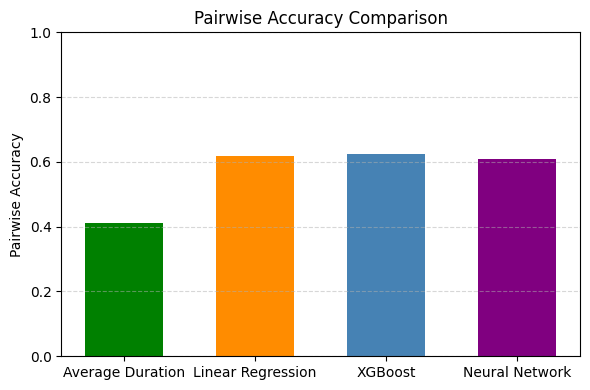

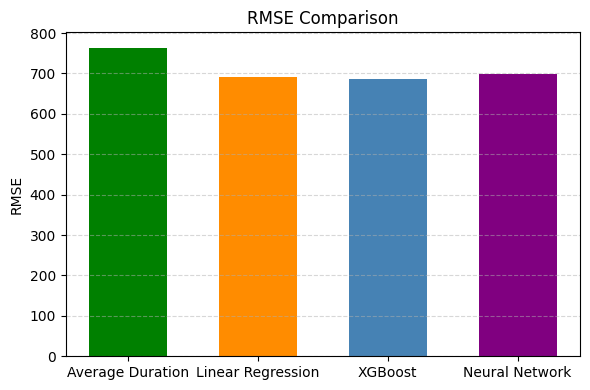

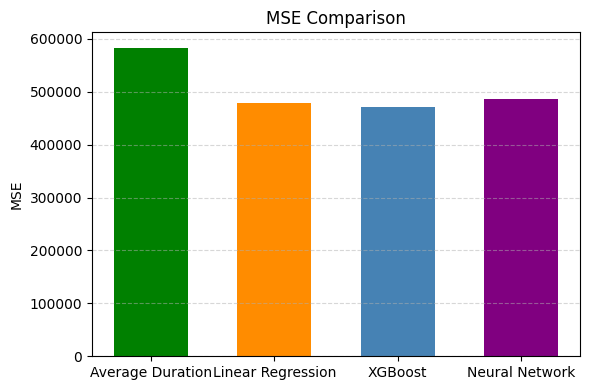


Summary of Model Performance:
               Model        R²        RMSE            MSE  Pairwise Accuracy
0   Average Duration -0.088478  763.691374  583224.514157            0.41043
1  Linear Regression  0.105141  692.445220  479480.382521            0.61860
2            XGBoost  0.119334  686.931776  471875.264920            0.62290
3     Neural Network  0.091917  697.542808  486565.969140            0.60997


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score

# Replace with your actual stored values:
r2_avg   = r2_score(y_test_tmc,    y_pred_avg)    # R² for average‐duration baseline
r2_lr    = r2_score(y_test_tmc,    y_pred_lr)     # R² for Linear Regression
r2_xgb   = r2_score(y_test_tmc,    y_pred_xgb)    # R² for XGBoost
r2_nn    = r2_score(y_reg_test,    y_pred_reg)    # R² for Neural Network

rmse_avg = np.sqrt(np.mean((y_test_tmc - y_pred_avg) ** 2))
rmse_lr  = np.sqrt(np.mean((y_test_tmc - y_pred_lr) ** 2))
rmse_xgb = np.sqrt(np.mean((y_test_tmc - y_pred_xgb) ** 2))
rmse_nn  = np.sqrt(np.mean((y_reg_test - y_pred_reg) ** 2))

mse_avg  = np.mean((y_test_tmc - y_pred_avg) ** 2)
mse_lr   = np.mean((y_test_tmc - y_pred_lr) ** 2)
mse_xgb  = np.mean((y_test_tmc - y_pred_xgb) ** 2)
mse_nn   = np.mean((y_reg_test - y_pred_reg) ** 2)

# Pairwise accuracy (replace with your actual computed values)
pairwise_accuracy_avg_tmc = pairwise_accuracy_avg
pairwise_accuracy_lr_tmc  = pairwise_accuracy_lr_tmc
pairwise_accuracy_xgb_tmc = pairwise_accuracy_xgb_tmc
pairwise_accuracy_nn_tmc  = pairwise_accuracy_reg

# Four labels (one per model)
labels = ['Average Duration', 'Linear Regression', 'XGBoost', 'Neural Network']
colors = ['green', 'darkorange', 'steelblue', 'purple']
width = 0.6  # bar width

# === Plot 1: R² Comparison ===
plt.figure(figsize=(6, 4))
plt.bar(labels, [r2_avg, r2_lr, r2_xgb, r2_nn], color=colors, width=width)
plt.ylabel("R² Score")
plt.title("R² Comparison")
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Plot 2: Pairwise Accuracy Comparison ===
plt.figure(figsize=(6, 4))
plt.bar(labels, [pairwise_accuracy_avg_tmc,
                 pairwise_accuracy_lr_tmc,
                 pairwise_accuracy_xgb_tmc,
                 pairwise_accuracy_nn_tmc],
        color=colors, width=width)
plt.ylabel("Pairwise Accuracy")
plt.title("Pairwise Accuracy Comparison")
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Plot 3: RMSE Comparison ===
plt.figure(figsize=(6, 4))
plt.bar(labels, [rmse_avg, rmse_lr, rmse_xgb, rmse_nn],
        color=colors, width=width)
plt.ylabel("RMSE")
plt.title("RMSE Comparison")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Plot 4: MSE Comparison ===
plt.figure(figsize=(6, 4))
plt.bar(labels, [mse_avg, mse_lr, mse_xgb, mse_nn],
        color=colors, width=width)
plt.ylabel("MSE")
plt.title("MSE Comparison")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# === Summary Table ===
summary_df = pd.DataFrame({
    "Model":            labels,
    "R²":               [r2_avg, r2_lr, r2_xgb, r2_nn],
    "RMSE":             [rmse_avg, rmse_lr, rmse_xgb, rmse_nn],
    "MSE":              [mse_avg, mse_lr, mse_xgb, mse_nn],
    "Pairwise Accuracy":[pairwise_accuracy_avg_tmc,
                         pairwise_accuracy_lr_tmc,
                         pairwise_accuracy_xgb_tmc,
                         pairwise_accuracy_nn_tmc]
})

print("\nSummary of Model Performance:")
print(summary_df)


## <a id='toc1_4_'></a>[Classification Models to predict FTR](#toc0_)

### <a id='toc1_4_1_'></a>[FTR: Rule-Based (Average)](#toc0_)

In [51]:
# Ensure y_test_ftr is aligned and remains a NumPy array
if isinstance(y_test_ftr, np.ndarray):
    y_test_ftr = y_test_ftr  # Already a NumPy array, no need to reset index
else:
    y_test_ftr = pd.Series(y_test_ftr).reset_index(drop=True).values  # Convert to Series, reset index, and back to NumPy array

# Reset indices for avg_resolution_rate
y_prob_avg = avg_resolution_rate.reset_index(drop=True).values  # Reset index for probabilities

ROC AUC: 0.5624


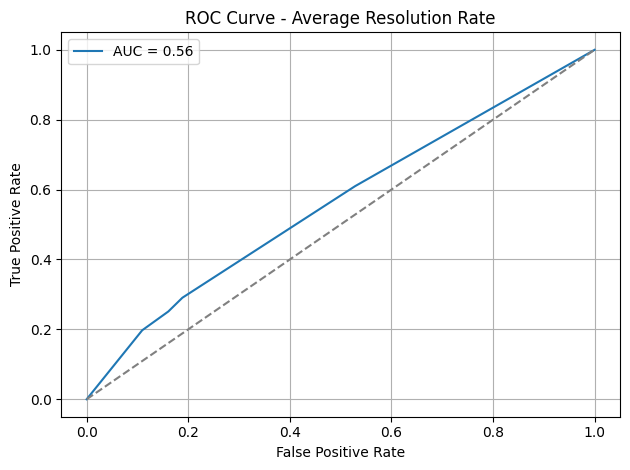

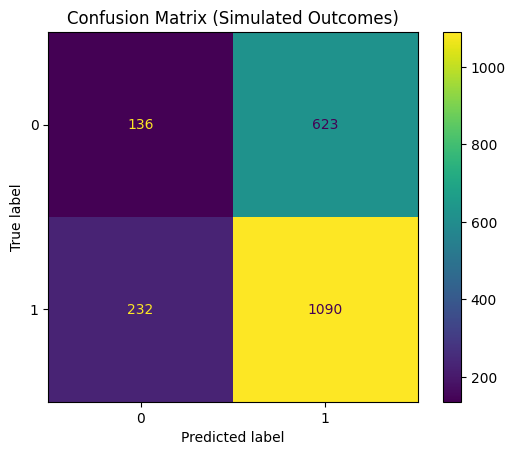

Precision: 0.6363
Recall: 0.8245
F1 Score: 0.7183

Pairwise Comparison Evaluation:
Valid Pairs: 46553
Correct Predictions: 18936
Pairwise Accuracy: 40.68%


In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import numpy as np

# Retrieve avg_resolution_rate from the original dataset
avg_resolution_rate = final_df.loc[X_test_ftr.index, 'avg_resolution_rate']

# Ensure y_test_ftr is aligned and remains a NumPy array
if isinstance(y_test_ftr, np.ndarray):
    y_test_ftr = y_test_ftr  # Already a NumPy array, no need to reset index
else:
    y_test_ftr = pd.Series(y_test_ftr).reset_index(drop=True).values  # Convert to Series, reset index, and back to NumPy array

# Reset indices for avg_resolution_rate
y_prob_avg = avg_resolution_rate.reset_index(drop=True).values  # Reset index for probabilities

# === ROC AUC ===
roc_auc = roc_auc_score(y_test_ftr, y_prob_avg)
print(f"ROC AUC: {roc_auc:.4f}")

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_test_ftr, y_prob_avg)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve - Average Resolution Rate")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Confusion Matrix ===
# Generate binary predictions based on probabilities
# Use a probabilistic approach: simulate outcomes based on probabilities
np.random.seed(42)  # For reproducibility
y_pred_simulated = np.random.binomial(1, y_prob_avg)

# Generate the confusion matrix
cm = confusion_matrix(y_test_ftr, y_pred_simulated)
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Simulated Outcomes)")
plt.show()

# === Precision, Recall, and F1 Score ===
precision = precision_score(y_test_ftr, y_pred_simulated)
recall = recall_score(y_test_ftr, y_pred_simulated)
f1 = f1_score(y_test_ftr, y_pred_simulated)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# === Pairwise Comparison Evaluation ===
print("\nPairwise Comparison Evaluation:")

# Number of pairs to sample
num_samples = 100000

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ftr), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0
valid_pairs = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ftr[i]
    actual_j = y_test_ftr[j]

    # Predicted probabilities
    prob_i = y_prob_avg[i]
    prob_j = y_prob_avg[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs += 1
    if (actual_i > actual_j and prob_i > prob_j) or (actual_i < actual_j and prob_i < prob_j):
        correct_predictions += 1

print(f"Valid Pairs: {valid_pairs}")
print(f"Correct Predictions: {correct_predictions}")

# Calculate pairwise accuracy
if valid_pairs > 0:
    pairwise_accuracy_avg = correct_predictions / valid_pairs
    print(f"Pairwise Accuracy: {pairwise_accuracy_avg:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

### <a id='toc1_4_2_'></a>[FTR: Logistic Regression](#toc0_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params (on subset): {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}

ROC AUC: 0.7146


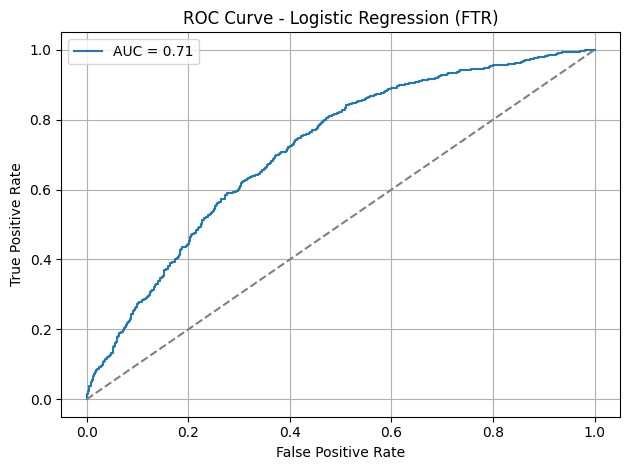

Best Threshold (F1): 0.45
Precision: 0.72, Recall: 0.90, F1: 0.80

Classification Report at Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.69      0.38      0.49       759
           1       0.72      0.90      0.80      1322

    accuracy                           0.71      2081
   macro avg       0.70      0.64      0.65      2081
weighted avg       0.71      0.71      0.69      2081



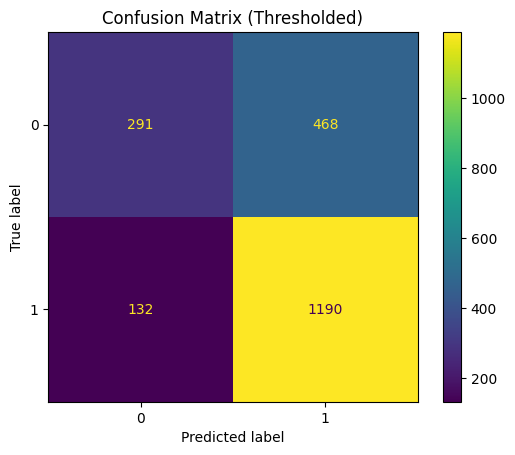

Precision (Adj): 0.7177
Recall    (Adj): 0.9002
F1 Score  (Adj): 0.7987
      Pred_Prob_FTR_1  Pred_Label  Actual_Label
1612         0.797585           1             1
806          0.717837           1             1
1907         0.512017           1             0
29           0.432791           0             0
1550         0.405765           0             0
1424         0.848651           1             1
109          0.641853           1             1
1537         0.412887           0             0
572          0.844364           1             1
51           0.502856           1             1

Pairwise Comparison Evaluation:
Pairwise Accuracy: 71.56%


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1) Sample a subset for quick hyperparameter tuning
sub_frac = 0.2
X_sub = X_train_scaled_ftr.sample(frac=sub_frac, random_state=42)
y_sub = y_train_ftr.loc[X_sub.index]

# 2) Define grid and run GridSearchCV on the subset
param_grid = {
    'C':       [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],      # now testing both l1 and l2
    'solver':  ['liblinear']      # liblinear supports l1 and l2
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_sub, y_sub)

print("Best params (on subset):", grid_search.best_params_)

# 3) Re-fit final model on the full training data
best_C = grid_search.best_params_['C']
best_penalty = grid_search.best_params_['penalty']

log_ftr = LogisticRegression(
    C=best_C,
    penalty=best_penalty,
    solver='liblinear',
    max_iter=1000,
    random_state=42
)
log_ftr.fit(X_train_scaled_ftr, y_train_ftr)

# 4) Predict probabilities & evaluate
y_prob_ftr = log_ftr.predict_proba(X_test_scaled_ftr)[:, 1]

# ROC AUC
roc_auc = roc_auc_score(y_test_ftr, y_prob_ftr)
print(f"\nROC AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_ftr, y_prob_ftr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title("ROC Curve - Logistic Regression (FTR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Find best F1 threshold
precision, recall, thresholds = precision_recall_curve(y_test_ftr, y_prob_ftr)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)
best_idx   = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"Best Threshold (F1): {best_thresh:.2f}")
print(f"Precision: {precision[best_idx]:.2f}, Recall: {recall[best_idx]:.2f}, F1: {f1_scores[best_idx]:.2f}")

# Predict with adjusted threshold
y_pred_thresh = (y_prob_ftr >= best_thresh).astype(int)

# Classification metrics & confusion matrix
print("\nClassification Report at Adjusted Threshold:")
print(classification_report(y_test_ftr, y_pred_thresh))
ConfusionMatrixDisplay(confusion_matrix(y_test_ftr, y_pred_thresh)).plot()
plt.title("Confusion Matrix (Thresholded)")
plt.show()

# Precision, Recall, F1
print(f"Precision (Adj): {precision_score(y_test_ftr, y_pred_thresh):.4f}")
print(f"Recall    (Adj): {recall_score(   y_test_ftr, y_pred_thresh):.4f}")
print(f"F1 Score  (Adj): {f1_score(     y_test_ftr, y_pred_thresh):.4f}")

# Sample predicted probabilities vs actuals
results_df = pd.DataFrame({
    "Pred_Prob_FTR_1": y_prob_ftr,
    "Pred_Label":      y_pred_thresh,
    "Actual_Label":    pd.Series(y_test_ftr).reset_index(drop=True)
})
print(results_df.sample(10, random_state=42))

# Pairwise comparison evaluation
print("\nPairwise Comparison Evaluation:")
y_test_arr = np.array(y_test_ftr)
y_prob_arr = np.array(y_prob_ftr)

num_samples = 1_000_000
indices     = np.random.choice(len(y_test_arr), size=(num_samples, 2), replace=True)

correct, valid = 0, 0
for i, j in indices:
    ai, aj = y_test_arr[i], y_test_arr[j]
    if ai == aj:
        continue
    valid += 1
    pi, pj = y_prob_arr[i], y_prob_arr[j]
    if (ai > aj and pi > pj) or (ai < aj and pi < pj):
        correct += 1

if valid > 0:
    print(f"Pairwise Accuracy: {correct/valid:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

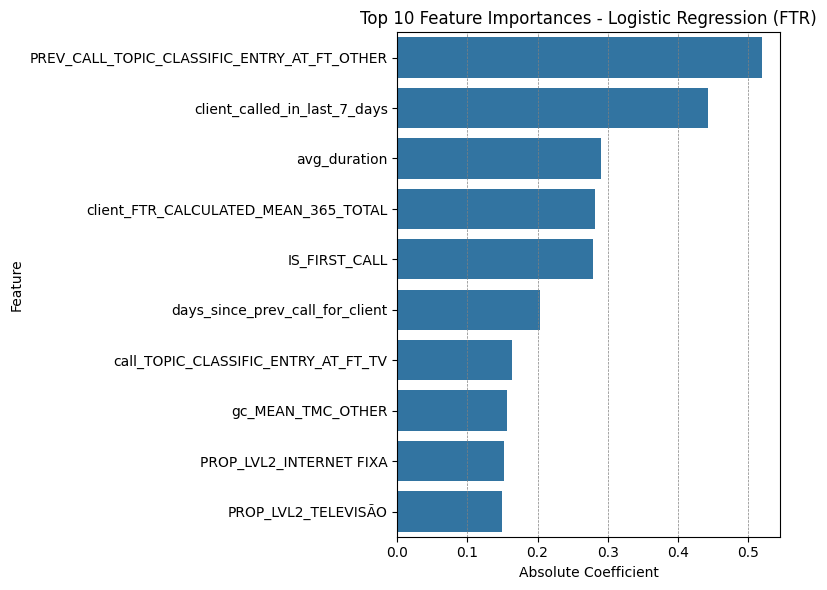

In [56]:
# Feature importance: Logistic Regression coefficients
feature_names = (
    X_train_scaled_ftr.columns
    if hasattr(X_train_scaled_ftr, "columns")
    else [f"Feature {i}" for i in range(X_train_scaled_ftr.shape[1])]
)
coefs = log_ftr.coef_.flatten()

# Create DataFrame of feature importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs,
    "Abs_Coefficient": np.abs(coefs)
})

# Sort by absolute importance
importance_df = importance_df.sort_values(by="Abs_Coefficient", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
ax = plt.gca()  # Grab the current Axes before drawing
sns.barplot(data=importance_df.head(10), x="Abs_Coefficient", y="Feature", ax=ax)

# Add vertical gray dashed gridlines on the x-axis
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)

plt.title("Top 10 Feature Importances - Logistic Regression (FTR)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


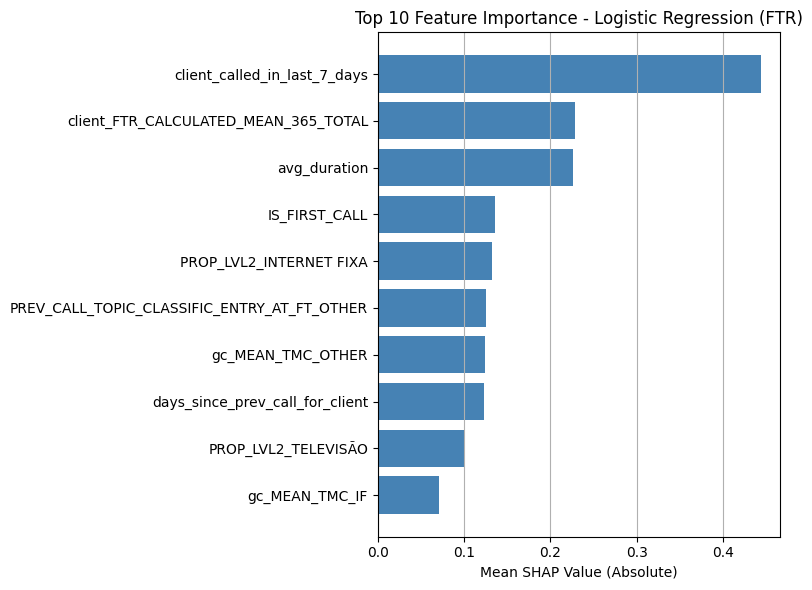

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Generate SHAP values
explainer = shap.Explainer(log_ftr, X_train_scaled_ftr)
shap_values = explainer(X_train_scaled_ftr)

# Calculate mean absolute SHAP values
shap_df = pd.DataFrame({
    'Feature': X_train_scaled_ftr.columns,
    'Mean_Absolute_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})

# Get top 10 features by absolute SHAP values
top10_shap = shap_df.sort_values(by='Mean_Absolute_SHAP', ascending=False).head(10)

# Plot top 10 absolute SHAP values
plt.figure(figsize=(8, 6))
plt.barh(top10_shap['Feature'], top10_shap['Mean_Absolute_SHAP'], color='steelblue')
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - Logistic Regression (FTR)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

### <a id='toc1_4_3_'></a>[FTR: XGBoost Classifier](#toc0_)

In [58]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay, precision_score, recall_score
)
import matplotlib.pyplot as plt
import numpy as np
import shap

# Hyperparameter tuning

# Optional baseline for comparison (you can remove this block if you don’t need a baseline)
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_base.fit(X_train_ftr, y_train_ftr)

# ── Grid Search ──
from sklearn.model_selection import GridSearchCV

base_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid_coarse = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.2],
}

grid_coarse = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid_coarse,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)
grid_coarse.fit(X_train_ftr, y_train_ftr)

print("Coarse best params:", grid_coarse.best_params_)
xgb_ftr = grid_coarse.best_estimator_


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:24:26] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:24:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Coarse best params: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}


ROC AUC: 0.7185


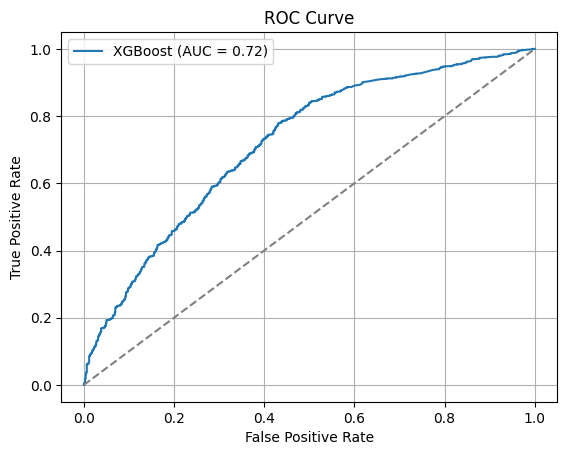

Best Threshold (F1): 0.45
Precision: 0.72, Recall: 0.90, F1: 0.80

Precision (Adjusted Threshold): 0.7175
Recall (Adjusted Threshold): 0.9009
F1 Score (Adjusted Threshold): 0.7988

Classification Report at Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.69      0.38      0.49       759
           1       0.72      0.90      0.80      1322

    accuracy                           0.71      2081
   macro avg       0.70      0.64      0.65      2081
weighted avg       0.71      0.71      0.69      2081



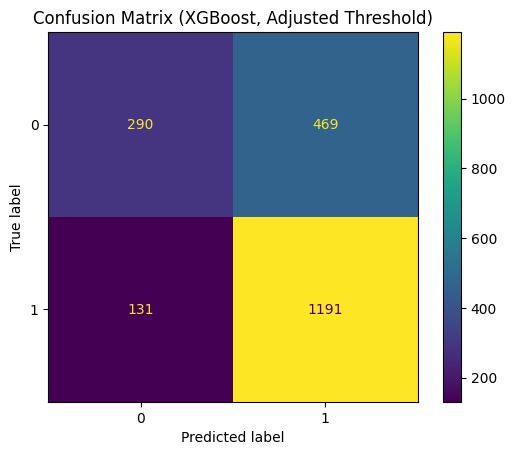

       PRED_PROB_FTR_1  TRUE_FTR
44168         0.756095         1
47421         0.627852         1
33539         0.602749         1
12617         0.829556         1
35991         0.562469         1
37935         0.837534         1
36434         0.674611         1
38228         0.440987         0
38203         0.696423         1
43879         0.698539         1


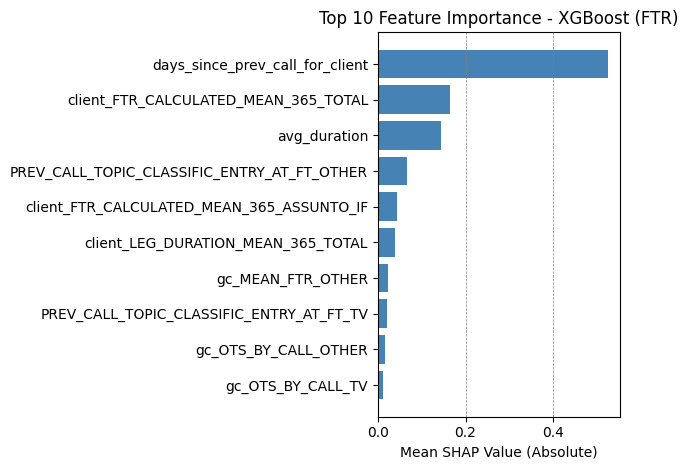


Pairwise Comparison Evaluation:
Pairwise Accuracy: 71.65%


In [89]:
# Evaluation Metrics -----------------------------------------------------------
# Predict probabilities
y_prob_xgb = xgb_ftr.predict_proba(X_test_ftr)[:, 1]

# ROC AUC
roc_auc = roc_auc_score(y_test_ftr, y_prob_xgb)
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_ftr, y_prob_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Find best threshold using F1
precisions, recalls, thresholds = precision_recall_curve(y_test_ftr, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"Best Threshold (F1): {best_thresh:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}, F1: {f1_scores[best_idx]:.2f}")

# Apply threshold
y_pred_thresh = (y_prob_xgb >= best_thresh).astype(int)

# Evaluation
precision = precision_score(y_test_ftr, y_pred_thresh)
recall = recall_score(y_test_ftr, y_pred_thresh)
f1 = f1_score(y_test_ftr, y_pred_thresh)

print(f"\nPrecision (Adjusted Threshold): {precision:.4f}")
print(f"Recall (Adjusted Threshold): {recall:.4f}")
print(f"F1 Score (Adjusted Threshold): {f1:.4f}")

print("\nClassification Report at Adjusted Threshold:")
print(classification_report(y_test_ftr, y_pred_thresh))
ConfusionMatrixDisplay(confusion_matrix(y_test_ftr, y_pred_thresh)).plot()
plt.title("Confusion Matrix (XGBoost, Adjusted Threshold)")
plt.show()

# Show predicted probabilities and actuals
pred_df = X_test_ftr.copy()
pred_df['PRED_PROB_FTR_1'] = y_prob_xgb
pred_df['TRUE_FTR'] = y_test_ftr
print(pred_df[['PRED_PROB_FTR_1', 'TRUE_FTR']].head(10))

## Feature Importance (SHAP)----------------------------------------------------
# Get SHAP values for feature effects
explainer = shap.Explainer(xgb_ftr)
shap_values = explainer(X_train_ftr)

# Mean absolute SHAP values per feature
shap_df = pd.DataFrame({
    'Feature': X_train_ftr.columns,
    'Mean_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})
top10_shap = shap_df.sort_values(by='Mean_SHAP', ascending=False).head(10)

# 9. Plot top 10 feature effects (absolute SHAP values)
plt.figure()
plt.barh(top10_shap['Feature'], top10_shap['Mean_SHAP'], color='steelblue')
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - XGBoost (FTR)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

## Pairwise Comparison ---------------------------------------------------------
# Pairwise comparison evaluation for binary classification
print("\nPairwise Comparison Evaluation:")

# Ensure data types are consistent
y_test_ftr = np.array(y_test_ftr)
y_prob_xgb = np.array(y_prob_xgb)

# Number of pairs to sample
num_samples = 1000000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ftr), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0
valid_pairs = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ftr[i]
    actual_j = y_test_ftr[j]

    # Predicted probabilities
    prob_i = y_prob_xgb[i]
    prob_j = y_prob_xgb[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs += 1
    if (actual_i > actual_j and prob_i > prob_j) or (actual_i < actual_j and prob_i < prob_j):
        correct_predictions += 1

# Calculate pairwise accuracy
if valid_pairs > 0:
    pairwise_accuracy_xgb_ftr = correct_predictions / valid_pairs
    print(f"Pairwise Accuracy: {pairwise_accuracy_xgb_ftr:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

Importance Gain for additional information

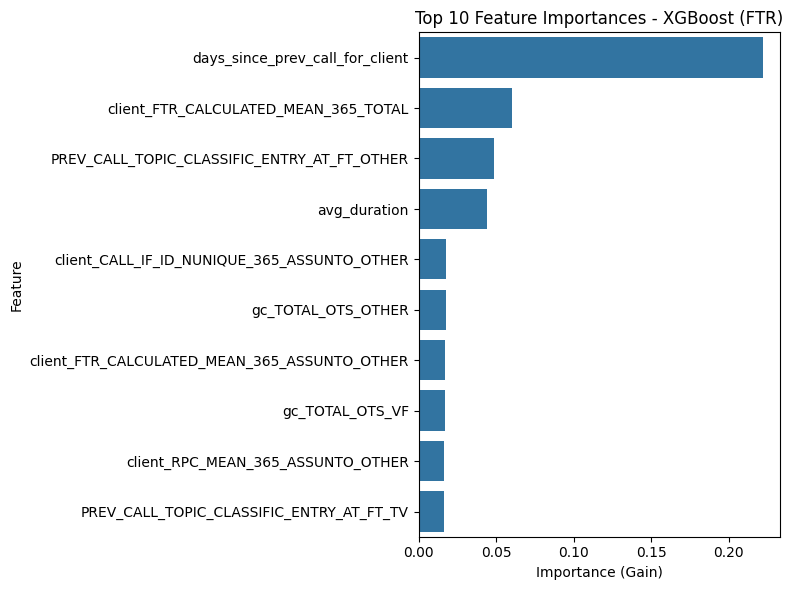

In [ ]:
# Feature importance from XGBoost (gain-based by default)
importances = xgb_ftr.feature_importances_
feature_names = X_train_ftr.columns if hasattr(X_train_ftr, "columns") else [f"Feature {i}" for i in range(X_train_ftr.shape[1])]

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.title("Top 10 Feature Importances - XGBoost (FTR)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### <a id='toc1_4_4_'></a>[FTR: Neural Network](#toc0_)

1.4.3.1. Tuning the model

Trial 10 Complete [00h 00m 59s]
accuracy: 0.7174618244171143

Best accuracy So Far: 0.7380122542381287
Total elapsed time: 00h 10m 46s

--- Building final FTR Classification Model with best hyperparameters ---

--- Training final FTR Classification Model ---
Epoch 1/30
13/13 - 24s - 2s/step - accuracy: 0.6489 - loss: 0.6639 - val_accuracy: 0.5916 - val_loss: 0.6718 - learning_rate: 0.0015
Epoch 2/30
13/13 - 0s - 33ms/step - accuracy: 0.6922 - loss: 0.5953 - val_accuracy: 0.5598 - val_loss: 0.6813 - learning_rate: 0.0015
Epoch 3/30
13/13 - 0s - 36ms/step - accuracy: 0.7105 - loss: 0.5670 - val_accuracy: 0.6276 - val_loss: 0.6628 - learning_rate: 0.0015
Epoch 4/30
13/13 - 0s - 35ms/step - accuracy: 0.7183 - loss: 0.5551 - val_accuracy: 0.6589 - val_loss: 0.6466 - learning_rate: 0.0015
Epoch 5/30
13/13 - 0s - 34ms/step - accuracy: 0.7260 - loss: 0.5448 - val_accuracy: 0.6138 - val_loss: 0.6626 - learning_rate: 0.0015
Epoch 6/30
13/13 - 0s - 35ms/step - accuracy: 0.7360 - loss: 0.5355 - va

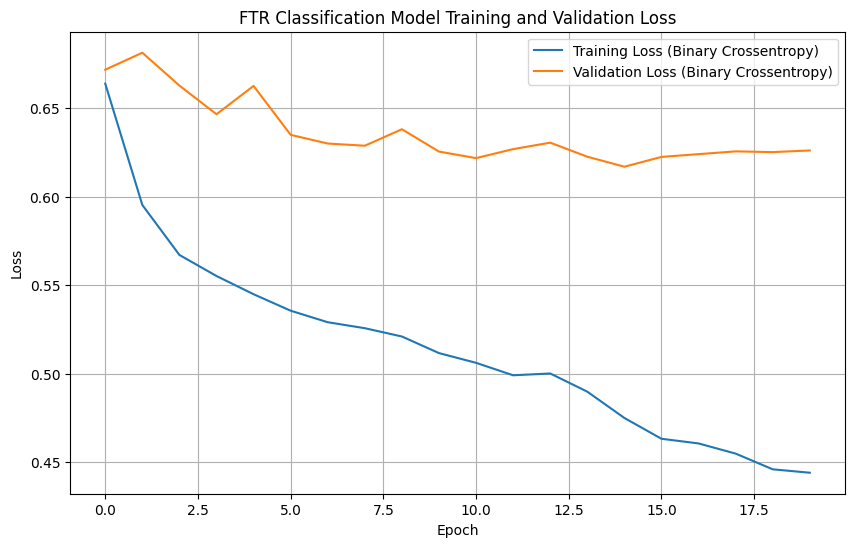

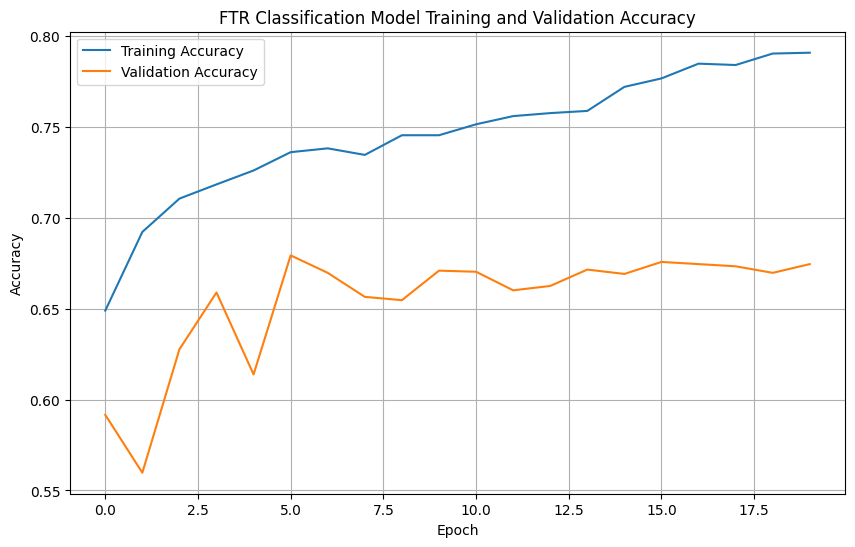

In [61]:
print("--- Tuning FTR Classification Model ---")
tuner_ftr = RandomSearch(
    hypermodel=MyHyperModel(cat_feats, len(num_feats), task='classification'),
    objective='accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_tuning_dir',
    project_name='ftr_tuning'
)

tuner_ftr.search(
    inp_tr, y_ftr_train,
    epochs=30,
    validation_data=(inp_te, y_ftr_test),
    callbacks=[early, lr_cb]
)

best_hps_ftr = tuner_ftr.get_best_hyperparameters(num_trials=1)[0]
print("\n--- Building final FTR Classification Model with best hyperparameters ---")
ftr_model = build_tabular_nn(best_hps_ftr, cat_feats, len(num_feats), task='classification')

# Train the final model and store history
print("\n--- Training final FTR Classification Model ---")
history_ftr = ftr_model.fit(
    inp_tr, y_ftr_train,
    validation_split=0.2,
    epochs=30,
    batch_size=512,
    callbacks=[early, lr_cb],
    verbose=2
)

# Plot training and validation loss for FTR model
plt.figure(figsize=(10, 6))
plt.plot(history_ftr.history['loss'], label='Training Loss (Binary Crossentropy)')
plt.plot(history_ftr.history['val_loss'], label='Validation Loss (Binary Crossentropy)')
plt.title('FTR Classification Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation accuracy for FTR model
plt.figure(figsize=(10, 6))
plt.plot(history_ftr.history['accuracy'], label='Training Accuracy')
plt.plot(history_ftr.history['val_accuracy'], label='Validation Accuracy')
plt.title('FTR Classification Model Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

1.4.3.2. Evaluation

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step
First-Time Resolution — best threshold (F1 max) = 0.407, F1 = 0.786

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.19      0.29       760
           1       0.67      0.95      0.79      1321

    accuracy                           0.67      2081
   macro avg       0.68      0.57      0.54      2081
weighted avg       0.67      0.67      0.61      2081

Confusion Matrix:
[[ 142  618]
 [  66 1255]]


First-Time Resolution — AUC = 0.680


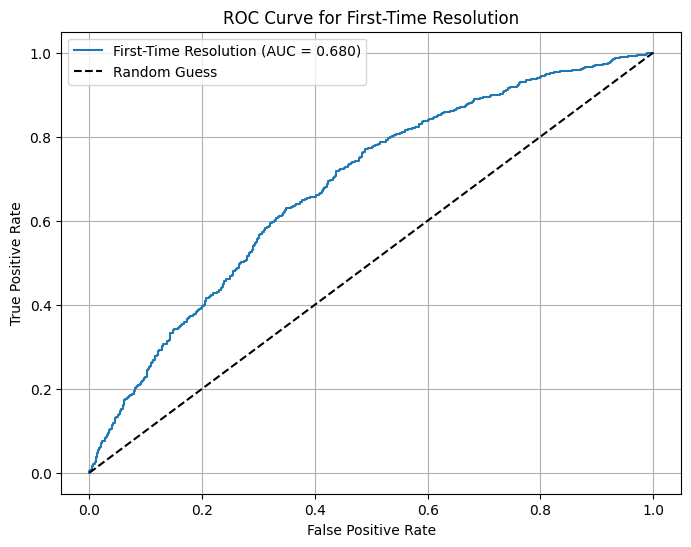



66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Pairwise Accuracy (FTR Classification): 31.68%


In [62]:
# Evaluation ------------------------------------------------------------------------------
y_ftr_prob = ftr_model.predict(inp_te).flatten()

def plot_pr_and_confmat_and_roc(y_true, y_prob, name):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thr = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    print(f"{name} — best threshold (F1 max) = {best_thr:.3f}, F1 = {best_f1:.3f}\n")
    y_pred = (y_prob >= best_thr).astype(int)
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\n" + "="*60 + "\n")

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = roc_auc_score(y_true, y_prob)
    print(f"{name} — AUC = {auc_score:.3f}")

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve for {name}')
    plt.legend()
    plt.grid(True)
    plt.show()
    print("\n" + "="*60 + "\n")

plot_pr_and_confmat_and_roc(y_ftr_test, y_ftr_prob, name='First-Time Resolution')

# Pairwise Accuracy -------------------------------------------------------------
# Use the predicted probabilities for comparison
y_ftr_prob_test = ftr_model.predict(inp_te).flatten()

# Number of pairs to sample (adjust if needed)
num_samples_ftr = 100000

# Randomly sample pairs of indices from the test set
indices_ftr = np.random.choice(len(y_ftr_test), size=(num_samples_ftr, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions_ftr = 0

# Perform pairwise comparisons
for i, j in indices_ftr:
    # Actual values
    actual_i = y_ftr_test[i]
    actual_j = y_ftr_test[j]

    # Predicted probabilities
    pred_i = y_ftr_prob_test[i]
    pred_j = y_ftr_prob_test[j]

    # Compare actual and predicted rankings based on probabilities, ignoring ties
    if (actual_i > actual_j and pred_i > pred_j) or \
       (actual_i < actual_j and pred_i < pred_j):
        correct_predictions_ftr += 1

# Calculate pairwise accuracy
pairwise_accuracy_ftr = correct_predictions_ftr / num_samples_ftr
print(f"Pairwise Accuracy (FTR Classification): {pairwise_accuracy_ftr:.2%}")

1.4.3.3. SHAP

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
686/686 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
682/682 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
682/682 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
685/

<ipython-input-49-819a4e95fae9>:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


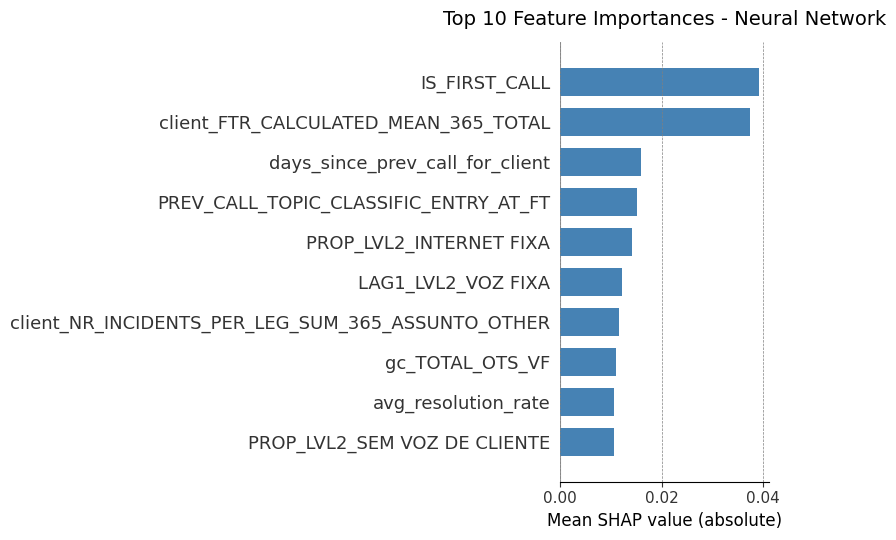

In [ ]:
shap_ftr, X_ftr_plot_sample = get_shap_values(ftr_model, X_train, X_test, cat_feats, num_feats, scaler, input_columns, clean_name)
plot_shap_summary(shap_ftr, X_ftr_plot_sample, "Neural Network", "FTR")
plt.show()

### <a id='toc1_4_5_'></a>[FTR Model Comparison](#toc0_)

XGBoost Best Threshold (F1): 0.45
Precision: 0.72, Recall: 0.90, F1: 0.80


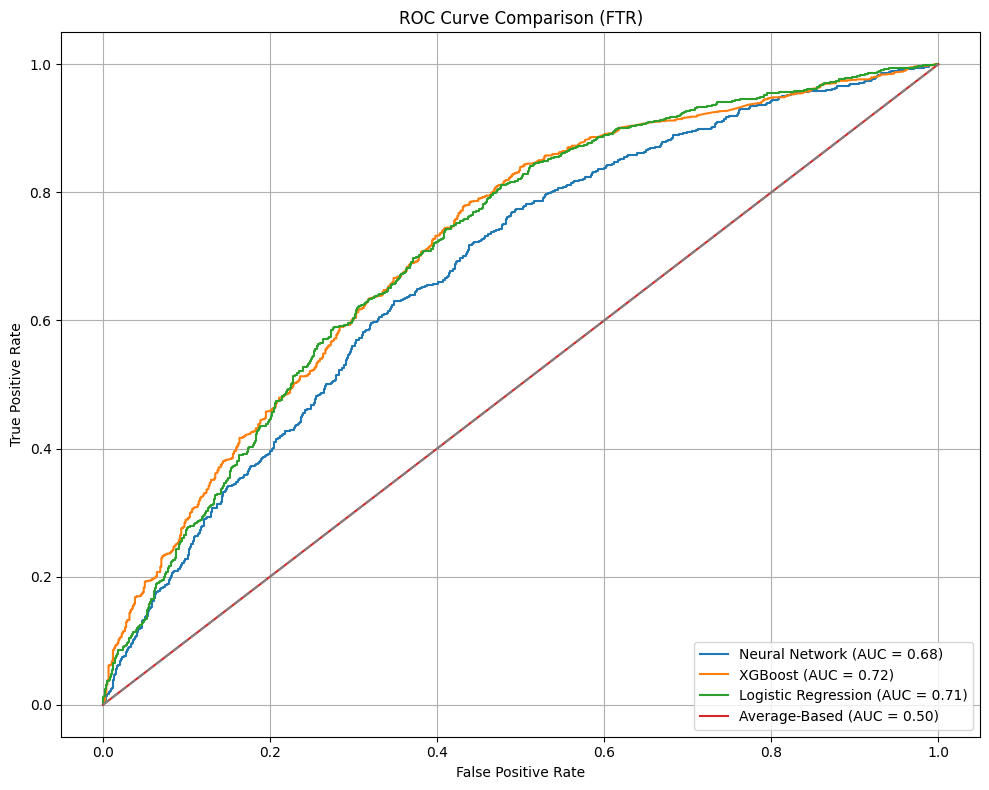


Pairwise Comparison Evaluation:
Neural Network Pairwise Accuracy: 31.68%
XGBoost Pairwise Accuracy: 71.58%
Logistic Regression Pairwise Accuracy: 71.45%
Average-Based Pairwise Accuracy: 0.00%


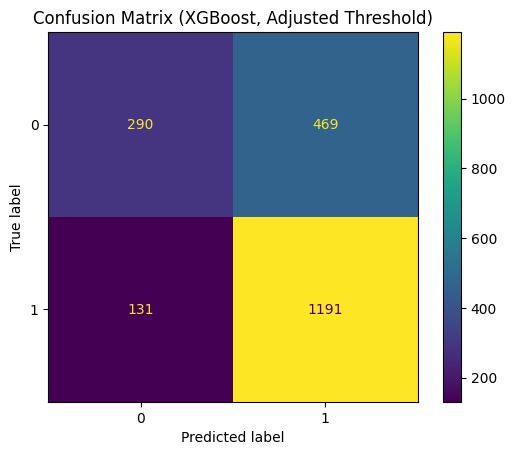

In [ ]:
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

# === Compute Optimal Threshold for XGBoost ===
precisions, recalls, thresholds = precision_recall_curve(y_test_ftr, y_prob_xgb)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)  # Avoid division by zero
best_idx = np.argmax(f1_scores)
best_thresh_xgb = thresholds[best_idx]

print(f"XGBoost Best Threshold (F1): {best_thresh_xgb:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}, F1: {f1_scores[best_idx]:.2f}")

# === Compute ROC and AUC for all models ===
# Neural Netwirk
fpr_nn, tpr_nn, _ = roc_curve(y_ftr_test, y_ftr_prob)
auc_nn = roc_auc_score(y_ftr_test, y_ftr_prob)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_ftr, y_prob_xgb)
auc_xgb = roc_auc_score(y_test_ftr, y_prob_xgb)

# Logistic Regression
fpr_logreg, tpr_logreg, _ = roc_curve(y_test_ftr, y_prob_ftr)
auc_logreg = roc_auc_score(y_test_ftr, y_prob_ftr)

# Average-Based Prediction (Baseline)
y_prob_avg = np.full_like(y_test_ftr, fill_value=np.mean(y_test_ftr), dtype=float)
fpr_avg, tpr_avg, _ = roc_curve(y_test_ftr, y_prob_avg)
auc_avg = roc_auc_score(y_test_ftr, y_prob_avg)

# === Plot ROC Curves ===
plt.figure(figsize=(10, 8))
plt.plot(fpr_nn, tpr_nn, label=f"Neural Network (AUC = {auc_nn:.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc_logreg:.2f})")
plt.plot(fpr_avg, tpr_avg, label=f"Average-Based (AUC = {auc_avg:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (FTR)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Pairwise Comparison Evaluation ===
print("\nPairwise Comparison Evaluation:")

# Number of pairs to sample
num_samples = 100000  # Adjust based on memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ftr), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions_xgb = 0
correct_predictions_logreg = 0
correct_predictions_avg = 0
valid_pairs = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ftr[i]
    actual_j = y_test_ftr[j]

    # Predicted probabilities
    prob_xgb_i, prob_xgb_j = y_prob_xgb[i], y_prob_xgb[j]
    prob_logreg_i, prob_logreg_j = y_prob_ftr[i], y_prob_ftr[j]
    prob_avg_i, prob_avg_j = y_prob_avg[i], y_prob_avg[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs += 1
    if (actual_i > actual_j and prob_xgb_i > prob_xgb_j) or (actual_i < actual_j and prob_xgb_i < prob_xgb_j):
        correct_predictions_xgb += 1
    if (actual_i > actual_j and prob_logreg_i > prob_logreg_j) or (actual_i < actual_j and prob_logreg_i < prob_logreg_j):
        correct_predictions_logreg += 1
    if (actual_i > actual_j and prob_avg_i > prob_avg_j) or (actual_i < actual_j and prob_avg_i < prob_avg_j):
        correct_predictions_avg += 1

# Calculate pairwise accuracy
if valid_pairs > 0:
    pairwise_accuracy_nn = pairwise_accuracy_ftr
    pairwise_accuracy_xgb = correct_predictions_xgb / valid_pairs
    pairwise_accuracy_logreg = correct_predictions_logreg / valid_pairs
    pairwise_accuracy_avg = correct_predictions_avg / valid_pairs
    print(f"Neural Network Pairwise Accuracy: {pairwise_accuracy_nn:.2%}")
    print(f"XGBoost Pairwise Accuracy: {pairwise_accuracy_xgb:.2%}")
    print(f"Logistic Regression Pairwise Accuracy: {pairwise_accuracy_logreg:.2%}")
    print(f"Average-Based Pairwise Accuracy: {pairwise_accuracy_avg:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

# === Confusion Matrix for XGBoost with Optimal Threshold ===
# Generate binary predictions using the optimal threshold
y_pred_xgb_thresh = (y_prob_xgb >= best_thresh_xgb).astype(int)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test_ftr, y_pred_xgb_thresh)
ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("Confusion Matrix (XGBoost, Adjusted Threshold)")
plt.show()

## <a id='toc1_5_'></a>[Classification Models to predict OT](#toc0_)

### <a id='toc1_5_1_'></a>[OT: Rule-Based (Average per Cat)](#toc0_)

ROC AUC (OT): 0.6229


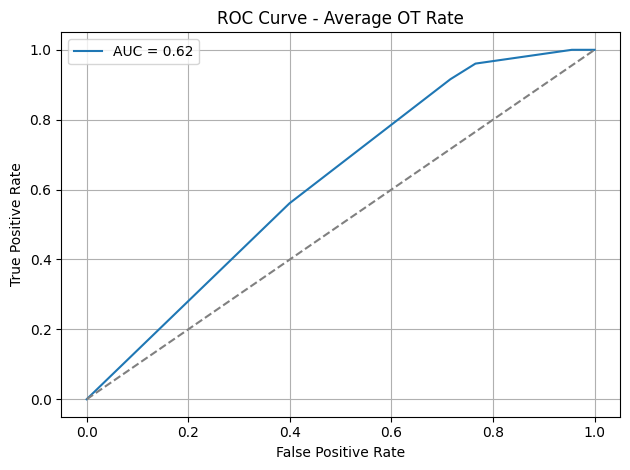

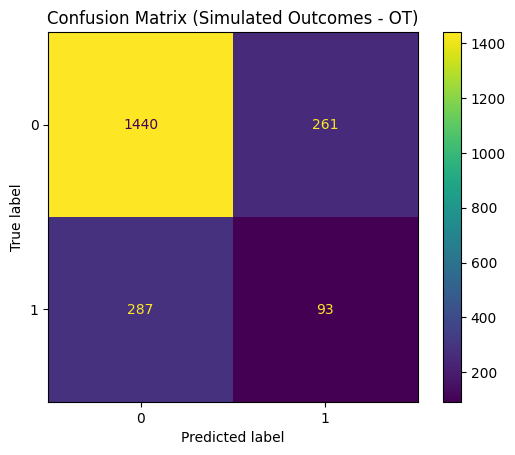

Precision (OT): 0.2627
Recall (OT): 0.2447
F1 Score (OT): 0.2534

Pairwise Comparison Evaluation (OT):
Valid Pairs (OT): 29730
Correct Predictions (OT): 13477
Pairwise Accuracy (OT): 45.33%


In [ ]:
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
import matplotlib.pyplot as plt
import numpy as np

# Retrieve avg_ot_rate from the original dataset
avg_ot_rate = final_df.loc[X_test_ot.index, 'avg_ot_rate']

# Ensure y_test_ot is aligned and remains a NumPy array
if isinstance(y_test_ot, np.ndarray):
    y_test_ot = y_test_ot  # Already a NumPy array, no need to reset index
else:
    y_test_ot = pd.Series(y_test_ot).reset_index(drop=True).values  # Convert to Series, reset index, and back to NumPy array

# Reset indices for avg_ot_rate
y_prob_avg_ot = avg_ot_rate.reset_index(drop=True).values  # Reset index for probabilities

# === ROC AUC ===
roc_auc_ot = roc_auc_score(y_test_ot, y_prob_avg_ot)
print(f"ROC AUC (OT): {roc_auc_ot:.4f}")

# === ROC Curve ===
fpr_ot, tpr_ot, _ = roc_curve(y_test_ot, y_prob_avg_ot)
plt.figure()
plt.plot(fpr_ot, tpr_ot, label=f"AUC = {roc_auc_ot:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC Curve - Average OT Rate")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Confusion Matrix ===
# Generate binary predictions based on probabilities
# Use a probabilistic approach: simulate outcomes based on probabilities
np.random.seed(42)  # For reproducibility
y_pred_simulated_ot = np.random.binomial(1, y_prob_avg_ot)

# Generate the confusion matrix
cm_ot = confusion_matrix(y_test_ot, y_pred_simulated_ot)
ConfusionMatrixDisplay(cm_ot).plot()
plt.title("Confusion Matrix (Simulated Outcomes - OT)")
plt.show()

# === Precision, Recall, and F1 Score ===
precision_ot = precision_score(y_test_ot, y_pred_simulated_ot)
recall_ot = recall_score(y_test_ot, y_pred_simulated_ot)
f1_ot = f1_score(y_test_ot, y_pred_simulated_ot)

print(f"Precision (OT): {precision_ot:.4f}")
print(f"Recall (OT): {recall_ot:.4f}")
print(f"F1 Score (OT): {f1_ot:.4f}")

# === Pairwise Comparison Evaluation ===
print("\nPairwise Comparison Evaluation (OT):")

# Number of pairs to sample
num_samples = 100000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ot), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions_ot = 0
valid_pairs_ot = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ot[i]
    actual_j = y_test_ot[j]

    # Predicted probabilities
    prob_i = y_prob_avg_ot[i]
    prob_j = y_prob_avg_ot[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs_ot += 1
    if (actual_i > actual_j and prob_i > prob_j) or (actual_i < actual_j and prob_i < prob_j):
        correct_predictions_ot += 1

print(f"Valid Pairs (OT): {valid_pairs_ot}")
print(f"Correct Predictions (OT): {correct_predictions_ot}")

# Calculate pairwise accuracy
if valid_pairs_ot > 0:
    pairwise_accuracy_avg_ot = correct_predictions_ot / valid_pairs_ot
    print(f"Pairwise Accuracy (OT): {pairwise_accuracy_avg_ot:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

### <a id='toc1_5_2_'></a>[OT: Logistic Regression](#toc0_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Parameters: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
ROC AUC: 0.6392


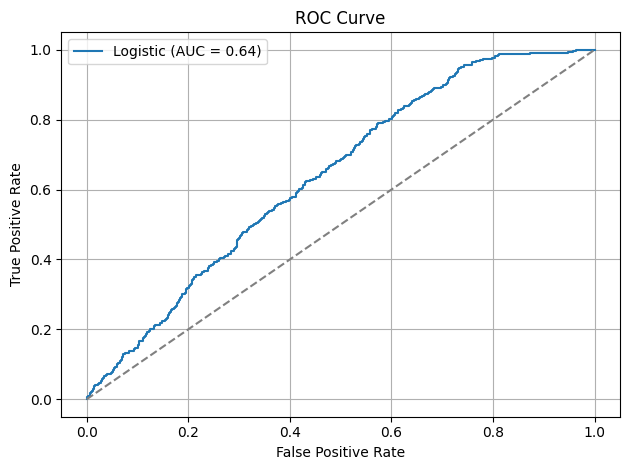

Best Threshold (F1): 0.18
Precision: 0.24, Recall: 0.79, F1: 0.36

Precision (Adjusted Threshold): 0.2355
Recall    (Adjusted Threshold): 0.7895
F1 Score  (Adjusted Threshold): 0.3628
Classification Report at Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.90      0.43      0.58      1701
           1       0.24      0.79      0.36       380

    accuracy                           0.49      2081
   macro avg       0.57      0.61      0.47      2081
weighted avg       0.78      0.49      0.54      2081



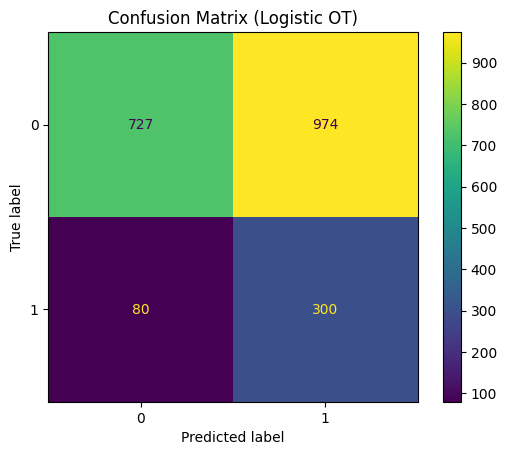

       PRED_PROB_OT_1  TRUE_OT
24014        0.202618        0
32250        0.209319        0
50680        0.229262        0
29176        0.202448        0
49699        0.226668        0
49240        0.222168        1
36688        0.170756        0
28305        0.293967        0
47019        0.195181        0
27000        0.250041        0

Pairwise Comparison Evaluation:
Pairwise Accuracy: 63.94%


In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import numpy as np
import shap

# === Hyperparameter tuning via Grid Search ===
param_grid = {
    'C':       [0.01, 0.1, 1, 10],  # inverse regularization strength
    'penalty': ['l1', 'l2'],       # now testing both L1 and L2
    'solver':  ['liblinear']       # liblinear supports both L1 and L2
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# fit all candidates and select the best
grid_search.fit(X_train_scaled_ot, y_train_ot)
log_ot = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# === Predict probabilities on the scaled test set ===
y_prob_log = log_ot.predict_proba(X_test_scaled_ot)[:, 1]

# === ROC AUC ===
roc_auc = roc_auc_score(y_test_ot, y_prob_log)
print(f"ROC AUC: {roc_auc:.4f}")

# === ROC Curve ===
fpr, tpr, _ = roc_curve(y_test_ot, y_prob_log)
plt.plot(fpr, tpr, label=f'Logistic (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === Optimal threshold by F1 ===
precisions, recalls, thresholds = precision_recall_curve(y_test_ot, y_prob_log)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
print(f"Best Threshold (F1): {best_thresh:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}, F1: {f1s[best_idx]:.2f}")

# === Predictions at adjusted threshold ===
y_pred = (y_prob_log >= best_thresh).astype(int)

# === Precision, Recall, F1 at adjusted threshold ===
precision = precision_score(y_test_ot, y_pred)
recall    = recall_score(y_test_ot, y_pred)
f1        = f1_score(y_test_ot, y_pred)
print(f"\nPrecision (Adjusted Threshold): {precision:.4f}")
print(f"Recall    (Adjusted Threshold): {recall:.4f}")
print(f"F1 Score  (Adjusted Threshold): {f1:.4f}")

# === Classification Report & Confusion Matrix ===
print("Classification Report at Adjusted Threshold:")
print(classification_report(y_test_ot, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test_ot, y_pred)).plot()
plt.title("Confusion Matrix (Logistic OT)")
plt.show()

# === Probability table ===
pred_df = X_test_scaled_ot.copy()
pred_df["PRED_PROB_OT_1"] = y_prob_log
pred_df["TRUE_OT"]        = y_test_ot
print(pred_df[["PRED_PROB_OT_1", "TRUE_OT"]].head(10))

# === Pairwise Comparison Evaluation ===
print("\nPairwise Comparison Evaluation:")
y_test_arr = np.array(y_test_ot)
y_prob_arr = np.array(y_prob_log)

num_samples = 1_000_000
indices     = np.random.choice(len(y_test_arr), size=(num_samples, 2), replace=True)

correct, valid = 0, 0
for i, j in indices:
    ai, aj = y_test_arr[i], y_test_arr[j]
    if ai == aj:
        continue
    valid += 1
    pi, pj = y_prob_arr[i], y_prob_arr[j]
    if (ai > aj and pi > pj) or (ai < aj and pi < pj):
        correct += 1

if valid > 0:
    print(f"Pairwise Accuracy: {correct/valid:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

Feature Importance: absolute coefficients

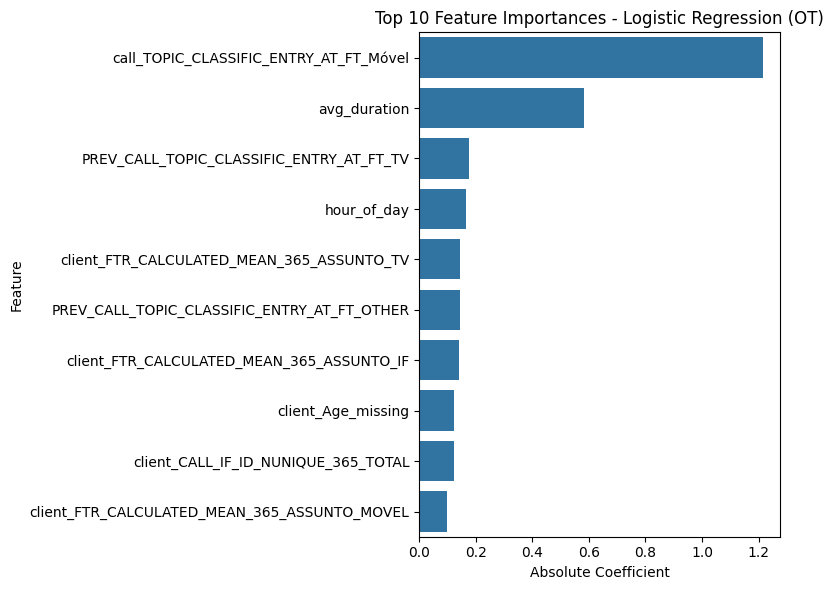

In [82]:
# Feature importance based on Logistic Regression coefficients
feature_names = X_train_scaled_ot.columns if hasattr(X_train_scaled_ot, "columns") else [f"Feature {i}" for i in range(X_train_scaled_ot.shape[1])]
coefs = log_ot.coef_.flatten()

# Create DataFrame of feature importances
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefs,
    "Abs_Coefficient": np.abs(coefs)
}).sort_values(by="Abs_Coefficient", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Abs_Coefficient", y="Feature")
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.title("Top 10 Feature Importances - Logistic Regression (OT)")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Feature Importance: SHAP values

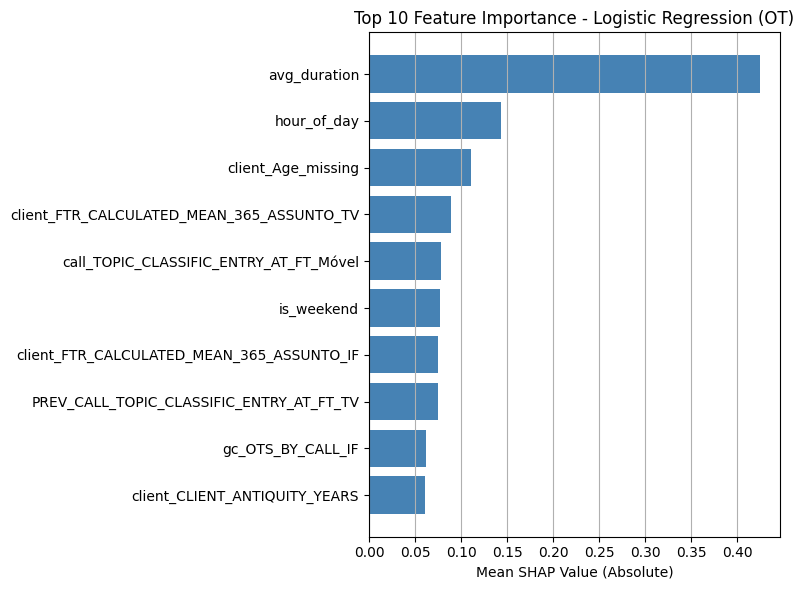

In [ ]:
# Generate SHAP values
explainer = shap.Explainer(log_ot, X_train_scaled_ot)
shap_values = explainer(X_train_scaled_ot)

# Calculate mean absolute SHAP values
shap_df = pd.DataFrame({
    'Feature': X_train_scaled_ot.columns,
    'Mean_Absolute_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})

# Get top 10 features by absolute SHAP values
top10_shap = shap_df.sort_values(by='Mean_Absolute_SHAP', ascending=False).head(10)

# Plot top 10 absolute SHAP values
plt.figure(figsize=(8, 6))
plt.barh(top10_shap['Feature'], top10_shap['Mean_Absolute_SHAP'], color='steelblue')
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - Logistic Regression (OT)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

### <a id='toc1_5_3_'></a>[OT: XGBoost Classifier](#toc0_)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:42:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
ROC AUC: 0.6515


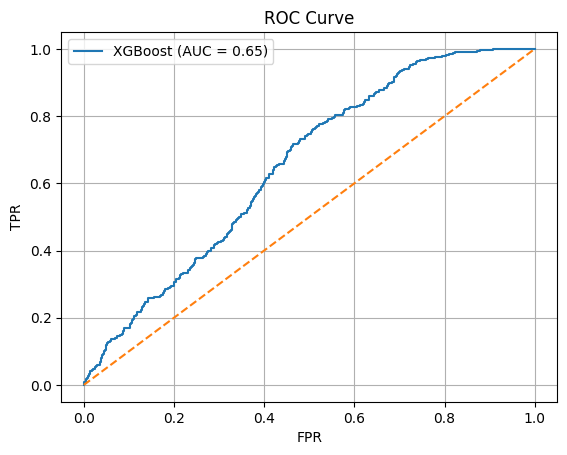

Best Threshold (F1): 0.19
Precision: 0.25, Recall: 0.73, F1: 0.38

Precision (Adjusted Threshold): 0.2546
Recall    (Adjusted Threshold): 0.7316
F1 Score  (Adjusted Threshold): 0.3777
Classification Report at Adjusted Threshold:
              precision    recall  f1-score   support

           0       0.90      0.52      0.66      1701
           1       0.25      0.73      0.38       380

    accuracy                           0.56      2081
   macro avg       0.58      0.63      0.52      2081
weighted avg       0.78      0.56      0.61      2081



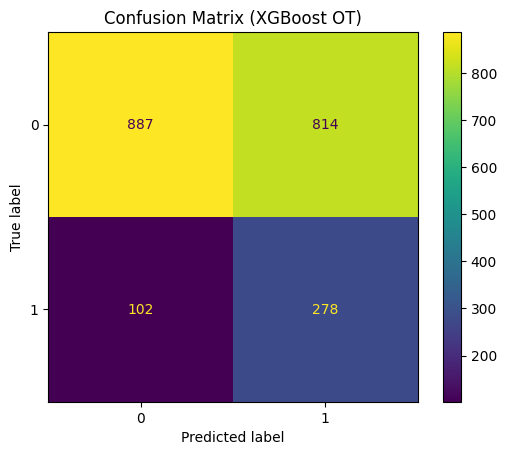

       PRED_PROB_OT_1  TRUE_OT
24014        0.200915        0
32250        0.167424        0
50680        0.269787        0
29176        0.213948        0
49699        0.273953        0
49240        0.243188        1
36688        0.183022        0
28305        0.397613        0
47019        0.240385        0
27000        0.263745        0


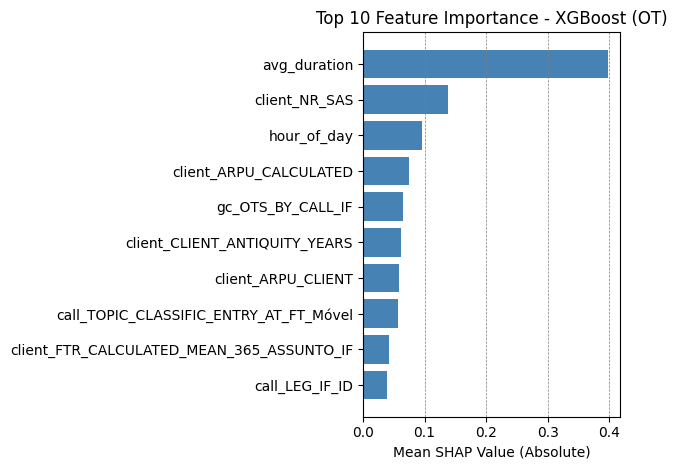


Pairwise Comparison Evaluation:
Pairwise Accuracy: 65.18%


In [115]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score
)
import matplotlib.pyplot as plt
import numpy as np
import shap

# === Hyperparameter tuning: Grid Search ===
param_grid = {
    "n_estimators":  [50, 100, 200],
    "max_depth":     [4, 6, 8],
    "learning_rate": [0.01, 0.1, 0.2],
}

grid_search = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42),
    param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

# fit all candidates and select the best
grid_search.fit(X_train_ot, y_train_ot)
xgb_ot = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

## Evaluation ------------------------------------------------------------------
# === Predict probabilities ===
y_prob_xgb = xgb_ot.predict_proba(X_test_ot)[:, 1]

# ROC AUC
roc_auc = roc_auc_score(y_test_ot, y_prob_xgb)
print(f"ROC AUC: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test_ot, y_prob_xgb)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test_ot, y_prob_xgb)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1s)
best_thresh = thresholds[best_idx]
print(f"Best Threshold (F1): {best_thresh:.2f}")
print(f"Precision: {precisions[best_idx]:.2f}, Recall: {recalls[best_idx]:.2f}, F1: {f1s[best_idx]:.2f}")

# Predictions
y_pred = (y_prob_xgb >= best_thresh).astype(int)

# Precision, Recall, and F1 Score at the adjusted threshold
precision = precision_score(y_test_ot, y_pred)
recall    = recall_score(y_test_ot, y_pred)
f1        = f1_score(y_test_ot, y_pred)
print(f"\nPrecision (Adjusted Threshold): {precision:.4f}")
print(f"Recall    (Adjusted Threshold): {recall:.4f}")
print(f"F1 Score  (Adjusted Threshold): {f1:.4f}")

# Classification Report and Confusion Matrix
print("Classification Report at Adjusted Threshold:")
print(classification_report(y_test_ot, y_pred))
ConfusionMatrixDisplay(confusion_matrix(y_test_ot, y_pred)).plot()
plt.title("Confusion Matrix (XGBoost OT)")
plt.show()

# Table
pred_df = X_test_ot.copy()
pred_df["PRED_PROB_OT_1"] = y_prob_xgb
pred_df["TRUE_OT"]        = y_test_ot
print(pred_df[["PRED_PROB_OT_1", "TRUE_OT"]].head(10))

## Feature Importance (SHAP)----------------------------------------------------
# Get SHAP values for feature effects
explainer = shap.Explainer(xgb_ot)
shap_values = explainer(X_train_ot)

# Mean absolute SHAP values per feature
shap_df = pd.DataFrame({
    'Feature': X_train_ot.columns,
    'Mean_SHAP': np.mean(np.abs(shap_values.values), axis=0)
})
top10_shap = shap_df.sort_values(by='Mean_SHAP', ascending=False).head(10)

# Plot top 10 feature effects (absolute SHAP values)
plt.figure()
plt.barh(top10_shap['Feature'], top10_shap['Mean_SHAP'], color='steelblue')
plt.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.xlabel("Mean SHAP Value (Absolute)")
plt.title("Top 10 Feature Importance - XGBoost (OT)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, axis='x')
plt.show()

## Pairwise Comparison----------------------------------------------------------
# Pairwise comparison evaluation for binary classification
print("\nPairwise Comparison Evaluation:")

# Ensure data types are consistent
y_test_ot   = np.array(y_test_ot)
y_prob_xgb  = np.array(y_prob_xgb)

# Number of pairs to sample
num_samples = 1000000  # Adjust this based on your system's memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ot), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions = 0
valid_pairs         = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ot[i]
    actual_j = y_test_ot[j]

    # Predicted probabilities
    prob_i = y_prob_xgb[i]
    prob_j = y_prob_xgb[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs += 1
    if (actual_i > actual_j and prob_i > prob_j) or (actual_i < actual_j and prob_i < prob_j):
        correct_predictions += 1

# Calculate pairwise accuracy
if valid_pairs > 0:
    pairwise_accuracy_xgb_ot = correct_predictions / valid_pairs
    print(f"Pairwise Accuracy: {pairwise_accuracy_xgb_ot:.2%}")
else:
    print("No valid pairs for pairwise comparison.")



Feature Importance: Information Gain

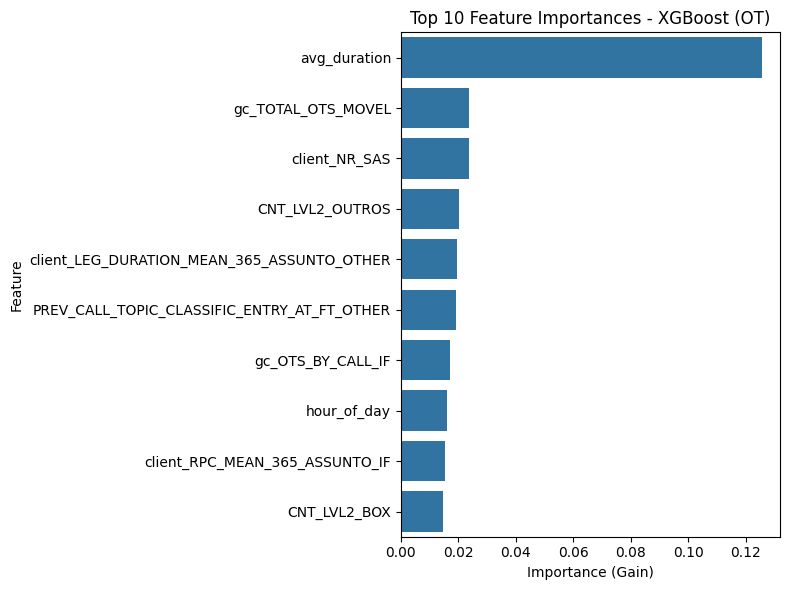

In [ ]:
# XGBoost feature importances (default: gain-based)
feature_names = X_train_ot.columns if hasattr(X_train_ot, "columns") else [f"Feature {i}" for i in range(X_train_ot.shape[1])]
importances = xgb_ot.feature_importances_

# Create DataFrame
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot top 10 features
plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(10), x="Importance", y="Feature")
ax.grid(axis='x', color='gray', linestyle='--', linewidth=0.5)
plt.title("Top 10 Feature Importances - XGBoost (OT)")
plt.xlabel("Importance (Gain)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### <a id='toc1_5_4_'></a>[OT: Neural Network](#toc0_)

1.5.3.1 Hyperparameter tuning

Trial 10 Complete [00h 00m 57s]
accuracy: 0.8166086077690125

Best accuracy So Far: 0.8224973082542419
Total elapsed time: 00h 10m 25s

--- Building final OT Classification Model with best hyperparameters ---

--- Training final OT Classification Model ---
Epoch 1/30
13/13 - 27s - 2s/step - accuracy: 0.6230 - loss: 0.6699 - val_accuracy: 0.8162 - val_loss: 0.5940 - learning_rate: 0.0017
Epoch 2/30
13/13 - 0s - 38ms/step - accuracy: 0.8093 - loss: 0.4675 - val_accuracy: 0.8072 - val_loss: 0.5616 - learning_rate: 0.0017
Epoch 3/30
13/13 - 1s - 39ms/step - accuracy: 0.8086 - loss: 0.4481 - val_accuracy: 0.8156 - val_loss: 0.5402 - learning_rate: 0.0017
Epoch 4/30
13/13 - 1s - 39ms/step - accuracy: 0.8120 - loss: 0.4337 - val_accuracy: 0.8126 - val_loss: 0.5320 - learning_rate: 0.0017
Epoch 5/30
13/13 - 1s - 41ms/step - accuracy: 0.8123 - loss: 0.4244 - val_accuracy: 0.8108 - val_loss: 0.5165 - learning_rate: 0.0017
Epoch 6/30
13/13 - 1s - 39ms/step - accuracy: 0.8164 - loss: 0.4111 - val_

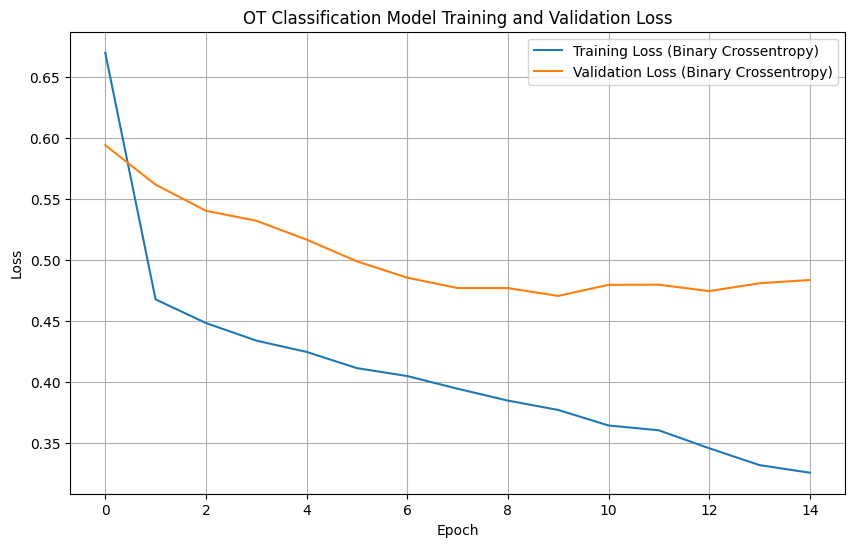

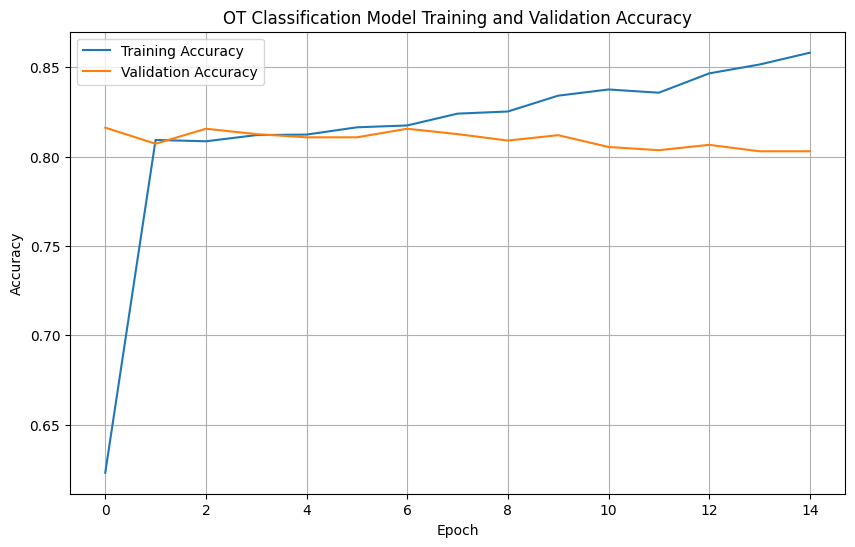

In [91]:
print("--- Tuning OT Classification Model ---")
tuner_ot = RandomSearch(
    hypermodel=MyHyperModel(cat_feats, len(num_feats), task='classification'),
    objective='accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory='my_tuning_dir',
    project_name='ot_tuning'
)

tuner_ot.search(
    inp_tr, y_ot_train,
    epochs=30,
    validation_data=(inp_te, y_ot_test),
    callbacks=[early, lr_cb]
)

best_hps_ot = tuner_ot.get_best_hyperparameters(num_trials=1)[0]
print("\n--- Building final OT Classification Model with best hyperparameters ---")
ot_model = build_tabular_nn(best_hps_ot, cat_feats, len(num_feats), task='classification')

# Train the final model and store history
print("\n--- Training final OT Classification Model ---")
history_ot = ot_model.fit(
    inp_tr, y_ot_train,
    validation_split=0.2,
    epochs=30,
    batch_size=512,
    callbacks=[early, lr_cb],
    verbose=2
)

# Plot training and validation loss for OT model
plt.figure(figsize=(10, 6))
plt.plot(history_ot.history['loss'], label='Training Loss (Binary Crossentropy)')
plt.plot(history_ot.history['val_loss'], label='Validation Loss (Binary Crossentropy)')
plt.title('OT Classification Model Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot training and validation accuracy for OT model
plt.figure(figsize=(10, 6))
plt.plot(history_ot.history['accuracy'], label='Training Accuracy')
plt.plot(history_ot.history['val_accuracy'], label='Validation Accuracy')
plt.title('OT Classification Model Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

1.5.3.2. Evaluation

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step
OT Needed — best threshold (F1 max) = 0.148, F1 = 0.335

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.29      0.44      1732
           1       0.21      0.91      0.33       349

    accuracy                           0.39      2081
   macro avg       0.57      0.60      0.39      2081
weighted avg       0.82      0.39      0.43      2081

Confusion Matrix:
[[ 504 1228]
 [  32  317]]


OT Needed — AUC = 0.631


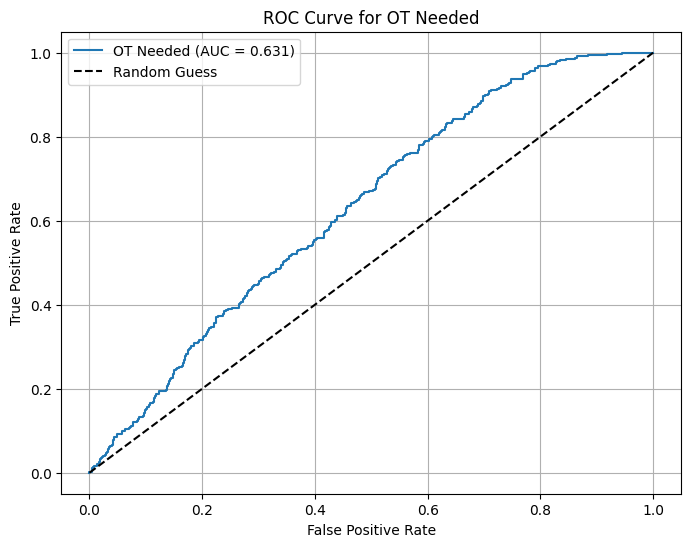



66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Pairwise Accuracy (OT Classification): 17.91%


In [92]:
# Evaluation --------------------------------------------------------------------
y_ot_prob  = ot_model.predict(inp_te).flatten()
plot_pr_and_confmat_and_roc(y_ot_test,  y_ot_prob,  name='OT Needed')


# Pairwise Accuracy -------------------------------------------------------------
y_ot_prob_test = ot_model.predict(inp_te).flatten()

# Number of pairs to sample (adjust if needed)
num_samples_ot = 100000

# Randomly sample pairs of indices from the test set
indices_ot = np.random.choice(len(y_ot_test), size=(num_samples_ot, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions_ot = 0

# Perform pairwise comparisons
for i, j in indices_ot:
    # Actual values
    actual_i = y_ot_test[i]
    actual_j = y_ot_test[j]

    # Predicted probabilities
    pred_i = y_ot_prob_test[i]
    pred_j = y_ot_prob_test[j]

    # Compare actual and predicted rankings based on probabilities, ignoring ties
    if (actual_i > actual_j and pred_i > pred_j) or \
       (actual_i < actual_j and pred_i < pred_j):
        correct_predictions_ot += 1

# Calculate pairwise accuracy
pairwise_accuracy_ot = correct_predictions_ot / num_samples_ot
print(f"Pairwise Accuracy (OT Classification): {pairwise_accuracy_ot:.2%}")

1.5.3.3 SHAP

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
691/691 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
691/691 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
691/691 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
689/689 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
689/

<ipython-input-49-819a4e95fae9>:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


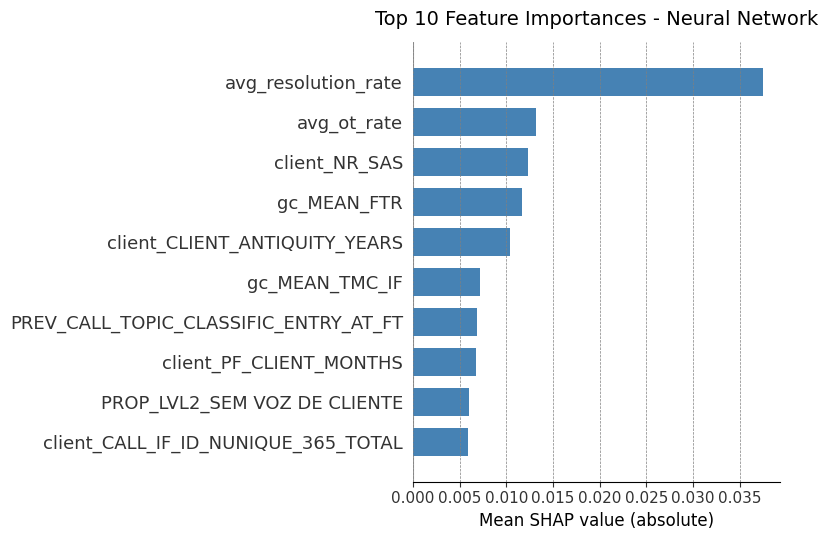

In [ ]:
shap_ot, X_ot_plot_sample = get_shap_values(ot_model, X_train, X_test, cat_feats, num_feats, scaler, input_columns, clean_name)
plot_shap_summary(shap_ot, X_ot_plot_sample, "Neural Network", "OT")
plt.show()

### <a id='toc1_5_5_'></a>[OT Model Comparison](#toc0_)

XGBoost Best Threshold (F1): 0.19
Precision: 0.25, Recall: 0.73, F1: 0.38
Logistic Regression Best Threshold (F1): 0.18
Precision: 0.24, Recall: 0.79, F1: 0.36


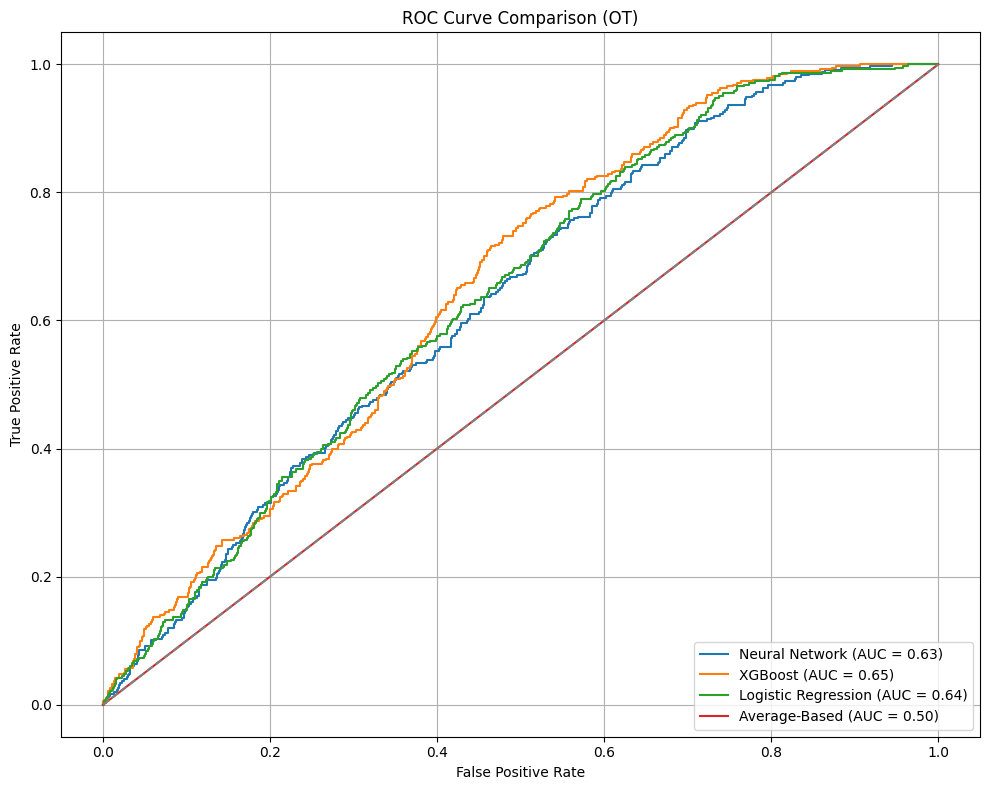

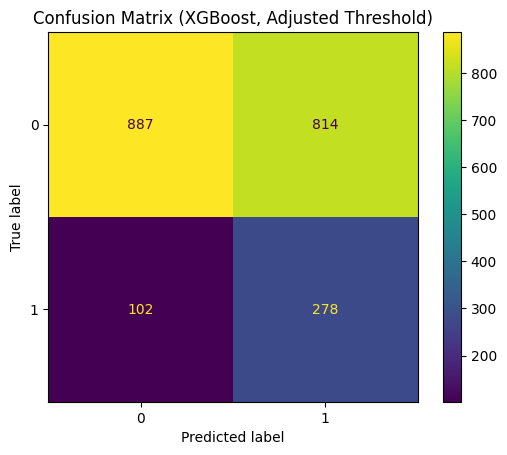

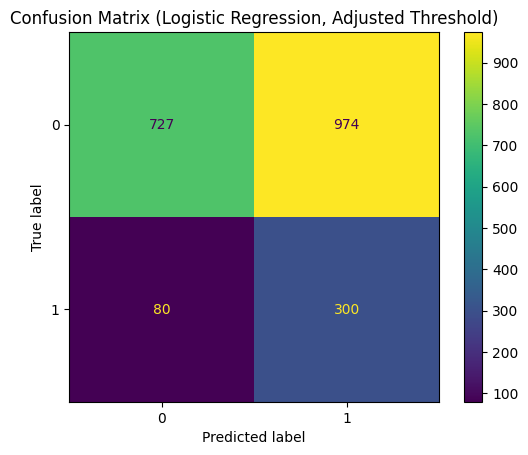

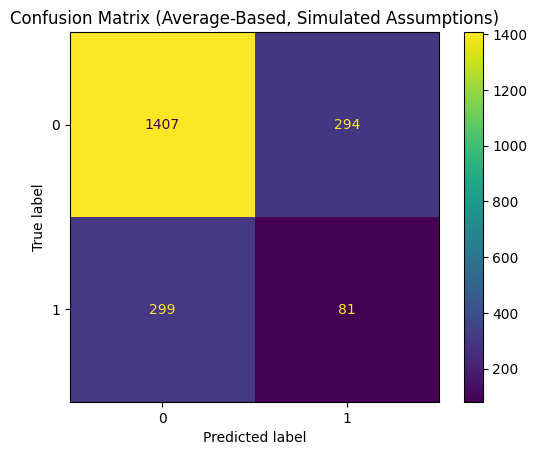


Pairwise Comparison Evaluation:
XGBoost Pairwise Accuracy: 65.12%
Logistic Regression Pairwise Accuracy: 63.92%
Average-Based Pairwise Accuracy: 0.00%


In [ ]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)
import matplotlib.pyplot as plt
import numpy as np

# === Compute Optimal Threshold for XGBoost ===
precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_test_ot, y_prob_xgb)
f1_scores_xgb = 2 * (precisions_xgb * recalls_xgb) / (precisions_xgb + recalls_xgb + 1e-10)
best_idx_xgb = np.argmax(f1_scores_xgb)
best_thresh_xgb = thresholds_xgb[best_idx_xgb]
print(f"XGBoost Best Threshold (F1): {best_thresh_xgb:.2f}")
print(f"Precision: {precisions_xgb[best_idx_xgb]:.2f}, Recall: {recalls_xgb[best_idx_xgb]:.2f}, F1: {f1_scores_xgb[best_idx_xgb]:.2f}")

# === Compute Optimal Threshold for Logistic Regression ===
precisions_log, recalls_log, thresholds_log = precision_recall_curve(y_test_ot, y_prob_log)
f1_scores_log = 2 * (precisions_log * recalls_log) / (precisions_log + recalls_log + 1e-10)
best_idx_log = np.argmax(f1_scores_log)
best_thresh_log = thresholds_log[best_idx_log]
print(f"Logistic Regression Best Threshold (F1): {best_thresh_log:.2f}")
print(f"Precision: {precisions_log[best_idx_log]:.2f}, Recall: {recalls_log[best_idx_log]:.2f}, F1: {f1_scores_log[best_idx_log]:.2f}")

# === Compute ROC and AUC for all models ===
# Neural Network
fpr_nn, tpr_nn, _ = roc_curve(y_ot_test, y_ot_prob)
auc_nn = roc_auc_score(y_ot_test, y_ot_prob)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_ot, y_prob_xgb)
auc_xgb = roc_auc_score(y_test_ot, y_prob_xgb)

# Logistic Regression
fpr_log, tpr_log, _ = roc_curve(y_test_ot, y_prob_log)
auc_log = roc_auc_score(y_test_ot, y_prob_log)

# Average-Based Prediction (Baseline)
y_prob_avg_ot = np.full_like(y_test_ot, fill_value=np.mean(y_test_ot), dtype=float)
fpr_avg, tpr_avg, _ = roc_curve(y_test_ot, y_prob_avg_ot)
auc_avg = roc_auc_score(y_test_ot, y_prob_avg_ot)

# === Plot ROC Curves ===
plt.figure(figsize=(10, 8))
plt.plot(fpr_nn,   tpr_nn,   label=f"Neural Network (AUC = {auc_nn:.2f})")
plt.plot(fpr_xgb,  tpr_xgb,  label=f"XGBoost (AUC = {auc_xgb:.2f})")
plt.plot(fpr_log,  tpr_log,  label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_avg,  tpr_avg,  label=f"Average-Based (AUC = {auc_avg:.2f})")
plt.plot([0, 1],  [0, 1],   linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (OT)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Confusion Matrix for XGBoost with Optimal Threshold ===
y_pred_xgb_thresh = (y_prob_xgb >= best_thresh_xgb).astype(int)
cm_xgb = confusion_matrix(y_test_ot, y_pred_xgb_thresh)
ConfusionMatrixDisplay(cm_xgb).plot()
plt.title("Confusion Matrix (XGBoost, Adjusted Threshold)")
plt.show()

# === Confusion Matrix for Logistic Regression with Optimal Threshold ===
y_pred_log_thresh = (y_prob_log >= best_thresh_log).astype(int)
cm_log = confusion_matrix(y_test_ot, y_pred_log_thresh)
ConfusionMatrixDisplay(cm_log).plot()
plt.title("Confusion Matrix (Logistic Regression, Adjusted Threshold)")
plt.show()

# === Confusion Matrix for Average-Based Prediction (Simulated) ===
np.random.seed(42)
y_pred_avg_sim = np.random.binomial(1, y_prob_avg_ot)
cm_avg = confusion_matrix(y_test_ot, y_pred_avg_sim)
ConfusionMatrixDisplay(cm_avg).plot()
plt.title("Confusion Matrix (Average-Based, Simulated Assumptions)")
plt.show()

# === Pairwise Comparison Evaluation ===
print("\nPairwise Comparison Evaluation:")

# Number of pairs to sample
num_samples = 100000  # Adjust based on memory capacity

# Randomly sample pairs of indices
indices = np.random.choice(len(y_test_ot), size=(num_samples, 2), replace=True)

# Initialize counters for correct comparisons
correct_predictions_xgb = 0
correct_predictions_log = 0
correct_predictions_avg = 0
valid_pairs = 0  # Count valid pairs (where actual_i != actual_j)

# Perform pairwise comparisons
for i, j in indices:
    # Actual values
    actual_i = y_test_ot[i]
    actual_j = y_test_ot[j]

    # Predicted probabilities
    prob_xgb_i, prob_xgb_j = y_prob_xgb[i], y_prob_xgb[j]
    prob_log_i, prob_log_j = y_prob_log[i], y_prob_log[j]
    prob_avg_i, prob_avg_j = y_prob_avg_ot[i], y_prob_avg_ot[j]

    # Skip pairs where both actual labels are the same
    if actual_i == actual_j:
        continue

    # Compare actual and predicted rankings
    valid_pairs += 1
    if (actual_i > actual_j and prob_xgb_i > prob_xgb_j) or (actual_i < actual_j and prob_xgb_i < prob_xgb_j):
        correct_predictions_xgb += 1
    if (actual_i > actual_j and prob_log_i > prob_log_j) or (actual_i < actual_j and prob_log_i < prob_log_j):
        correct_predictions_log += 1
    if (actual_i > actual_j and prob_avg_i > prob_avg_j) or (actual_i < actual_j and prob_avg_i < prob_avg_j):
        correct_predictions_avg += 1

# Calculate pairwise accuracy
if valid_pairs > 0:
    pairwise_accuracy_nn = pairwise_accuracy_ot
    pairwise_accuracy_xgb = correct_predictions_xgb / valid_pairs
    pairwise_accuracy_log = correct_predictions_log / valid_pairs
    pairwise_accuracy_avg = correct_predictions_avg / valid_pairs
    print(f"XGBoost Pairwise Accuracy: {pairwise_accuracy_xgb:.2%}")
    print(f"Logistic Regression Pairwise Accuracy: {pairwise_accuracy_log:.2%}")
    print(f"Average-Based Pairwise Accuracy: {pairwise_accuracy_avg:.2%}")
else:
    print("No valid pairs for pairwise comparison.")

## <a id='toc1_6_'></a>[Apply on sample calls and select suitable GC](#toc0_)

### <a id='toc1_6_1_'></a>[Create GCs Unique Table](#toc0_)

In [ ]:
gc_columns = [col for col in final_df.columns if col.startswith('MEAN_') or col.startswith('TOTAL_') or col.startswith('COUNT_') or col.startswith('OTS_') or col.startswith('CALLS_')]
#gc_columns += ['ARPU_CLIENT', 'CLIENT_AGE_YEARS', 'N_PAST_CALLS']  # Add if you want these

gcs_unique = full_merged_df[['RESOURCE_KEY'] + gc_columns].drop_duplicates(subset='RESOURCE_KEY').set_index('RESOURCE_KEY')
gcs_unique.head()

""
RESOURCE_KEY
11741170013
11741920010
11750000013
11763970008
11776310014


### <a id='toc1_6_2_'></a>[Define 10 Sample Calls](#toc0_)

In [ ]:
import numpy as np
import pandas as pd

# Select 10 random calls
sample_calls = final_df.sample(n=10, random_state=42)
sample_ids = sample_calls.index.tolist()
sample_data = X.loc[sample_ids]

### <a id='toc1_6_3_'></a>[SIMPLE (Linear and Logistic Regression)](#toc0_)

In [97]:
from sklearn.linear_model import LinearRegression, LogisticRegression

# Linear Regression (TMC)
lr = LinearRegression()
lr.fit(X_train_scaled_tmc, y_train_tmc)

# Logistic Regression (FTR)
log_ftr = LogisticRegression()
log_ftr.fit(X_train_scaled_ftr, y_train_ftr)

# Logistic Regression (OT)
log_ot = LogisticRegression()
log_ot.fit(X_train_scaled_ot, y_train_ot)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

LogisticRegression()

In [ ]:
# Generate predictions
simple_results = []

for leg_id in sample_ids:
    call_row = sample_data.loc[leg_id].copy()

    for gc_id in gcs_unique.index:
        gc_features = gcs_unique.loc[gc_id]

        # build the combined feature row
        input_row = call_row.copy()
        input_row.update(gc_features)

        # —— scale TMC only on its numeric subset ——
        num_vals_tmc = input_row[cols_to_scale_tmc].values.reshape(1, -1)
        scaled_vals_tmc = scaler_tmc.transform(num_vals_tmc)
        # re-assemble a full feature vector in the same column order
        tmp = input_row.copy()
        tmp[cols_to_scale_tmc] = scaled_vals_tmc.flatten()
        row_scaled_tmc = tmp[X_train_scaled_tmc.columns].values.reshape(1, -1)

        # —— same for FTR and OT ——
        num_vals_ftr = input_row[cols_to_scale_ftr].values.reshape(1, -1)
        tmp = input_row.copy()
        tmp[cols_to_scale_ftr] = scaler_ftr.transform(num_vals_ftr).flatten()
        row_scaled_ftr = tmp[X_train_scaled_ftr.columns].values.reshape(1, -1)

        num_vals_ot = input_row[cols_to_scale_ot].values.reshape(1, -1)
        tmp = input_row.copy()
        tmp[cols_to_scale_ot] = scaler_ot.transform(num_vals_ot).flatten()
        row_scaled_ot = tmp[X_train_scaled_ot.columns].values.reshape(1, -1)

        # predictions
        pred_tmc = lr.predict(row_scaled_tmc)[0]
        p_ftr   = log_ftr.predict_proba(row_scaled_ftr)[0][1]
        p_ot    = log_ot.predict_proba(row_scaled_ot)[0][1]

        #average duration for the client
        avg_client_duration =input_row["client_LEG_DURATION_MEAN_365_TOTAL"]

        # cost calculation
        call_cost   = pred_tmc / 60 * 0.35
        tech_cost   = p_ot * 22
        repeat_cost = (1 - p_ftr) * (avg_client_duration/ 60 * 0.35)
        total_cost  = call_cost + tech_cost + repeat_cost

        simple_results.append({
            "Model": "SIMPLE",
            "LEG_IF_ID": leg_id,
            "RESOURCE_KEY": gc_id,
            "Pred_TMC": pred_tmc,
            "P_FTR": p_ftr,
            "P_OT": p_ot,
            "Total_Cost": total_cost
        })


# Convert to DataFrame
simple_df = pd.DataFrame(simple_results)

# Display top 10 GCs per sample call
for leg_id in sample_ids:
    print(f"\nTop 10 GCs for Call {leg_id} (SIMPLE):")
    display(simple_df[simple_df["LEG_IF_ID"] == leg_id].sort_values("Total_Cost").head(10))




Output streaming troncato alle ultime 5000 righe.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warni


Top 10 GCs for Call 45635 (SIMPLE):


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/

,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
376,SIMPLE,45635,14438130001,1335.044308,0.333843,0.154793,11.193212
377,SIMPLE,45635,14441190001,1335.044308,0.333843,0.154793,11.193212
378,SIMPLE,45635,14442230001,1335.044308,0.333843,0.154793,11.193212
379,SIMPLE,45635,14459810001,1335.044308,0.333843,0.154793,11.193212
380,SIMPLE,45635,14459830001,1335.044308,0.333843,0.154793,11.193212
381,SIMPLE,45635,14460160001,1335.044308,0.333843,0.154793,11.193212
382,SIMPLE,45635,14460190001,1335.044308,0.333843,0.154793,11.193212
383,SIMPLE,45635,14460210001,1335.044308,0.333843,0.154793,11.193212
368,SIMPLE,45635,14438020001,1335.044308,0.333843,0.154793,11.193212
369,SIMPLE,45635,14438030001,1335.044308,0.333843,0.154793,11.193212



Top 10 GCs for Call 43892 (SIMPLE):


...

,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3134,SIMPLE,36773,14438130001,1038.818251,0.815698,0.203174,10.529591
3135,SIMPLE,36773,14441190001,1038.818251,0.815698,0.203174,10.529591
3136,SIMPLE,36773,14442230001,1038.818251,0.815698,0.203174,10.529591
3137,SIMPLE,36773,14459810001,1038.818251,0.815698,0.203174,10.529591
3138,SIMPLE,36773,14459830001,1038.818251,0.815698,0.203174,10.529591
3139,SIMPLE,36773,14460160001,1038.818251,0.815698,0.203174,10.529591
3140,SIMPLE,36773,14460190001,1038.818251,0.815698,0.203174,10.529591
3141,SIMPLE,36773,14460210001,1038.818251,0.815698,0.203174,10.529591
3126,SIMPLE,36773,14438020001,1038.818251,0.815698,0.203174,10.529591
3127,SIMPLE,36773,14438030001,1038.818251,0.815698,0.203174,10.529591



Top 10 GCs for Call 22991 (SIMPLE):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3528,SIMPLE,22991,14438130001,1076.355775,0.339509,0.202491,10.733534
3529,SIMPLE,22991,14441190001,1076.355775,0.339509,0.202491,10.733534
3530,SIMPLE,22991,14442230001,1076.355775,0.339509,0.202491,10.733534
3531,SIMPLE,22991,14459810001,1076.355775,0.339509,0.202491,10.733534
3532,SIMPLE,22991,14459830001,1076.355775,0.339509,0.202491,10.733534
3533,SIMPLE,22991,14460160001,1076.355775,0.339509,0.202491,10.733534
3534,SIMPLE,22991,14460190001,1076.355775,0.339509,0.202491,10.733534
3535,SIMPLE,22991,14460210001,1076.355775,0.339509,0.202491,10.733534
3520,SIMPLE,22991,14438020001,1076.355775,0.339509,0.202491,10.733534
3521,SIMPLE,22991,14438030001,1076.355775,0.339509,0.202491,10.733534



Top 10 GCs for Call 30303 (SIMPLE):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3922,SIMPLE,30303,14438130001,725.541454,0.728555,0.065782,5.679527
3923,SIMPLE,30303,14441190001,725.541454,0.728555,0.065782,5.679527
3924,SIMPLE,30303,14442230001,725.541454,0.728555,0.065782,5.679527
3925,SIMPLE,30303,14459810001,725.541454,0.728555,0.065782,5.679527
3926,SIMPLE,30303,14459830001,725.541454,0.728555,0.065782,5.679527
3927,SIMPLE,30303,14460160001,725.541454,0.728555,0.065782,5.679527
3928,SIMPLE,30303,14460190001,725.541454,0.728555,0.065782,5.679527
3929,SIMPLE,30303,14460210001,725.541454,0.728555,0.065782,5.679527
3914,SIMPLE,30303,14438020001,725.541454,0.728555,0.065782,5.679527
3915,SIMPLE,30303,14438030001,725.541454,0.728555,0.065782,5.679527


### <a id='toc1_6_4_'></a>[BOOSTED (XG Boost Regressor and Classifier)](#toc0_)

In [99]:
from xgboost import XGBRegressor, XGBClassifier

# Regression model for TMC
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train_scaled_tmc, y_train_tmc)

# Classification model for FTR
xgb_clf_ftr = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf_ftr.fit(X_train_scaled_ftr, y_train_ftr)

# Classification model for OT
xgb_clf_ot = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf_ot.fit(X_train_scaled_ot, y_train_ot)



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:24:04] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:24:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [100]:
from typing import Sequence

def simulate_boosted_calls(
    sample_ids: Sequence,
    final_df: pd.DataFrame,
    gcs_unique: pd.DataFrame,
    xgb_reg,
    xgb_clf_ftr,
    xgb_clf_ot,
    scaler_tmc,
    scaler_ftr,
    scaler_ot,
    feature_tmc: Sequence[str],
    feature_ftr: Sequence[str],
    feature_ot: Sequence[str],
    cols_to_scale_tmc: Sequence[str],
    cols_to_scale_ftr: Sequence[str],
    cols_to_scale_ot: Sequence[str]
) -> pd.DataFrame:
    all_predictions = []

    for call_id in sample_ids:
        # pull the call, drop the dependent columns and any GC cols
        call_row = final_df.loc[call_id].drop(
            ["TMC_dependent", "FTR_dependent", "OT_dependent"] +
            [c for c in gcs_unique.columns if c in final_df.columns]
        )

        for gc_id, gc_row in gcs_unique.iterrows():
            # 1) build the raw feature vector
            combined = pd.concat([call_row, gc_row])

            # 2) make three one-row DataFrames in the right column order
            x_tmc = combined.reindex(feature_tmc).to_frame().T
            x_ftr = combined.reindex(feature_ftr).to_frame().T
            x_ot  = combined.reindex(feature_ot).to_frame().T

            # ==== SCALING STEPS ====
            # TMC
            sub_tmc = x_tmc[cols_to_scale_tmc].values.reshape(1, -1)
            scaled_tmc = scaler_tmc.transform(sub_tmc)
            x_tmc.loc[:, cols_to_scale_tmc] = scaled_tmc
            row_tmc = x_tmc.values  # now in the exact feature order

            # FTR
            sub_ftr = x_ftr[cols_to_scale_ftr].values.reshape(1, -1)
            scaled_ftr = scaler_ftr.transform(sub_ftr)
            x_ftr.loc[:, cols_to_scale_ftr] = scaled_ftr
            row_ftr = x_ftr.values

            # OT
            sub_ot = x_ot[cols_to_scale_ot].values.reshape(1, -1)
            scaled_ot = scaler_ot.transform(sub_ot)
            x_ot.loc[:, cols_to_scale_ot] = scaled_ot
            row_ot = x_ot.values
            # ==== END PATCH ====

            # 3) predictions
            pred_tmc = xgb_reg.predict(row_tmc)[0]
            p_ftr    = xgb_clf_ftr.predict_proba(row_ftr)[0][1]
            p_ot     = xgb_clf_ot.predict_proba(row_ot)[0][1]

            #average duration for the client
            avg_client_duration = combined["client_LEG_DURATION_MEAN_365_TOTAL"]

            # cost calculation
            call_cost   = pred_tmc / 60 * 0.35
            tech_cost   = p_ot * 22
            repeat_cost = (1 - p_ftr) * (avg_client_duration/ 60 * 0.35)
            total_cost  = call_cost + tech_cost + repeat_cost


            all_predictions.append({
                "Model":        "BOOSTED",
                "LEG_IF_ID":    call_id,
                "RESOURCE_KEY": gc_id,
                "Pred_TMC":     pred_tmc,
                "P_FTR":        p_ftr,
                "P_OT":         p_ot,
                "Total_Cost":   total_cost
            })

    return pd.DataFrame(all_predictions)


In [101]:
boosted_results = simulate_boosted_calls(
    sample_ids        = sample_ids,
    final_df          = final_df,
    gcs_unique        = gcs_unique,
    xgb_reg           = xgb_reg,
    xgb_clf_ftr       = xgb_clf_ftr,
    xgb_clf_ot        = xgb_clf_ot,
    scaler_tmc        = scaler_tmc,
    scaler_ftr        = scaler_ftr,
    scaler_ot         = scaler_ot,
    feature_tmc       = X_train_scaled_tmc.columns,
    feature_ftr       = X_train_scaled_ftr.columns,
    feature_ot        = X_train_scaled_ot.columns,
    cols_to_scale_tmc = cols_to_scale_tmc,
    cols_to_scale_ftr = cols_to_scale_ftr,
    cols_to_scale_ot  = cols_to_scale_ot
)


Output streaming troncato alle ultime 5000 righe.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
boosted_df = pd.DataFrame(boosted_results)

for leg_id in sample_ids:
    print(f"\nTop 10 GCs for Call {leg_id} (BOOSTED):")
    display(boosted_df[boosted_df["LEG_IF_ID"] == leg_id].sort_values("Total_Cost").head(10))



Top 10 GCs for Call 45635 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
376,BOOSTED,45635,14438130001,1012.817078,0.134809,0.023291,6.420512
377,BOOSTED,45635,14441190001,1012.817078,0.134809,0.023291,6.420512
378,BOOSTED,45635,14442230001,1012.817078,0.134809,0.023291,6.420512
379,BOOSTED,45635,14459810001,1012.817078,0.134809,0.023291,6.420512
380,BOOSTED,45635,14459830001,1012.817078,0.134809,0.023291,6.420512
381,BOOSTED,45635,14460160001,1012.817078,0.134809,0.023291,6.420512
382,BOOSTED,45635,14460190001,1012.817078,0.134809,0.023291,6.420512
383,BOOSTED,45635,14460210001,1012.817078,0.134809,0.023291,6.420512
368,BOOSTED,45635,14438020001,1012.817078,0.134809,0.023291,6.420512
369,BOOSTED,45635,14438030001,1012.817078,0.134809,0.023291,6.420512



Top 10 GCs for Call 43892 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
770,BOOSTED,43892,14438130001,869.138428,0.903011,0.009322,5.523986
771,BOOSTED,43892,14441190001,869.138428,0.903011,0.009322,5.523986
772,BOOSTED,43892,14442230001,869.138428,0.903011,0.009322,5.523986
773,BOOSTED,43892,14459810001,869.138428,0.903011,0.009322,5.523986
774,BOOSTED,43892,14459830001,869.138428,0.903011,0.009322,5.523986
775,BOOSTED,43892,14460160001,869.138428,0.903011,0.009322,5.523986
776,BOOSTED,43892,14460190001,869.138428,0.903011,0.009322,5.523986
777,BOOSTED,43892,14460210001,869.138428,0.903011,0.009322,5.523986
762,BOOSTED,43892,14438020001,869.138428,0.903011,0.009322,5.523986
763,BOOSTED,43892,14438030001,869.138428,0.903011,0.009322,5.523986



Top 10 GCs for Call 25708 (BOOSTED):


...

,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3134,BOOSTED,36773,14438130001,885.632446,0.501046,0.437189,14.784345
3135,BOOSTED,36773,14441190001,885.632446,0.501046,0.437189,14.784345
3136,BOOSTED,36773,14442230001,885.632446,0.501046,0.437189,14.784345
3137,BOOSTED,36773,14459810001,885.632446,0.501046,0.437189,14.784345
3138,BOOSTED,36773,14459830001,885.632446,0.501046,0.437189,14.784345
3139,BOOSTED,36773,14460160001,885.632446,0.501046,0.437189,14.784345
3140,BOOSTED,36773,14460190001,885.632446,0.501046,0.437189,14.784345
3141,BOOSTED,36773,14460210001,885.632446,0.501046,0.437189,14.784345
3126,BOOSTED,36773,14438020001,885.632446,0.501046,0.437189,14.784345
3127,BOOSTED,36773,14438030001,885.632446,0.501046,0.437189,14.784345



Top 10 GCs for Call 22991 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3528,BOOSTED,22991,14438130001,862.070923,0.146742,0.151503,8.361805
3529,BOOSTED,22991,14441190001,862.070923,0.146742,0.151503,8.361805
3530,BOOSTED,22991,14442230001,862.070923,0.146742,0.151503,8.361805
3531,BOOSTED,22991,14459810001,862.070923,0.146742,0.151503,8.361805
3532,BOOSTED,22991,14459830001,862.070923,0.146742,0.151503,8.361805
3533,BOOSTED,22991,14460160001,862.070923,0.146742,0.151503,8.361805
3534,BOOSTED,22991,14460190001,862.070923,0.146742,0.151503,8.361805
3535,BOOSTED,22991,14460210001,862.070923,0.146742,0.151503,8.361805
3520,BOOSTED,22991,14438020001,862.070923,0.146742,0.151503,8.361805
3521,BOOSTED,22991,14438030001,862.070923,0.146742,0.151503,8.361805



Top 10 GCs for Call 30303 (BOOSTED):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
3922,BOOSTED,30303,14438130001,272.623627,0.700459,0.012953,1.875266
3923,BOOSTED,30303,14441190001,272.623627,0.700459,0.012953,1.875266
3924,BOOSTED,30303,14442230001,272.623627,0.700459,0.012953,1.875266
3925,BOOSTED,30303,14459810001,272.623627,0.700459,0.012953,1.875266
3926,BOOSTED,30303,14459830001,272.623627,0.700459,0.012953,1.875266
3927,BOOSTED,30303,14460160001,272.623627,0.700459,0.012953,1.875266
3928,BOOSTED,30303,14460190001,272.623627,0.700459,0.012953,1.875266
3929,BOOSTED,30303,14460210001,272.623627,0.700459,0.012953,1.875266
3914,BOOSTED,30303,14438020001,272.623627,0.700459,0.012953,1.875266
3915,BOOSTED,30303,14438030001,272.623627,0.700459,0.012953,1.875266


### <a id='toc1_6_5_'></a>[ADVANCED (Neural Networks)](#toc0_)

In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from typing import Sequence

# Clean column names to match model's
def clean_name(name: str) -> str:
    """
    Replace any character not alphanumeric with underscore.
    Must match exactly how you cleaned columns at training time.
    """
    return re.sub(r'[^0-9a-zA-Z]+', '_', str(name))

final_df   = reduced_df.copy().rename(columns=lambda x: clean_name(x))
gcs_unique = gcs_unique.copy().rename(columns=lambda x: clean_name(x))

input_columns = [clean_name(c) for c in input_columns]   # if input_columns were originally un‐clean
cat_feats     = [clean_name(c) for c in cat_feats]
num_feats     = [clean_name(c) for c in num_feats]

# Verify that each cat_feat indeed appears in final_df:
missing_cats = [c for c in cat_feats if c not in final_df.columns]
if missing_cats:
    print("WARNING: these cat_feats are not in final_df.columns:", missing_cats)

# Simulate NN calls using the provided models and data
def simulate_nn_calls(
    sample_ids: Sequence,
    final_df: pd.DataFrame,
    gcs_unique: pd.DataFrame,
    reg_model,
    ftr_model,
    ot_model,
    scaler: StandardScaler,
    label_encoders: dict,
    cat_feats: Sequence[str],
    num_feats: Sequence[str],
    input_columns: Sequence[str],
    avg_client_column: str = "client_LEG_DURATION_MEAN_365_TOTAL"
) -> pd.DataFrame:
    """
    1) final_df.columns and gcs_unique.columns MUST already be 'cleaned' via clean_name().
    2) input_columns, cat_feats, num_feats are all lists of those same cleaned names.
    3) label_encoders maps exactly each cleaned categorical column → fitted LabelEncoder.
    4) The Keras models expect exactly:
         - one input named "<cat>_in" for each cat in cat_feats
         - one input named "num_in" for the numeric block
    """
    all_predictions = []

    for call_id in sample_ids:
        # 1) Grab call‐side features (index = call_LEG_IF_ID)
        call_row = final_df.loc[call_id].copy()

        # Drop the dependent targets if they exist
        call_row = call_row.drop(
            ["TMC_dependent", "FTR_dependent", "OT_dependent"],
            errors="ignore"
        )
        # Remove any GC‐specific columns if final_df contains them
        for c in gcs_unique.columns:
            if c in call_row.index:
                call_row = call_row.drop(c)

        # 2) Loop across every GC in gcs_unique (index=GC_ID)
        for gc_id, gc_row in gcs_unique.iterrows():
            # Combine; when name overlaps, gc_row value overwrites call_row value
            combined = pd.concat([call_row, gc_row])

            # 3) Build a one‐row DataFrame containing exactly input_columns,
            #    filling missing with "Unknown" for cats, 0.0 for nums
            row_dict = {}
            for col in input_columns:
                if col in combined.index:
                    row_dict[col] = combined[col]
                else:
                    if col in cat_feats:
                        row_dict[col] = "Unknown"
                    else:
                        row_dict[col] = 0.0

            row_df = pd.DataFrame([row_dict], index=[0])  # shape = (1, len(input_columns))

            # 4) Label‐encode each categorical column IF it was in label_encoders
            for c in cat_feats:
                if c in label_encoders:
                    val = str(row_df.at[0, c])
                    le = label_encoders[c]
                    if val in le.classes_:
                        code = le.transform([val])[0]
                    else:
                        code = 0
                    row_df.at[0, c] = code
                else:
                    # If for some reason c not in label_encoders, just assign 0
                    row_df.at[0, c] = 0

            row_df[cat_feats] = row_df[cat_feats].astype("int32")

            # 5) Scale the numeric columns
            numeric_array = row_df[num_feats].astype("float32").values.reshape(1, -1)
            scaled_numeric = scaler.transform(numeric_array)
            for i, col in enumerate(num_feats):
                row_df.at[0, col] = scaled_numeric[0, i]

            # 6) Build Keras input dict
            model_input = {}
            for c in cat_feats:
                model_input[f"{c}_in"] = row_df[c].values.reshape(1, 1).astype("int32")
            model_input["num_in"] = scaled_numeric.astype("float32")

            # 7) Run predictions
            pred_tmc = reg_model.predict(model_input, verbose=0).flatten()[0]
            p_ftr    = ftr_model.predict(model_input, verbose=0).flatten()[0]
            p_ot     = ot_model.predict(model_input, verbose=0).flatten()[0]

            # 8) Compute costs
            avg_client_duration = float(row_df.at[0, avg_client_column])
            call_cost   = (pred_tmc / 60.0) * 0.35
            tech_cost   = p_ot * 22.0
            repeat_cost = (1.0 - p_ftr) * ((avg_client_duration / 60.0) * 0.35)
            total_cost  = call_cost + tech_cost + repeat_cost

            # 9) Append one row dict
            all_predictions.append({
                "Model":        "NN",
                "LEG_IF_ID":    call_id,
                "RESOURCE_KEY": gc_id,
                "Pred_TMC":     pred_tmc,
                "P_FTR":        p_ftr,
                "P_OT":         p_ot,
                "Total_Cost":   total_cost
            })

    return pd.DataFrame(all_predictions)


# Simulate NN calls using the provided models and data

# (A) Pick 10 random calls by index from final_df
sample_calls = final_df.sample(n=10, random_state=42)
sample_ids   = sample_calls.index.tolist()
print("Sampled call IDs:", sample_ids)

# (B) Call the simulator
nn_results = simulate_nn_calls(
    sample_ids       = sample_ids,
    final_df         = final_df,
    gcs_unique       = gcs_unique,
    reg_model        = reg_model,
    ftr_model        = ftr_model,
    ot_model         = ot_model,
    scaler           = scaler,
    label_encoders   = label_encoders,
    cat_feats        = cat_feats,
    num_feats        = num_feats,
    input_columns    = input_columns,
    avg_client_column= "client_LEG_DURATION_MEAN_365_TOTAL"
)

# (C) Inspect the first few rows of the NN predictions
print("\n=== Neural Network Predictions (first few rows) ===")
display(nn_results.head(10))

# (D) Top-10 GCs (lowest Total_Cost) for each sample call
for call_id in sample_ids:
    subset = nn_results[nn_results["LEG_IF_ID"] == call_id]
    top10_nn = subset.sort_values("Total_Cost", ascending=True).head(10)
    print(f"\nTop 10 GCs for Call {call_id} (NN):")
    display(top10_nn.reset_index(drop=True))


Sampled call IDs: [45635, 43892, 25708, 38142, 47140, 39250, 23815, 36773, 22991, 30303]


Output streaming troncato alle ultime 5000 righe.
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



=== Neural Network Predictions (first few rows) ===


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
0,NN,45635,11741170013,1252.033447,0.541158,0.212695,11.980942
1,NN,45635,11741920010,1252.033447,0.541158,0.212695,11.980942
2,NN,45635,11750000013,1252.033447,0.541158,0.212695,11.980942
3,NN,45635,11763970008,1252.033447,0.541158,0.212695,11.980942
4,NN,45635,11776310014,1252.033447,0.541158,0.212695,11.980942
5,NN,45635,11792920033,1252.033447,0.541158,0.212695,11.980942
6,NN,45635,11797610012,1252.033447,0.541158,0.212695,11.980942
7,NN,45635,11802570011,1252.033447,0.541158,0.212695,11.980942
8,NN,45635,11802970016,1252.033447,0.541158,0.212695,11.980942
9,NN,45635,11808370014,1252.033447,0.541158,0.212695,11.980942



Top 10 GCs for Call 45635 (NN):


...

,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
0,NN,36773,14438130001,1063.011353,0.585868,0.414148,15.31046
1,NN,36773,14441190001,1063.011353,0.585868,0.414148,15.31046
2,NN,36773,14442230001,1063.011353,0.585868,0.414148,15.31046
3,NN,36773,14459810001,1063.011353,0.585868,0.414148,15.31046
4,NN,36773,14459830001,1063.011353,0.585868,0.414148,15.31046
5,NN,36773,14460160001,1063.011353,0.585868,0.414148,15.31046
6,NN,36773,14460190001,1063.011353,0.585868,0.414148,15.31046
7,NN,36773,14460210001,1063.011353,0.585868,0.414148,15.31046
8,NN,36773,14438020001,1063.011353,0.585868,0.414148,15.31046
9,NN,36773,14438030001,1063.011353,0.585868,0.414148,15.31046



Top 10 GCs for Call 22991 (NN):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
0,NN,22991,14438130001,1162.28418,0.516609,0.211299,11.426588
1,NN,22991,14441190001,1162.28418,0.516609,0.211299,11.426588
2,NN,22991,14442230001,1162.28418,0.516609,0.211299,11.426588
3,NN,22991,14459810001,1162.28418,0.516609,0.211299,11.426588
4,NN,22991,14459830001,1162.28418,0.516609,0.211299,11.426588
5,NN,22991,14460160001,1162.28418,0.516609,0.211299,11.426588
6,NN,22991,14460190001,1162.28418,0.516609,0.211299,11.426588
7,NN,22991,14460210001,1162.28418,0.516609,0.211299,11.426588
8,NN,22991,14438020001,1162.28418,0.516609,0.211299,11.426588
9,NN,22991,14438030001,1162.28418,0.516609,0.211299,11.426588



Top 10 GCs for Call 30303 (NN):


,Model,LEG_IF_ID,RESOURCE_KEY,Pred_TMC,P_FTR,P_OT,Total_Cost
0,NN,30303,14438130001,703.669434,0.651916,0.151296,7.431824
1,NN,30303,14441190001,703.669434,0.651916,0.151296,7.431824
2,NN,30303,14442230001,703.669434,0.651916,0.151296,7.431824
3,NN,30303,14459810001,703.669434,0.651916,0.151296,7.431824
4,NN,30303,14459830001,703.669434,0.651916,0.151296,7.431824
5,NN,30303,14460160001,703.669434,0.651916,0.151296,7.431824
6,NN,30303,14460190001,703.669434,0.651916,0.151296,7.431824
7,NN,30303,14460210001,703.669434,0.651916,0.151296,7.431824
8,NN,30303,14438020001,703.669434,0.651916,0.151296,7.431824
9,NN,30303,14438030001,703.669434,0.651916,0.151296,7.431824


### <a id='toc1_6_6_'></a>[Output Comparison](#toc0_)

In [122]:
# ----------------------------------------
# 7) COMPARE SIMPLE vs BOOSTED vs NN using recall@10
# ----------------------------------------
def recall_at_k(real_topk: list, pred_topk: list, k: int = 10) -> float:
    real_set = set(real_topk[:k])
    pred_set = set(pred_topk[:k])
    return len(real_set & pred_set) / k

def build_top10_dict(df: pd.DataFrame, k: int = 10) -> dict:
    top10_dict = {}
    for call_id, grp in df.groupby("LEG_IF_ID"):
        topk = grp.nsmallest(k, "Total_Cost")["RESOURCE_KEY"].tolist()
        top10_dict[call_id] = topk
    return top10_dict

# Build the “ground‐truth” top-10 from simple_df, boosted, and nn_results
real_top10_by_call    = build_top10_dict(simple_df,  k=10)
boosted_top10_by_call = build_top10_dict(boosted_df, k=10)
nn_top10_by_call      = build_top10_dict(nn_results, k=10)

# Compute recall@10 for each call (Boosted vs. NN)
records = []
for call_id, real_list in real_top10_by_call.items():
    boosted_list = boosted_top10_by_call.get(call_id, [])
    nn_list      = nn_top10_by_call.get(call_id,    [])
    r10_boosted  = recall_at_k(real_list, boosted_list, k=10)
    r10_nn       = recall_at_k(real_list, nn_list,      k=10)
    records.append({
        "LEG_IF_ID":        call_id,
        "Recall10_Boosted": r10_boosted,
        "Recall10_NN":      r10_nn
    })

overlap_df = pd.DataFrame(records).set_index("LEG_IF_ID")

# Summary stats side by side
mean_boosted = overlap_df["Recall10_Boosted"].mean()
med_boosted  = overlap_df["Recall10_Boosted"].median()
min_boosted  = overlap_df["Recall10_Boosted"].min()
max_boosted  = overlap_df["Recall10_Boosted"].max()

mean_nn = overlap_df["Recall10_NN"].mean()
med_nn  = overlap_df["Recall10_NN"].median()
min_nn  = overlap_df["Recall10_NN"].min()
max_nn  = overlap_df["Recall10_NN"].max()

print(" BOOSTED MODEL ".center(60, "-"))
print(f"Average Recall@10: {mean_boosted:.2%}  (~{mean_boosted*10:.1f}/10 overlap)")
print(f"Median  Recall@10: {med_boosted:.2%}  (≥{med_boosted*10:.1f}/10 overlap)")
print(f"Min     Recall@10: {min_boosted:.2%}  (worst {min_boosted*10:.1f}/10)\n")

print(" NEURAL NETWORK MODEL ".center(60, "-"))
print(f"Average Recall@10: {mean_nn:.2%}  (~{mean_nn*10:.1f}/10 overlap)")
print(f"Median  Recall@10: {med_nn:.2%}  (≥{med_nn*10:.1f}/10 overlap)")
print(f"Min     Recall@10: {min_nn:.2%}  (worst {min_nn*10:.1f}/10)\n")

print("=== Per-Call Recall@10 (Boosted vs. NN) ===")
display(overlap_df)



---------------------- BOOSTED MODEL -----------------------
Average Recall@10: 100.00%  (~10.0/10 overlap)
Median  Recall@10: 100.00%  (≥10.0/10 overlap)
Min     Recall@10: 100.00%  (worst 10.0/10)

------------------- NEURAL NETWORK MODEL -------------------
Average Recall@10: 100.00%  (~10.0/10 overlap)
Median  Recall@10: 100.00%  (≥10.0/10 overlap)
Min     Recall@10: 100.00%  (worst 10.0/10)

=== Per-Call Recall@10 (Boosted vs. NN) ===


,Recall10_Boosted,Recall10_NN
LEG_IF_ID,,
22991,1.0,1.0
23815,1.0,1.0
25708,1.0,1.0
30303,1.0,1.0
36773,1.0,1.0
38142,1.0,1.0
39250,1.0,1.0
43892,1.0,1.0
45635,1.0,1.0
